# Preprocessing Data Train

## 1. Cek Kesalahan Data Train

Memulai analisis distribusi target variable...
=== ANALISIS DISTRIBUSI TARGET VARIABLE ===

Statistik Dasar:
Count: 16572
Mean: 45.31 bulan
Median: 24.00 bulan
Std: 691.26 bulan
Min: 1 bulan
Max: 88888 bulan
Skewness: 128.13
Kurtosis: 16468.59

Persentil:
P25: 12.00 bulan
P50: 24.00 bulan
P75: 60.00 bulan
P90: 84.00 bulan
P95: 109.35 bulan
P99: 180.00 bulan

Outlier Detection (IQR Method):
Lower bound: -60.00
Upper bound: 132.00
Jumlah outlier: 480 (2.90%)

Outlier Detection (Z-score > 3):
Jumlah outlier: 1 (0.01%)

Nilai Ekstrem:
Nilai sangat tinggi (>P99): 130 kasus
Nilai sangat rendah (<P1): 0 kasus
Nilai tertinggi: [88888, 240, 240, 240, 240, 240, 240, 240, 240, 240]


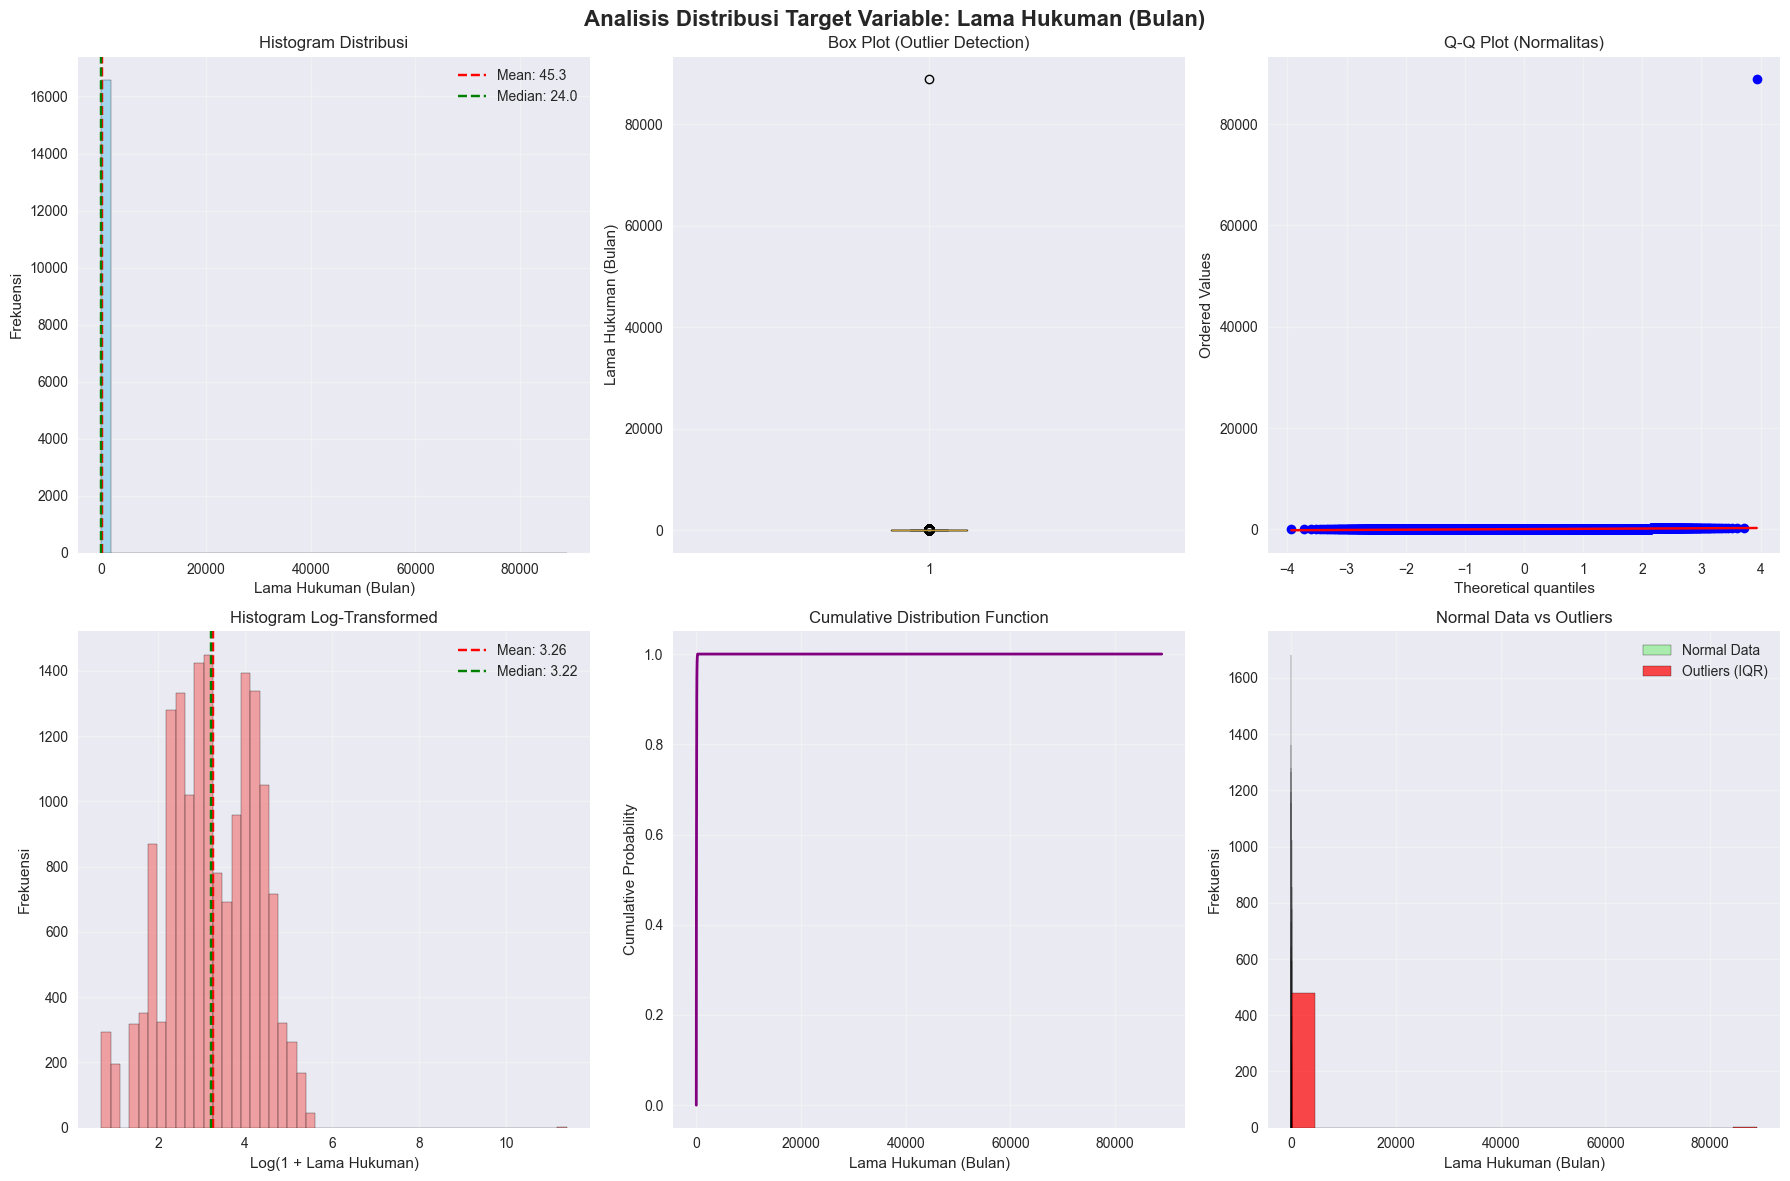


Grafik distribusi disimpan di: c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/target_distribution_analysis.png

=== REKOMENDASI PENANGANAN OUTLIER ===

Persentase outlier: 2.90%
✅ Persentase outlier rendah (<5%)
Rekomendasi:
1. Standard scaling sudah cukup
2. Bisa menggunakan berbagai jenis model

📊 Data sangat skewed (skewness: 128.13)
Rekomendasi transformasi: Log, Square root, atau Box-Cox

🔧 Winsorization suggestion:
   Cap values > P99 (180.0) to P99
   Cap values < P1 (1.0) to P1

ANALISIS SELESAI!


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def analyze_target_distribution(train_path):
    """
    Analisis distribusi target variable dan identifikasi outlier
    """
    print("=== ANALISIS DISTRIBUSI TARGET VARIABLE ===")
    
    # Load data
    train_df = pd.read_csv(train_path)
    target = train_df['lama hukuman (bulan)']
    
    # Basic statistics
    print(f"\nStatistik Dasar:")
    print(f"Count: {target.count()}")
    print(f"Mean: {target.mean():.2f} bulan")
    print(f"Median: {target.median():.2f} bulan")
    print(f"Std: {target.std():.2f} bulan")
    print(f"Min: {target.min()} bulan")
    print(f"Max: {target.max()} bulan")
    print(f"Skewness: {target.skew():.2f}")
    print(f"Kurtosis: {target.kurtosis():.2f}")
    
    # Percentiles
    print(f"\nPersentil:")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"P{p}: {np.percentile(target, p):.2f} bulan")
    
    # Outlier detection using IQR method
    Q1 = target.quantile(0.25)
    Q3 = target.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr = target[(target < lower_bound) | (target > upper_bound)]
    print(f"\nOutlier Detection (IQR Method):")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Jumlah outlier: {len(outliers_iqr)} ({len(outliers_iqr)/len(target)*100:.2f}%)")
    
    # Outlier detection using Z-score method
    z_scores = np.abs(stats.zscore(target))
    outliers_zscore = target[z_scores > 3]
    print(f"\nOutlier Detection (Z-score > 3):")
    print(f"Jumlah outlier: {len(outliers_zscore)} ({len(outliers_zscore)/len(target)*100:.2f}%)")
    
    # Extreme values analysis
    extreme_high = target[target > target.quantile(0.99)]
    extreme_low = target[target < target.quantile(0.01)]
    print(f"\nNilai Ekstrem:")
    print(f"Nilai sangat tinggi (>P99): {len(extreme_high)} kasus")
    print(f"Nilai sangat rendah (<P1): {len(extreme_low)} kasus")
    
    if len(extreme_high) > 0:
        print(f"Nilai tertinggi: {extreme_high.nlargest(10).tolist()}")
    if len(extreme_low) > 0:
        print(f"Nilai terendah: {extreme_low.nsmallest(10).tolist()}")
    
    return {
        'target': target,
        'outliers_iqr': outliers_iqr,
        'outliers_zscore': outliers_zscore,
        'extreme_high': extreme_high,
        'extreme_low': extreme_low,
        'stats': {
            'mean': target.mean(),
            'median': target.median(),
            'std': target.std(),
            'skew': target.skew(),
            'kurtosis': target.kurtosis(),
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR
        }
    }

def create_distribution_plots(analysis_results, save_path):
    """
    Membuat visualisasi distribusi target variable
    """
    target = analysis_results['target']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Analisis Distribusi Target Variable: Lama Hukuman (Bulan)', fontsize=16, fontweight='bold')
    
    # 1. Histogram
    axes[0,0].hist(target, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].axvline(target.mean(), color='red', linestyle='--', label=f'Mean: {target.mean():.1f}')
    axes[0,0].axvline(target.median(), color='green', linestyle='--', label=f'Median: {target.median():.1f}')
    axes[0,0].set_title('Histogram Distribusi')
    axes[0,0].set_xlabel('Lama Hukuman (Bulan)')
    axes[0,0].set_ylabel('Frekuensi')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Box plot
    axes[0,1].boxplot(target, vert=True)
    axes[0,1].set_title('Box Plot (Outlier Detection)')
    axes[0,1].set_ylabel('Lama Hukuman (Bulan)')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Q-Q plot
    stats.probplot(target, dist="norm", plot=axes[0,2])
    axes[0,2].set_title('Q-Q Plot (Normalitas)')
    axes[0,2].grid(True, alpha=0.3)
    
    # 4. Log-transformed histogram
    log_target = np.log1p(target)
    axes[1,0].hist(log_target, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1,0].axvline(log_target.mean(), color='red', linestyle='--', label=f'Mean: {log_target.mean():.2f}')
    axes[1,0].axvline(log_target.median(), color='green', linestyle='--', label=f'Median: {log_target.median():.2f}')
    axes[1,0].set_title('Histogram Log-Transformed')
    axes[1,0].set_xlabel('Log(1 + Lama Hukuman)')
    axes[1,0].set_ylabel('Frekuensi')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # 5. Cumulative distribution
    sorted_target = np.sort(target)
    cumulative = np.arange(1, len(sorted_target) + 1) / len(sorted_target)
    axes[1,1].plot(sorted_target, cumulative, color='purple', linewidth=2)
    axes[1,1].set_title('Cumulative Distribution Function')
    axes[1,1].set_xlabel('Lama Hukuman (Bulan)')
    axes[1,1].set_ylabel('Cumulative Probability')
    axes[1,1].grid(True, alpha=0.3)
    
    # 6. Outlier analysis
    outliers_iqr = analysis_results['outliers_iqr']
    normal_data = target[~target.isin(outliers_iqr)]
    
    axes[1,2].hist(normal_data, bins=40, alpha=0.7, color='lightgreen', label='Normal Data', edgecolor='black')
    if len(outliers_iqr) > 0:
        axes[1,2].hist(outliers_iqr, bins=20, alpha=0.7, color='red', label='Outliers (IQR)', edgecolor='black')
    axes[1,2].set_title('Normal Data vs Outliers')
    axes[1,2].set_xlabel('Lama Hukuman (Bulan)')
    axes[1,2].set_ylabel('Frekuensi')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nGrafik distribusi disimpan di: {save_path}")

def suggest_outlier_handling(analysis_results):
    """
    Memberikan rekomendasi penanganan outlier
    """
    target = analysis_results['target']
    outliers_iqr = analysis_results['outliers_iqr']
    stats_info = analysis_results['stats']
    
    print("\n=== REKOMENDASI PENANGANAN OUTLIER ===")
    
    outlier_percentage = len(outliers_iqr) / len(target) * 100
    
    print(f"\nPersentase outlier: {outlier_percentage:.2f}%")
    
    if outlier_percentage > 10:
        print("⚠️  PERINGATAN: Persentase outlier tinggi (>10%)")
        print("Rekomendasi:")
        print("1. Gunakan log transformation untuk mengurangi skewness")
        print("2. Terapkan robust scaling (RobustScaler)")
        print("3. Gunakan model yang robust terhadap outlier (Random Forest, Gradient Boosting)")
        print("4. Pertimbangkan Winsorization (cap extreme values)")
    elif outlier_percentage > 5:
        print("⚠️  Persentase outlier sedang (5-10%)")
        print("Rekomendasi:")
        print("1. Log transformation")
        print("2. Robust scaling")
        print("3. Ensemble methods")
    else:
        print("✅ Persentase outlier rendah (<5%)")
        print("Rekomendasi:")
        print("1. Standard scaling sudah cukup")
        print("2. Bisa menggunakan berbagai jenis model")
    
    # Skewness analysis
    if abs(stats_info['skew']) > 2:
        print(f"\n📊 Data sangat skewed (skewness: {stats_info['skew']:.2f})")
        print("Rekomendasi transformasi: Log, Square root, atau Box-Cox")
    elif abs(stats_info['skew']) > 1:
        print(f"\n📊 Data moderately skewed (skewness: {stats_info['skew']:.2f})")
        print("Rekomendasi transformasi: Log transformation")
    else:
        print(f"\n📊 Data relatif normal (skewness: {stats_info['skew']:.2f})")
    
    # Winsorization suggestion
    p99 = np.percentile(target, 99)
    p1 = np.percentile(target, 1)
    print(f"\n🔧 Winsorization suggestion:")
    print(f"   Cap values > P99 ({p99:.1f}) to P99")
    print(f"   Cap values < P1 ({p1:.1f}) to P1")
    
    return {
        'outlier_percentage': outlier_percentage,
        'winsorize_upper': p99,
        'winsorize_lower': p1,
        'log_transform_recommended': abs(stats_info['skew']) > 1
    }

if __name__ == "__main__":
    # Path ke file
    train_path = "c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/train.csv"
    plot_save_path = "c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/target_distribution_analysis.png"
    
    # Jalankan analisis
    print("Memulai analisis distribusi target variable...")
    analysis_results = analyze_target_distribution(train_path)
    
    # Buat visualisasi
    create_distribution_plots(analysis_results, plot_save_path)
    
    # Berikan rekomendasi
    recommendations = suggest_outlier_handling(analysis_results)
    
    print("\n" + "="*60)
    print("ANALISIS SELESAI!")
    print("="*60)

## 4. Visualisasi Hasil

Testing Model Visualizer...


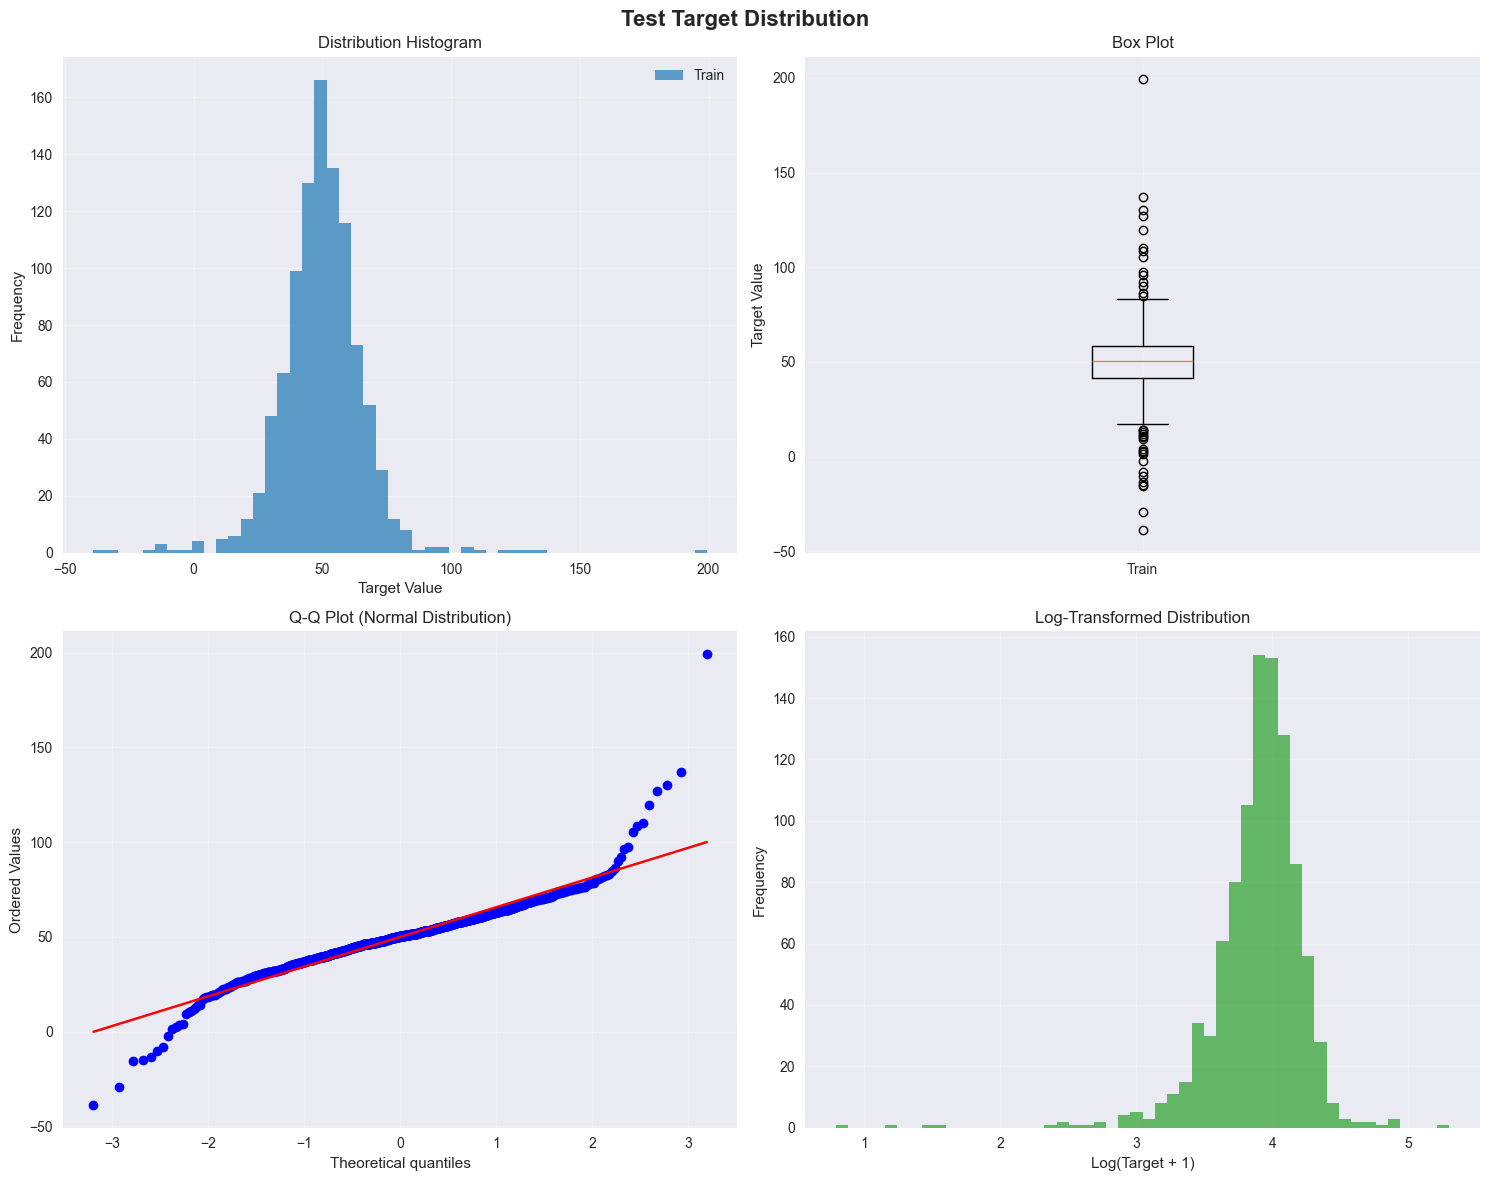


=== TARGET DISTRIBUTION STATISTICS ===
Train set:
  Count: 1000
  Mean: 49.96
  Median: 50.25
  Std: 16.44
  Skewness: 0.67
  Kurtosis: 10.61


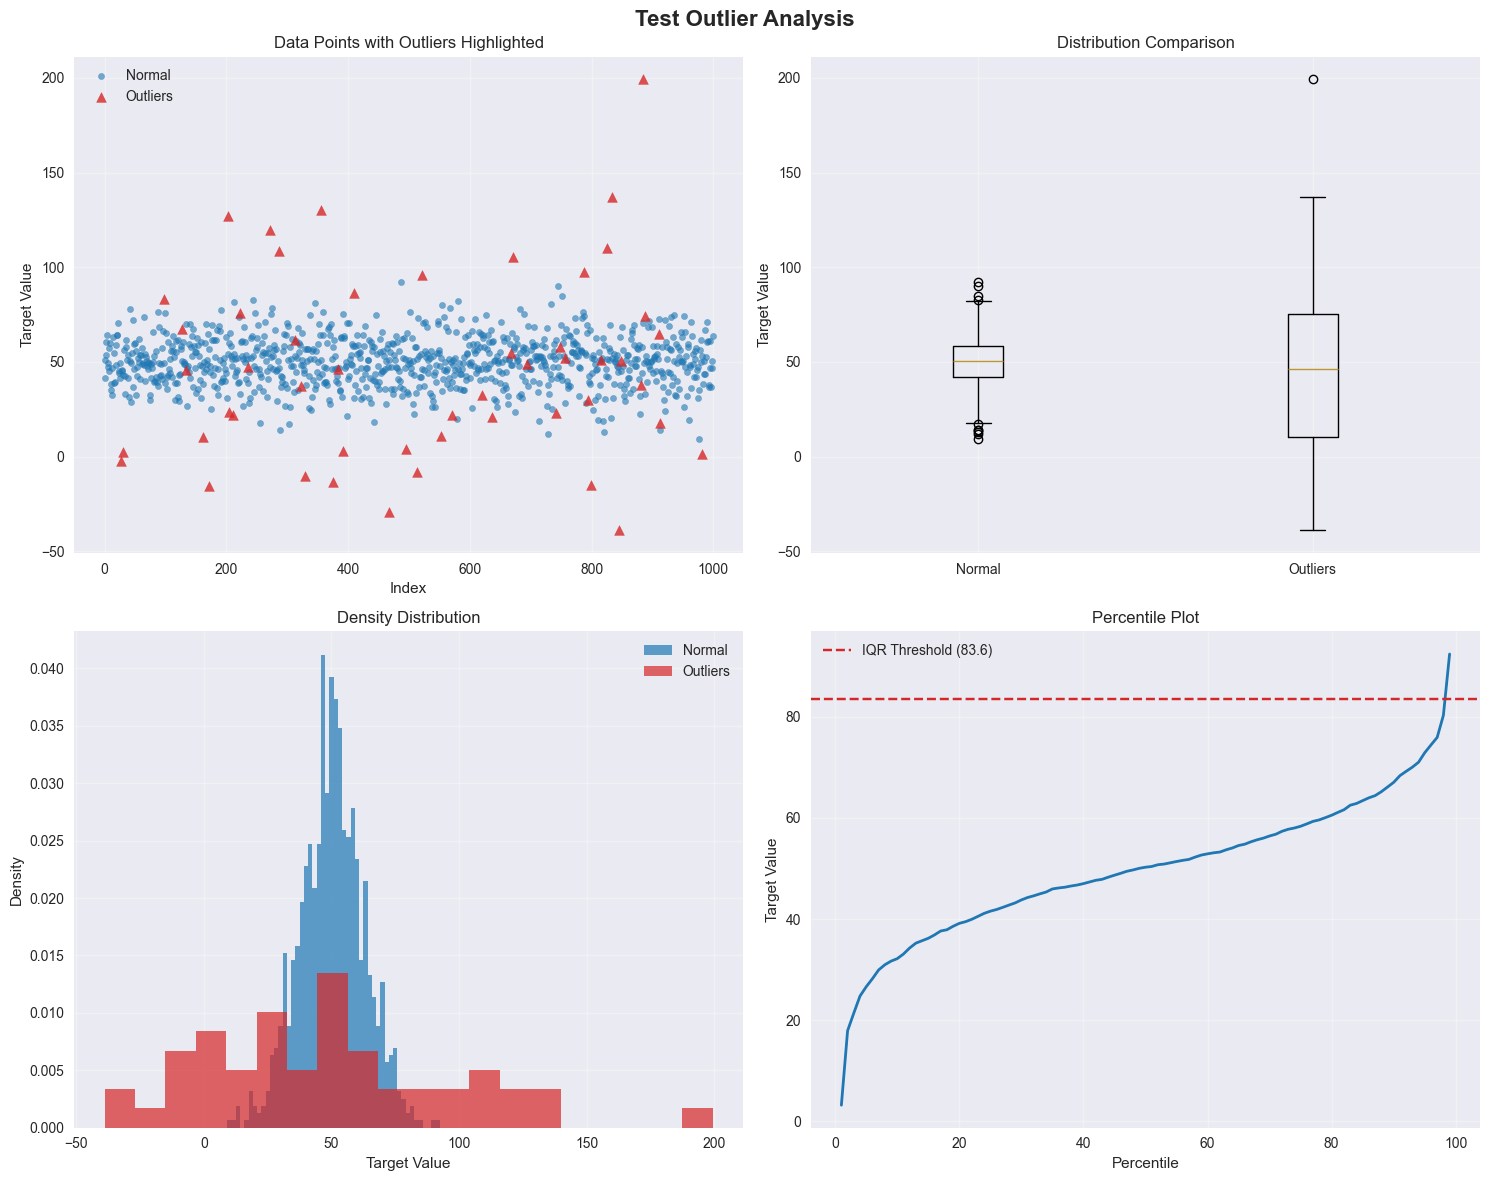


=== OUTLIER ANALYSIS SUMMARY ===
Total data points: 1000
Outliers detected: 50 (5.00%)
Normal data points: 950 (95.00%)

Outlier statistics:
  Min outlier value: -38.88
  Max outlier value: 199.34
  Mean outlier value: 47.31


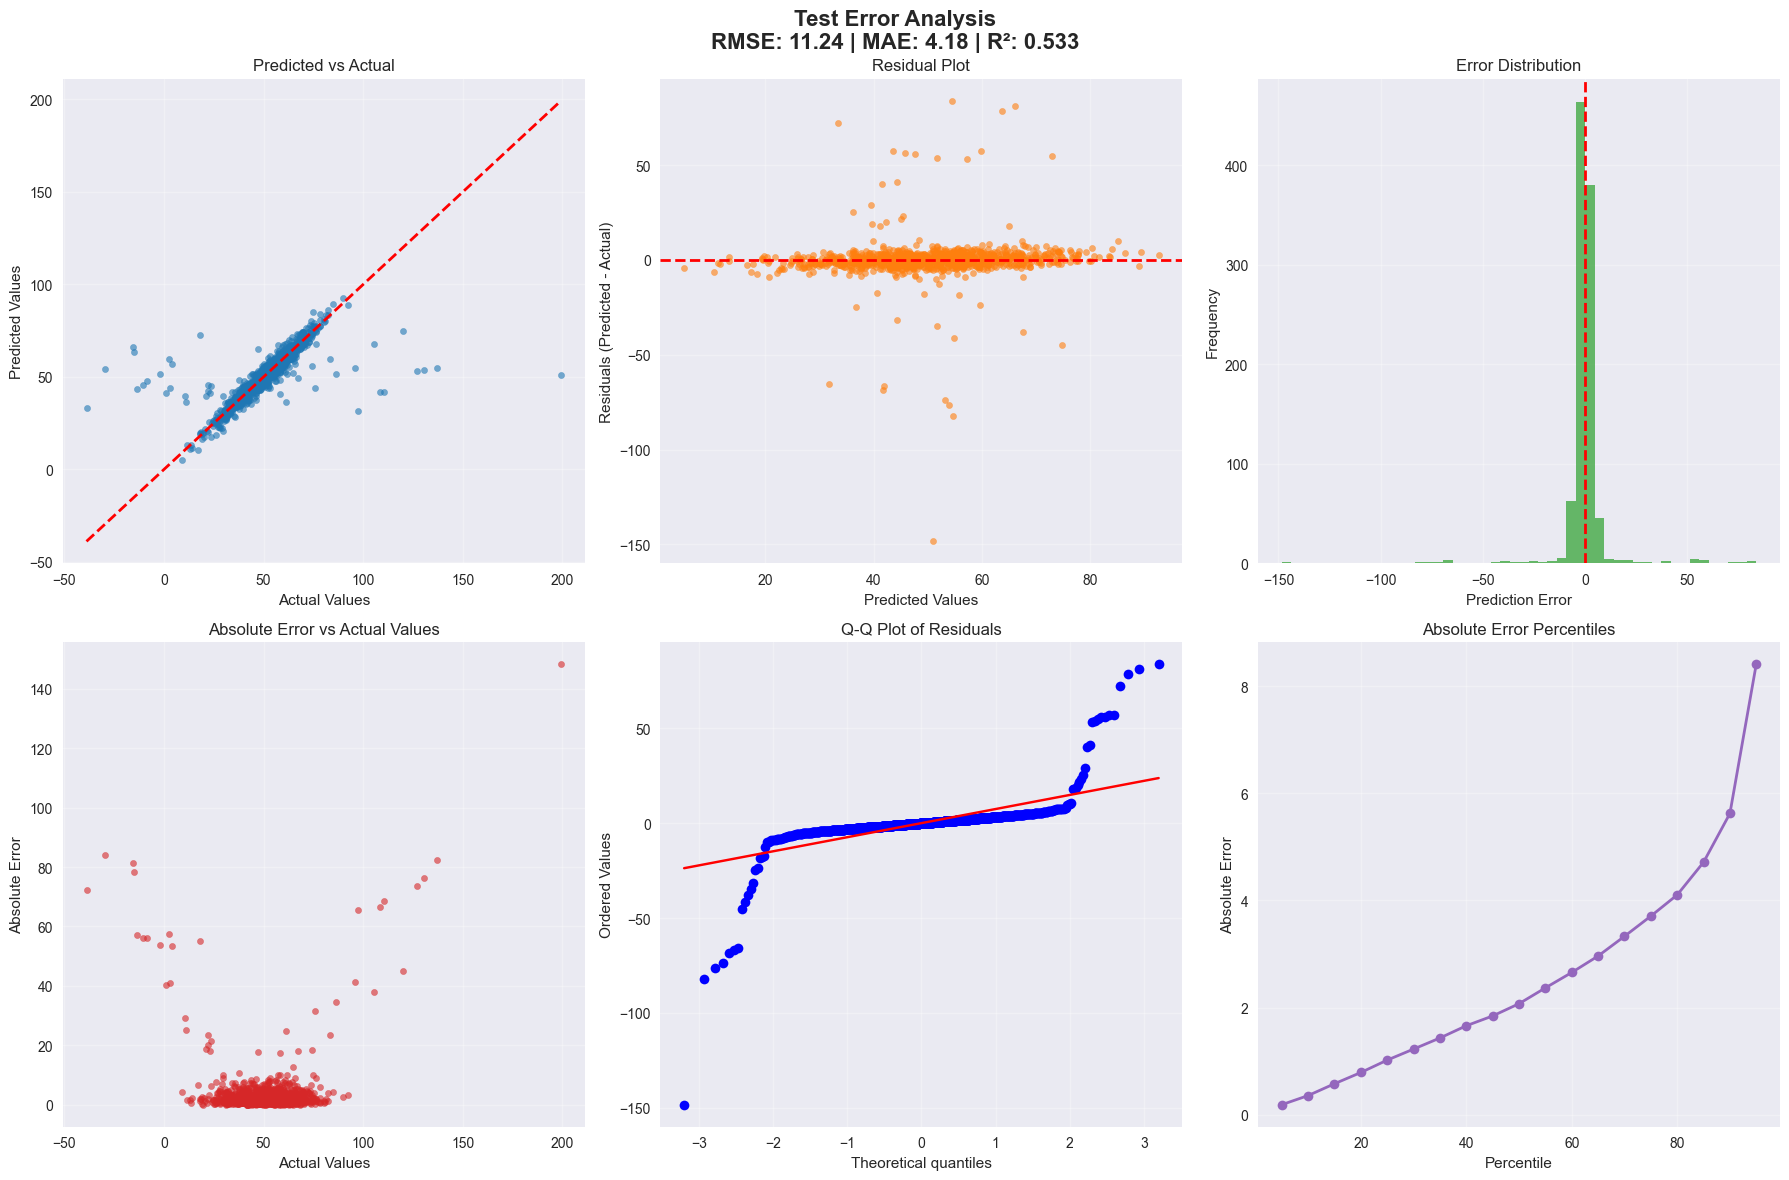


=== ERROR ANALYSIS STATISTICS ===
RMSE: 11.2370
MAE: 4.1843
R² Score: 0.5328
Mean Error: 0.0736
Std Error: 11.2367
Max Absolute Error: 148.3539
95th Percentile Absolute Error: 8.4162


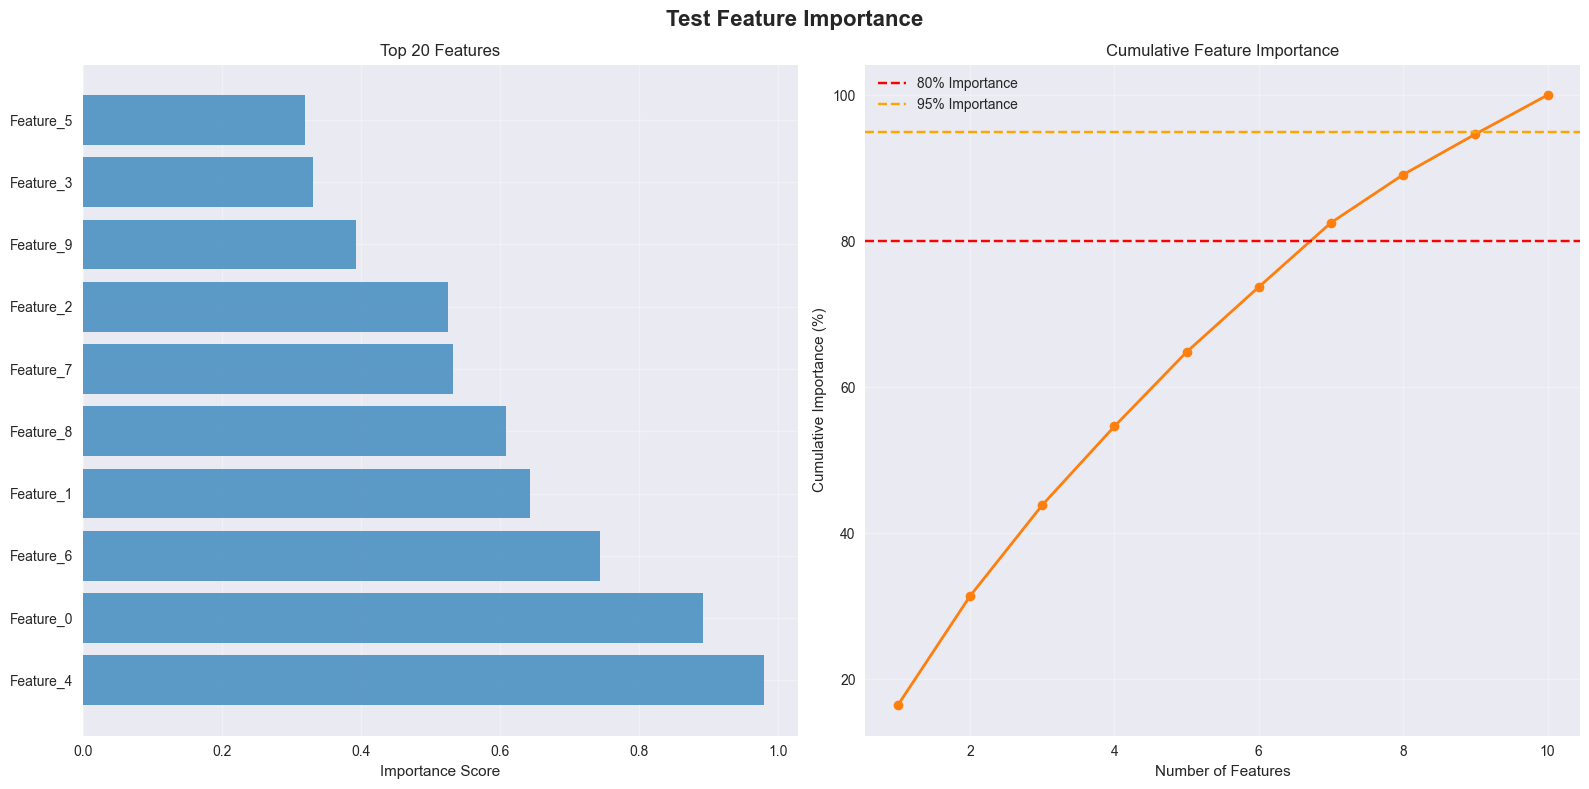


=== TOP 20 FEATURES ===
 1. Feature_4                      0.980000
 2. Feature_0                      0.892426
 3. Feature_6                      0.744186
 4. Feature_1                      0.643740
 5. Feature_8                      0.608512
 6. Feature_7                      0.531982
 7. Feature_2                      0.525489
 8. Feature_9                      0.393481
 9. Feature_3                      0.331393
10. Feature_5                      0.319696

Features needed for 80% importance: 7
Features needed for 95% importance: 10


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class ModelVisualizer:
    """
    Comprehensive visualization toolkit for model analysis
    """
    
    def __init__(self, figsize=(12, 8)):
        self.figsize = figsize
        self.colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                      '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    def plot_target_distribution(self, y_train, y_test=None, title="Target Variable Distribution"):
        """
        Plot target variable distribution analysis
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # Histogram
        axes[0, 0].hist(y_train, bins=50, alpha=0.7, color=self.colors[0], label='Train')
        if y_test is not None:
            axes[0, 0].hist(y_test, bins=50, alpha=0.7, color=self.colors[1], label='Test')
        axes[0, 0].set_title('Distribution Histogram')
        axes[0, 0].set_xlabel('Target Value')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Box plot
        data_to_plot = [y_train]
        labels = ['Train']
        if y_test is not None:
            data_to_plot.append(y_test)
            labels.append('Test')
        
        axes[0, 1].boxplot(data_to_plot, labels=labels)
        axes[0, 1].set_title('Box Plot')
        axes[0, 1].set_ylabel('Target Value')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Q-Q plot
        from scipy import stats
        stats.probplot(y_train, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Q-Q Plot (Normal Distribution)')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Log-transformed histogram
        y_log = np.log1p(y_train)
        axes[1, 1].hist(y_log, bins=50, alpha=0.7, color=self.colors[2])
        axes[1, 1].set_title('Log-Transformed Distribution')
        axes[1, 1].set_xlabel('Log(Target + 1)')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('target_distribution_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print statistics
        print("\n=== TARGET DISTRIBUTION STATISTICS ===")
        print(f"Train set:")
        print(f"  Count: {len(y_train)}")
        print(f"  Mean: {np.mean(y_train):.2f}")
        print(f"  Median: {np.median(y_train):.2f}")
        print(f"  Std: {np.std(y_train):.2f}")
        print(f"  Skewness: {stats.skew(y_train):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(y_train):.2f}")
        
        if y_test is not None:
            print(f"\nTest set:")
            print(f"  Count: {len(y_test)}")
            print(f"  Mean: {np.mean(y_test):.2f}")
            print(f"  Median: {np.median(y_test):.2f}")
            print(f"  Std: {np.std(y_test):.2f}")
    
    def plot_outlier_analysis(self, y, outlier_mask, title="Outlier Analysis"):
        """
        Visualize outlier detection results
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # Scatter plot with outliers highlighted
        normal_indices = np.where(~outlier_mask)[0]
        outlier_indices = np.where(outlier_mask)[0]
        
        axes[0, 0].scatter(normal_indices, y[normal_indices], alpha=0.6, 
                          color=self.colors[0], label='Normal', s=20)
        axes[0, 0].scatter(outlier_indices, y[outlier_indices], alpha=0.8, 
                          color=self.colors[3], label='Outliers', s=50, marker='^')
        axes[0, 0].set_title('Data Points with Outliers Highlighted')
        axes[0, 0].set_xlabel('Index')
        axes[0, 0].set_ylabel('Target Value')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Box plot comparison
        normal_data = y[~outlier_mask]
        outlier_data = y[outlier_mask]
        
        axes[0, 1].boxplot([normal_data, outlier_data], 
                          labels=['Normal', 'Outliers'])
        axes[0, 1].set_title('Distribution Comparison')
        axes[0, 1].set_ylabel('Target Value')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Histogram comparison
        axes[1, 0].hist(normal_data, bins=50, alpha=0.7, 
                        color=self.colors[0], label='Normal', density=True)
        if len(outlier_data) > 0:
            axes[1, 0].hist(outlier_data, bins=20, alpha=0.7, 
                           color=self.colors[3], label='Outliers', density=True)
        axes[1, 0].set_title('Density Distribution')
        axes[1, 0].set_xlabel('Target Value')
        axes[1, 0].set_ylabel('Density')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Percentile plot
        percentiles = np.arange(1, 100)
        perc_values = np.percentile(y, percentiles)
        
        axes[1, 1].plot(percentiles, perc_values, color=self.colors[0], linewidth=2)
        
        # Mark outlier threshold
        q1, q3 = np.percentile(y, [25, 75])
        iqr = q3 - q1
        upper_threshold = q3 + 1.5 * iqr
        
        axes[1, 1].axhline(y=upper_threshold, color=self.colors[3], 
                          linestyle='--', label=f'IQR Threshold ({upper_threshold:.1f})')
        axes[1, 1].set_title('Percentile Plot')
        axes[1, 1].set_xlabel('Percentile')
        axes[1, 1].set_ylabel('Target Value')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n=== OUTLIER ANALYSIS SUMMARY ===")
        print(f"Total data points: {len(y)}")
        print(f"Outliers detected: {np.sum(outlier_mask)} ({np.sum(outlier_mask)/len(y)*100:.2f}%)")
        print(f"Normal data points: {np.sum(~outlier_mask)} ({np.sum(~outlier_mask)/len(y)*100:.2f}%)")
        
        if np.sum(outlier_mask) > 0:
            print(f"\nOutlier statistics:")
            print(f"  Min outlier value: {np.min(outlier_data):.2f}")
            print(f"  Max outlier value: {np.max(outlier_data):.2f}")
            print(f"  Mean outlier value: {np.mean(outlier_data):.2f}")
    
    def plot_error_analysis(self, y_true, y_pred, title="Error Analysis"):
        """
        Comprehensive error analysis visualization
        """
        # Calculate errors
        errors = y_pred - y_true
        abs_errors = np.abs(errors)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'{title}\nRMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}', 
                    fontsize=16, fontweight='bold')
        
        # Predicted vs Actual
        axes[0, 0].scatter(y_true, y_pred, alpha=0.6, color=self.colors[0], s=20)
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
        axes[0, 0].set_title('Predicted vs Actual')
        axes[0, 0].set_xlabel('Actual Values')
        axes[0, 0].set_ylabel('Predicted Values')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Residual plot
        axes[0, 1].scatter(y_pred, errors, alpha=0.6, color=self.colors[1], s=20)
        axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
        axes[0, 1].set_title('Residual Plot')
        axes[0, 1].set_xlabel('Predicted Values')
        axes[0, 1].set_ylabel('Residuals (Predicted - Actual)')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Error distribution
        axes[0, 2].hist(errors, bins=50, alpha=0.7, color=self.colors[2])
        axes[0, 2].axvline(x=0, color='r', linestyle='--', linewidth=2)
        axes[0, 2].set_title('Error Distribution')
        axes[0, 2].set_xlabel('Prediction Error')
        axes[0, 2].set_ylabel('Frequency')
        axes[0, 2].grid(True, alpha=0.3)
        
        # Absolute error vs actual
        axes[1, 0].scatter(y_true, abs_errors, alpha=0.6, color=self.colors[3], s=20)
        axes[1, 0].set_title('Absolute Error vs Actual Values')
        axes[1, 0].set_xlabel('Actual Values')
        axes[1, 0].set_ylabel('Absolute Error')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Q-Q plot of residuals
        from scipy import stats
        stats.probplot(errors, dist="norm", plot=axes[1, 1])
        axes[1, 1].set_title('Q-Q Plot of Residuals')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Error percentiles
        percentiles = np.arange(5, 100, 5)
        error_percentiles = np.percentile(abs_errors, percentiles)
        
        axes[1, 2].plot(percentiles, error_percentiles, 'o-', color=self.colors[4], linewidth=2)
        axes[1, 2].set_title('Absolute Error Percentiles')
        axes[1, 2].set_xlabel('Percentile')
        axes[1, 2].set_ylabel('Absolute Error')
        axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print detailed error statistics
        print(f"\n=== ERROR ANALYSIS STATISTICS ===")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R² Score: {r2:.4f}")
        print(f"Mean Error: {np.mean(errors):.4f}")
        print(f"Std Error: {np.std(errors):.4f}")
        print(f"Max Absolute Error: {np.max(abs_errors):.4f}")
        print(f"95th Percentile Absolute Error: {np.percentile(abs_errors, 95):.4f}")
        
        return {'rmse': rmse, 'mae': mae, 'r2': r2, 'errors': errors}
    
    def plot_feature_importance(self, feature_names, importance_scores, 
                               title="Feature Importance", top_n=20):
        """
        Plot feature importance with multiple views
        """
        # Sort features by importance
        sorted_idx = np.argsort(importance_scores)[::-1]
        top_features = sorted_idx[:top_n]
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # Horizontal bar plot
        y_pos = np.arange(len(top_features))
        axes[0].barh(y_pos, importance_scores[top_features], 
                    color=self.colors[0], alpha=0.7)
        axes[0].set_yticks(y_pos)
        axes[0].set_yticklabels([feature_names[i] for i in top_features])
        axes[0].set_xlabel('Importance Score')
        axes[0].set_title(f'Top {top_n} Features')
        axes[0].grid(True, alpha=0.3)
        
        # Cumulative importance
        cumulative_importance = np.cumsum(importance_scores[sorted_idx])
        cumulative_importance = cumulative_importance / cumulative_importance[-1] * 100
        
        axes[1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
                    'o-', color=self.colors[1], linewidth=2)
        axes[1].axhline(y=80, color='r', linestyle='--', 
                       label='80% Importance')
        axes[1].axhline(y=95, color='orange', linestyle='--', 
                       label='95% Importance')
        axes[1].set_xlabel('Number of Features')
        axes[1].set_ylabel('Cumulative Importance (%)')
        axes[1].set_title('Cumulative Feature Importance')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print top features
        print(f"\n=== TOP {top_n} FEATURES ===")
        for i, idx in enumerate(top_features):
            print(f"{i+1:2d}. {feature_names[idx]:<30} {importance_scores[idx]:.6f}")
        
        # Find features for 80% and 95% importance
        idx_80 = np.where(cumulative_importance >= 80)[0][0] + 1
        idx_95 = np.where(cumulative_importance >= 95)[0][0] + 1
        
        print(f"\nFeatures needed for 80% importance: {idx_80}")
        print(f"Features needed for 95% importance: {idx_95}")
        
        return sorted_idx, importance_scores[sorted_idx]
    
    def plot_learning_curves(self, estimator, X, y, cv=5, 
                           title="Learning Curves", scoring='neg_root_mean_squared_error'):
        """
        Plot learning curves to analyze model performance vs training size
        """
        print("Generating learning curves...")
        
        train_sizes = np.linspace(0.1, 1.0, 10)
        
        train_sizes_abs, train_scores, val_scores = learning_curve(
            estimator, X, y, cv=cv, n_jobs=-1, 
            train_sizes=train_sizes, scoring=scoring,
            random_state=42
        )
        
        # Convert negative RMSE to positive
        if 'neg_' in scoring:
            train_scores = -train_scores
            val_scores = -val_scores
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        # Learning curve
        axes[0].plot(train_sizes_abs, train_mean, 'o-', color=self.colors[0], 
                    linewidth=2, label='Training Score')
        axes[0].fill_between(train_sizes_abs, train_mean - train_std, 
                           train_mean + train_std, alpha=0.2, color=self.colors[0])
        
        axes[0].plot(train_sizes_abs, val_mean, 'o-', color=self.colors[1], 
                    linewidth=2, label='Validation Score')
        axes[0].fill_between(train_sizes_abs, val_mean - val_std, 
                           val_mean + val_std, alpha=0.2, color=self.colors[1])
        
        axes[0].set_xlabel('Training Set Size')
        axes[0].set_ylabel('RMSE Score')
        axes[0].set_title('Learning Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Gap analysis
        gap = val_mean - train_mean
        axes[1].plot(train_sizes_abs, gap, 'o-', color=self.colors[2], linewidth=2)
        axes[1].fill_between(train_sizes_abs, gap, alpha=0.3, color=self.colors[2])
        axes[1].set_xlabel('Training Set Size')
        axes[1].set_ylabel('Validation - Training Score')
        axes[1].set_title('Overfitting Gap')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n=== LEARNING CURVE ANALYSIS ===")
        print(f"Final training score: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
        print(f"Final validation score: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
        print(f"Final overfitting gap: {gap[-1]:.4f}")
        
        if gap[-1] > 0.1 * val_mean[-1]:
            print("⚠️  High overfitting detected (gap > 10% of validation score)")
        elif gap[-1] < 0:
            print("⚠️  Underfitting detected (training score > validation score)")
        else:
            print("✅ Good bias-variance balance")
        
        return train_sizes_abs, train_scores, val_scores
    
    def plot_validation_curves(self, estimator, X, y, param_name, param_range, 
                             cv=5, title="Validation Curves", scoring='neg_root_mean_squared_error'):
        """
        Plot validation curves for hyperparameter tuning
        """
        print(f"Generating validation curves for {param_name}...")
        
        train_scores, val_scores = validation_curve(
            estimator, X, y, param_name=param_name, param_range=param_range,
            cv=cv, scoring=scoring, n_jobs=-1
        )
        
        # Convert negative RMSE to positive
        if 'neg_' in scoring:
            train_scores = -train_scores
            val_scores = -val_scores
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)
        
        plt.figure(figsize=(10, 6))
        
        plt.plot(param_range, train_mean, 'o-', color=self.colors[0], 
                linewidth=2, label='Training Score')
        plt.fill_between(param_range, train_mean - train_std, 
                        train_mean + train_std, alpha=0.2, color=self.colors[0])
        
        plt.plot(param_range, val_mean, 'o-', color=self.colors[1], 
                linewidth=2, label='Validation Score')
        plt.fill_between(param_range, val_mean - val_std, 
                        val_mean + val_std, alpha=0.2, color=self.colors[1])
        
        plt.xlabel(param_name)
        plt.ylabel('RMSE Score')
        plt.title(f'{title} - {param_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Mark best parameter
        best_idx = np.argmin(val_mean)
        best_param = param_range[best_idx]
        plt.axvline(x=best_param, color='red', linestyle='--', 
                   label=f'Best: {best_param}')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(f'validation_curve_{param_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Best {param_name}: {best_param}")
        print(f"Best validation score: {val_mean[best_idx]:.4f} ± {val_std[best_idx]:.4f}")
        
        return best_param, val_mean[best_idx]
    
    def create_model_comparison_plot(self, model_results, title="Model Comparison"):
        """
        Compare multiple models performance
        """
        models = list(model_results.keys())
        metrics = ['RMSE', 'MAE', 'R2']
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(title, fontsize=16, fontweight='bold')
        
        for i, metric in enumerate(metrics):
            values = [model_results[model][metric.lower()] for model in models]
            
            bars = axes[i].bar(models, values, color=self.colors[:len(models)], alpha=0.7)
            axes[i].set_title(f'{metric} Comparison')
            axes[i].set_ylabel(metric)
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, alpha=0.3)
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                height = bar.get_height()
                axes[i].text(bar.get_x() + bar.get_width()/2., height,
                           f'{value:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print ranking
        print(f"\n=== MODEL RANKING ===")
        rmse_ranking = sorted(models, key=lambda x: model_results[x]['rmse'])
        print("By RMSE (lower is better):")
        for i, model in enumerate(rmse_ranking):
            print(f"  {i+1}. {model}: {model_results[model]['rmse']:.4f}")
        
        r2_ranking = sorted(models, key=lambda x: model_results[x]['r2'], reverse=True)
        print("\nBy R² (higher is better):")
        for i, model in enumerate(r2_ranking):
            print(f"  {i+1}. {model}: {model_results[model]['r2']:.4f}")

def test_visualizer():
    """Test the visualizer with synthetic data"""
    np.random.seed(42)
    
    # Create synthetic data
    n_samples = 1000
    X = np.random.randn(n_samples, 10)
    y_true = 50 + 10 * X[:, 0] + 5 * X[:, 1] + np.random.randn(n_samples) * 5
    y_pred = y_true + np.random.randn(n_samples) * 3  # Add some prediction error
    
    # Add some outliers
    outlier_indices = np.random.choice(n_samples, 50, replace=False)
    outlier_mask = np.zeros(n_samples, dtype=bool)
    outlier_mask[outlier_indices] = True
    y_true[outlier_indices] += np.random.randn(50) * 50
    
    visualizer = ModelVisualizer()
    
    print("Testing Model Visualizer...")
    
    # Test target distribution
    visualizer.plot_target_distribution(y_true, title="Test Target Distribution")
    
    # Test outlier analysis
    visualizer.plot_outlier_analysis(y_true, outlier_mask, title="Test Outlier Analysis")
    
    # Test error analysis
    visualizer.plot_error_analysis(y_true, y_pred, title="Test Error Analysis")
    
    # Test feature importance
    feature_names = [f'Feature_{i}' for i in range(10)]
    importance_scores = np.random.rand(10)
    visualizer.plot_feature_importance(feature_names, importance_scores, 
                                     title="Test Feature Importance")

if __name__ == "__main__":
    test_visualizer()

# Preprocessing File Putusan

In [4]:
import os
import re
import tokenize
import pandas as pd

BASE_DIR = r"c:\Users\adief\OneDrive\Dokumen\Lomba\Dataquest 4.0"
IN_DIR = os.path.join(BASE_DIR, "file_putusan", "file_putusan")
OUT_DIR = os.path.join(BASE_DIR, "file_putusan_preprocessed")

def ensure_out_dir():
    os.makedirs(OUT_DIR, exist_ok=True)

def collapse_spaces(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def find_sentence_boundaries(text: str, start_idx: int, max_ahead_chars: int = 1200) -> str:
    """
    Ambil potongan kalimat dari start_idx hingga tanda akhir kalimat umum.
    """
    end_candidates = []
    window_end = min(len(text), start_idx + max_ahead_chars)
    window = text[start_idx:window_end]

    for m in re.finditer(r"[.;](?!\d)|\n{2,}", window):
        end_candidates.append(start_idx + m.end())

    if end_candidates:
        end = min(end_candidates)
        return text[start_idx:end]

    m = re.search(r"\n{2,}", window)
    if m:
        return text[start_idx:start_idx + m.start()]
    return text[start_idx:window_end]

MAIN_PATTERN = re.compile(
    r"menjatuhkan\s+pidana.*?(?:tahun|bulan|hari).*?(?:\.)",
    flags=re.IGNORECASE | re.DOTALL
)

MAIN_FALLBACK_PATTERN = re.compile(
    r"menjatuhkan\s+pidana.*?(?:tahun|bulan|hari)",
    flags=re.IGNORECASE | re.DOTALL
)

ADJ_KEYWORDS = [
    r"dikurangkan", r"dikurangi", r"mengurangkan", r"mengurangi",
    r"ditambah", r"menambah", r"menambahkan",
    r"subsider", r"subsidair"
]
ADJ_CONTEXT = [
    r"masa\s+penahanan", r"masa\s+tahanan", r"masa\s+penangkapan", r"masa\s+kurungan"
]
ADJ_PATTERN = re.compile(
    rf"(?i)(?:{'|'.join(ADJ_KEYWORDS)}).*?(?:{'|'.join(ADJ_CONTEXT)})|(?:{'|'.join(ADJ_CONTEXT)}).*?(?:{'|'.join(ADJ_KEYWORDS)})",
    flags=re.DOTALL
)

# (Tambahan pola dan fungsi ekstraksi baru; letakkan setelah ADJ_PATTERN dan sebelum process_file)

# --- Optional NLP backends (hybrid) ---
import spacy
import stanza
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Global NLP context (diisi di main)
NLP_MODELS = {
    "spacy": None,
    "stanza": stanza.Pipeline(lang="id", processors="tokenize,pos,lemma,depparse"), 
    "stemmer": StemmerFactory().create_stemmer(),
    "backend": {"name": "regex_only", "has_ner": True, "has_dep": True, "lemmatizer": "none"},
}

NEGATION_WORDS = ["tidak", "bukan", "belum", "tak", "tiada", "jangan", "kecuali"]
HYPOTHETICAL_MARKERS = ["apabila", "jika", "bilamana", "sekiranya", "andaikata", "kalau"]

# Akronim/standar istilah umum (disesuaikan agar aman pada teks hukum)
ACRONYM_MAP = {
    r"\bNo\.\b": "Nomor",
    r"\bNo\b": "Nomor", 
    r"\bjo\.\b": "junto",
}

def init_nlp():
    """
    Inisialisasi pipeline NLP secara opsional:
    - SpaCy: id_core_news_sm (jika ada) atau xx_sent_ud_sm (sentencizer)
    - Stanza: tokenize,pos,lemma,depparse,ner (jika tersedia)
    - Sastrawi: stemmer (jika terpasang)
    """
    backend = {"name": "regex_only", "has_ner": True, "has_dep": True, "lemmatizer": "none"}
    nlp_spacy = None
    nlp_stanza = stanza.Pipeline(lang="id", processors="tokenize,pos,lemma,depparse")
    stemmer = StemmerFactory().create_stemmer()
    if spacy is not None:
        try:
            nlp_spacy = spacy.load("id_core_news_sm")
            backend["name"] = "spacy_id"
            backend["has_ner"] = "ner" in nlp_spacy.pipe_names
            backend["has_dep"] = ("parser" in nlp_spacy.pipe_names) or ("dep" in nlp_spacy.pipe_names)
            backend["lemmatizer"] = "lemmatizer" if "lemmatizer" in nlp_spacy.pipe_names else backend["lemmatizer"]
        except Exception:
            try:
                nlp_spacy = spacy.load("xx_sent_ud_sm")
                backend["name"] = "spacy_xx"
                backend["has_ner"] = "ner" in nlp_spacy.pipe_names
                backend["has_dep"] = ("parser" in nlp_spacy.pipe_names)
                backend["lemmatizer"] = "lemmatizer" if "lemmatizer" in nlp_spacy.pipe_names else backend["lemmatizer"]
            except Exception:
                nlp_spacy = None

    if stanza is not None:
        try:
            # Catatan: jika model belum terunduh, stanza akan mencoba mengunduh (butuh internet)
            nlp_stanza = stanza.Pipeline(
                lang="id", processors="tokenize,pos,lemma,depparse,ner", tokenize_no_ssplit=False, verbose=False
            )
            backend["name"] = (backend["name"] + "+stanza") if nlp_spacy else "stanza"
            backend["has_ner"] = True
            backend["has_dep"] = True
            backend["lemmatizer"] = "lemma"
        except Exception:
            nlp_stanza = None

    if StemmerFactory is not None:
        try:
            stemmer = StemmerFactory().create_stemmer()
            if backend["lemmatizer"] == "none":
                backend["lemmatizer"] = "sastrawi"
        except Exception:
            stemmer = None

    return nlp_spacy, nlp_stanza, stemmer, backend

def normalize_acronyms(text: str) -> str:
    normalized = text
    for pattern, repl in ACRONYM_MAP.items():
        normalized = re.sub(pattern, repl, normalized, flags=re.IGNORECASE)
    return normalized

def preprocess_text(text: str) -> str:
    """
    Normalisasi global yang aman:
    - Lowercasing
    - Standardisasi akronim umum
    - Collapse whitespace
    """
    t = text.lower()
    t = normalize_acronyms(t)
    t = re.sub(r"[ \t]+", " ", t)
    t = re.sub(r"\u00A0", " ", t)  # non-breaking space
    t = re.sub(r"\s+\n", "\n", t)
    t = re.sub(r"\n\s+", "\n", t)
    return collapse_spaces(t)

def parse_currency_to_int(amount_str: str) -> int | None:
    """
    Konversi string mata uang Indonesia menjadi integer rupiah.
    Contoh: 'Rp. 5.000.000,-' -> 5000000
    """
    if not amount_str:
        return None
    s = amount_str
    s = s.replace(" ", "")
    s = s.replace("Rp.", "").replace("Rp", "")
    s = s.replace(",-", "")
    # Sisakan hanya digit, titik, koma, minus
    s = re.sub(r"[^0-9\.,-]", "", s)
    # Hilangkan tanda minus jika ada (nilai rupiah seharusnya positif)
    s = s.replace("-", "")
    # Asumsi '.' adalah pemisah ribuan dan ',' pemisah desimal
    # Abaikan bagian desimal jika ada
    if "," in s:
        s = s.split(",")[0]
    s = s.replace(".", "")
    try:
        return int(s)
    except Exception:
        return None

def has_negation_near(text: str, match_start: int, window: int = 60) -> bool:
    """
    Deteksi kata negasi di sekitar posisi match.
    """
    s = text.lower()
    left = max(0, match_start - window)
    right = min(len(text), match_start + window)
    ctx = s[left:right]
    return any(re.search(rf"\b{w}\b", ctx) for w in NEGATION_WORDS)

def is_hypothetical_sentence(sentence: str) -> bool:
    s = sentence.lower()
    return any(re.search(rf"\b{w}\b", s) for w in HYPOTHETICAL_MARKERS)

def extract_money_via_ner(text: str) -> tuple[list[str], list[str]]:
    """
    Gunakan NER (jika tersedia) untuk mengekstrak entitas uang.
    Mengembalikan (amount_texts, evidence_snippets)
    """
    amounts = []
    evidences = []
    try:
        if NLP_MODELS.get("spacy") is not None and NLP_MODELS["backend"].get("has_ner"):
            doc = NLP_MODELS["spacy"](text)
            for ent in getattr(doc, "ents", []):
                if str(getattr(ent, "label_", "")).lower() in ("money", "mny", "currency"):
                    amounts.append(ent.text)
                    evidences.append(collapse_spaces(ent.sent.text))
        elif NLP_MODELS.get("stanza") is not None and NLP_MODELS["backend"].get("has_ner"):
            doc = NLP_MODELS["stanza"](text)
            for ent in getattr(doc, "ents", []):
                if getattr(ent, "type", "") == "MONEY":
                    amounts.append(ent.text)
                    try:
                        evidences.append(find_snippet(text, ent.start_char))
                    except Exception:
                        evidences.append(ent.text)
    except Exception:
        # Fallback silent jika backend gagal
        pass
    # Dedup
    amounts = list(dict.fromkeys(amounts))
    evidences = list(dict.fromkeys(evidences))
    return amounts, evidences

MAIN_PATTERN = re.compile(
    r"menjatuhkan\s+pidana.*?(?:tahun|bulan|hari).*?(?:\.)",
    flags=re.IGNORECASE | re.DOTALL
)

MAIN_FALLBACK_PATTERN = re.compile(
    r"menjatuhkan\s+pidana.*?(?:tahun|bulan|hari)",
    flags=re.IGNORECASE | re.DOTALL
)

ADJ_KEYWORDS = [
    r"dikurangkan", r"dikurangi", r"mengurangkan", r"mengurangi",
    r"ditambah", r"menambah", r"menambahkan",
    r"subsider", r"subsidair"
]
ADJ_CONTEXT = [
    r"masa\s+penahanan", r"masa\s+tahanan", r"masa\s+penangkapan", r"masa\s+kurungan"
]
ADJ_PATTERN = re.compile(
    rf"(?i)(?:{'|'.join(ADJ_KEYWORDS)}).*?(?:{'|'.join(ADJ_CONTEXT)})|(?:{'|'.join(ADJ_CONTEXT)}).*?(?:{'|'.join(ADJ_KEYWORDS)})",
    flags=re.DOTALL
)

# Pola untuk status kooperatif terdakwa
COOP_POSITIVE_PATTERNS = [
    r"\bmengaku(?:i)?\s+(?:bersalah|perbuatannya?)\b",
    r"\bberterus\s*terang\b",
    r"\bmenyesal[i]?(?:\s+atas\s+perbuatannya)?\b",
    r"\bbersikap\s+sopan\b",
    r"\bsopan\s+di\s+persidangan\b",
    r"\bkooperatif\b",
    r"\bsikap\s+kooperatif\b",
]

COOP_NEGATIVE_PATTERNS = [
    r"\btidak\s+mengaku(?:i)?\b",
    r"\bberbelit[-\s]?belit\b",
    r"\btidak\s+kooperatif\b",
    r"\btidak\s+sopan\b",
]

# Pola umum untuk meringankan/memberatkan (reasoning perilaku)
MITIGATING_PATTERNS = [
    r"\bhal[-\s]*hal\s+yang\s+meringankan\b",
    r"\bpertimbangan\s+yang\s+meringankan\b",
    r"\bmengaku(?:i)?\s+(?:bersalah|perbuatannya?)\b",
    r"\bberterus\s*terang\b",
    r"\bmenyesal[i]?\b",
    r"\bbersikap\s+sopan\b",
    r"\bbelum\s+pernah\s+dihukum\b",
    r"\bmempunyai\s+tanggungan\s+keluarga\b",
    r"\bkooperatif\b",
]

AGGRAVATING_PATTERNS = [
    r"\bhal[-\s]*hal\s+yang\s+memberatkan\b",
    r"\bpertimbangan\s+yang\s+memberatkan\b",
    r"\btidak\s+mengaku(?:i)?\b",
    r"\bberbelit[-\s]?belit\b",
    r"\btidak\s+kooperatif\b",
    r"\btidak\s+sopan\b",
    r"\bpernah\s+dihukum\b",
    r"\bperbuatannya\s+meresahkan\s+masyarakat\b",
    r"\btidak\s+mendukung\s+program\s+pemerintah\b",
]

# Pola status pembayaran denda
FINE_PAID_PATTERNS = [
    r"\btelah\s+membayar\s+denda\b",
    r"\bdenda\s+telah\s+dibayar\b",
    r"\btelah\s+melunasi\s+denda\b",
    r"\bmembayar\s+denda\s+sebesar\b",
]

FINE_NOT_PAID_PATTERNS = [
    r"\b(tidak|belum)\s+membayar\s+denda\b",
    r"\bdenda\s+tidak\s+dibayar\b",
]

FINE_SUBSIDIARY_CLAUSE_PATTERNS = [
    r"\b(apabila|jika|bilamana)\s+[^.]{0,120}denda\s+tidak\s+dibayar[^.]{0,120}(diganti|subsider|subsidair)\b",
    r"\bdenda[^.]{0,120}(subsider|subsidair)\b",
]

# Pola untuk ekstraksi jumlah denda
FINE_AMOUNT_PATTERNS = [
    r"denda\s+sebesar\s+(Rp\.?\s*\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})?(?:,-)?)",
    r"pidana\s+denda\s+sebesar\s+(Rp\.?\s*\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})?(?:,-)?)",
    r"denda\s+sejumlah\s+(Rp\.?\s*\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})?(?:,-)?)",
    r"denda\s+(Rp\.?\s*\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})?(?:,-)?)",
    r"membayar\s+denda\s+sebesar\s+(Rp\.?\s*\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})?(?:,-)?)",
]

def normalize_currency_format(amount_str: str) -> str:
    """
    Menormalkan format mata uang Indonesia ke format yang konsisten.
    Contoh: "Rp. 5.000.000,-" -> "Rp. 5.000.000"
    """
    if not amount_str:
        return ""
    
    # Bersihkan dan normalisasi
    normalized = amount_str.strip()
    
    # Hapus trailing ",-" jika ada
    if normalized.endswith(",-"):
        normalized = normalized[:-2]
    
    # Pastikan format "Rp. " konsisten
    if normalized.startswith("Rp"):
        if not normalized.startswith("Rp. "):
            normalized = normalized.replace("Rp", "Rp. ", 1)
    
    return normalized

def extract_fine_amount(text: str) -> tuple[str, str, list[str]]:
    """
    Mengekstrak jumlah denda dari teks putusan.
    Mengembalikan:
      - fine_amount: jumlah denda yang dinormalisasi (contoh: "Rp. 5.000.000")
      - raw_fine_amount: jumlah denda mentah sebelum normalisasi
      - evidence: list snippet bukti denda
    """
    fine_amounts = []
    evidence_snippets = []

    # 1) Coba NER (jika tersedia)
    ner_amounts, ner_evidences = extract_money_via_ner(text)
    for a, e in zip(ner_amounts, ner_evidences or [None] * len(ner_amounts)):
        if a and a not in fine_amounts:
            fine_amounts.append(a)
            if e and e not in evidence_snippets:
                evidence_snippets.append(e)

    # 2) Fallback dengan regex
    lower_text = text.lower()
    for pattern in FINE_AMOUNT_PATTERNS:
        for match in re.finditer(pattern, lower_text, flags=re.IGNORECASE):
            if match.groups():
                raw_amount = match.group(1)
                snippet = find_snippet(text, match.start())
                if raw_amount and raw_amount not in fine_amounts:
                    fine_amounts.append(raw_amount)
                if snippet and snippet not in evidence_snippets:
                    evidence_snippets.append(snippet)

    if fine_amounts:
        # Ambil kandidat yang pertama atau paling "panjang" (sering lebih spesifik)
        fine_amounts_sorted = sorted(fine_amounts, key=lambda x: len(x or ""), reverse=True)
        raw_amount = fine_amounts_sorted[0]
        normalized_amount = normalize_currency_format(raw_amount)
        return normalized_amount, raw_amount, evidence_snippets

    return "", "", []

def extract_fine_payment_status(text: str) -> tuple[str, bool, list[str]]:
    """
    Mengembalikan:
      - fine_payment_status: 'paid' | 'not_paid' | 'unknown'
      - fine_subsidiary_clause_present: bool
      - evidence: list snippet bukti
    Catatan: klausul 'apabila denda tidak dibayar ... subsider' TIDAK berarti denda benar-benar tidak dibayar.
             Itu hanya ketentuan. Karena itu dideteksi sebagai subsidiary_clause, tetapi status = 'unknown' jika
             tidak ada frasa eksplisit 'telah membayar' atau 'tidak/belum membayar' di kalimat non-hipotetis.
    """
    paid_snips = collect_snippets_by_patterns(text, FINE_PAID_PATTERNS)
    not_paid_snips = collect_snippets_by_patterns(text, FINE_NOT_PAID_PATTERNS)
    subs_clause_snips = collect_snippets_by_patterns(text, FINE_SUBSIDIARY_CLAUSE_PATTERNS)

    subsidiary = len(subs_clause_snips) > 0

    # Filter 'not_paid' yang hanya muncul pada kalimat hipotetis
    not_paid_non_hypo = []
    not_paid_hypo = []
    for sn in not_paid_snips:
        if is_hypothetical_sentence(sn):
            not_paid_hypo.append(sn)
        else:
            not_paid_non_hypo.append(sn)

    # Keputusan prioritas
    if paid_snips:
        return "paid", subsidiary, paid_snips
    if not_paid_non_hypo:
        # Terdapat bukti eksplisit tidak bayar di kalimat non-hipotetis
        return "not_paid", subsidiary, not_paid_non_hypo

    # Jika hanya ada klausul subsider / hipotetis -> unknown
    evidences = subs_clause_snips or not_paid_hypo
    return "unknown", subsidiary, evidences

def find_snippet(text: str, start_idx: int) -> str:
    # Gunakan utilitas yang sudah ada untuk mengembalikan potongan kalimat ringkas
    return collapse_spaces(find_sentence_boundaries(text, start_idx, max_ahead_chars=300))
    # Override dengan segmentasi berbasis NLP jika tersedia (lebih andal)
    try:
        if NLP_MODELS.get("spacy") is not None:
            # Proses dalam jendela sekitar start_idx agar hemat
            left = max(0, start_idx - 400)
            right = min(len(text), start_idx + 400)
            sub = text[left:right]
            doc = NLP_MODELS["spacy"](sub)
            offset = start_idx - left
            for sent in getattr(doc, "sents", []):
                if sent.start_char <= offset <= sent.end_char:
                    return collapse_spaces(sub[sent.start_char:sent.end_char])
    except Exception:
        pass
    return collapse_spaces(find_sentence_boundaries(text, start_idx, max_ahead_chars=300))

def collect_snippets_by_patterns(text: str, patterns: list[str]) -> list[str]:
    results = []
    lower_text = text.lower()
    for pat in patterns:
        for m in re.finditer(pat, lower_text, flags=re.IGNORECASE):
            snippet = find_snippet(text, m.start())
            if snippet and snippet not in results:
                results.append(snippet)
    return results

def extract_cooperation(text: str) -> tuple[str, list[str]]:
    """
    Mengembalikan:
      - status: 'cooperative' | 'not_cooperative' | 'mixed' | 'unknown'
      - evidence: list snippet bukti
    """
    pos_snips = collect_snippets_by_patterns(text, COOP_POSITIVE_PATTERNS)
    neg_snips = collect_snippets_by_patterns(text, COOP_NEGATIVE_PATTERNS)

    if pos_snips and not neg_snips:
        return "cooperative", pos_snips
    if neg_snips and not pos_snips:
        return "not_cooperative", neg_snips
    if pos_snips and neg_snips:
        # Ada indikasi campuran, simpan kedua bukti
        return "mixed", list(dict.fromkeys(pos_snips + neg_snips))
    return "unknown", []

def extract_mitigation_aggravation(text: str) -> tuple[list[str], list[str], str]:
    """
    Mengembalikan:
      - mitigating_reasons: daftar snippet meringankan
      - aggravating_reasons: daftar snippet memberatkan
      - behavioral_impact: 'mitigating' | 'aggravating' | 'both' | 'none'
    """
    mit_snips = collect_snippets_by_patterns(text, MITIGATING_PATTERNS)
    agg_snips = collect_snippets_by_patterns(text, AGGRAVATING_PATTERNS)

    if mit_snips and not agg_snips:
        impact = "mitigating"
    elif agg_snips and not mit_snips:
        impact = "aggravating"
    elif mit_snips and agg_snips:
        impact = "both"
    else:
        impact = "none"

    return mit_snips, agg_snips, impact

def extract_main_sentence(text: str) -> str | None:
    lower_text = text.lower()
    m = re.search(MAIN_PATTERN, lower_text)
    if m:
        return collapse_spaces(text[m.start():m.end()])
    m2 = re.search(MAIN_FALLBACK_PATTERN, lower_text)
    if m2:
        return collapse_spaces(find_sentence_boundaries(text, m2.start()))
    return None

def extract_adjustments(text: str) -> list[str]:
    results = []
    lower_text = text.lower()
    for m in re.finditer(ADJ_PATTERN, lower_text):
        snippet = collapse_spaces(find_sentence_boundaries(text, m.start()))
        if snippet and snippet not in results:
            results.append(snippet)
    return results

def build_minimal_keypoints(main_sentence: str | None, adjustments: list[str]) -> str:
    parts = []
    if main_sentence:
        parts.append(main_sentence)
    for adj in adjustments:
        parts.append(adj)
    return " ".join(parts).strip()

def read_text(path: str) -> str:
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1", errors="ignore") as f:
            return f.read()

def write_text(path: str, content: str):
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

def process_file(in_path: str, out_path: str):
    text = read_text(in_path)
    main_sentence = extract_main_sentence(text)
    adjustments = extract_adjustments(text)
    key_points = build_minimal_keypoints(main_sentence, adjustments)
    # Tulis isi minimal; jika kosong, biarkan kosong (tetap membuat file)
    write_text(out_path, key_points)

    # Ekstraksi tambahan
    coop_status, coop_evidence = extract_cooperation(text)
    mit_reasons, agg_reasons, behavioral_impact = extract_mitigation_aggravation(text)
    fine_payment_status, fine_subsidiary_clause, fine_evidence = extract_fine_payment_status(text)
    fine_amount, raw_fine_amount, fine_amount_evidence = extract_fine_amount(text)

    # Validasi angka rupiah
    fine_amount_value = parse_currency_to_int(fine_amount or raw_fine_amount)

    # Kembalikan metadata untuk agregasi ke CSV
    fname = os.path.basename(in_path)
    doc_id = os.path.splitext(fname)[0]  # contoh: 'doc_3204'
    return {
        "doc_id": doc_id,
        "cooperation_status": coop_status,  # cooperative | not_cooperative | mixed | unknown
        "cooperation_evidence": " || ".join(coop_evidence) if coop_evidence else "",
        "fine_payment_status": fine_payment_status,  # paid | not_paid | unknown
        "fine_subsidiary_clause_present": fine_subsidiary_clause,  # True/False
        "fine_evidence": " || ".join(fine_evidence) if fine_evidence else "",
        "fine_amount": fine_amount,  # jumlah denda yang dinormalisasi
        "raw_fine_amount": raw_fine_amount,  # jumlah denda mentah
        "fine_amount_value": fine_amount_value,  # nilai numerik hasil validasi (int rupiah)
        "fine_amount_evidence": " || ".join(fine_amount_evidence) if fine_amount_evidence else "",
        "mitigating_reasons": " || ".join(mit_reasons) if mit_reasons else "",
        "aggravating_reasons": " || ".join(agg_reasons) if agg_reasons else "",
        "behavioral_impact": behavioral_impact,  # mitigating | aggravating | both | none
        "extracted_key_points_text": key_points,  # tetap simpan ringkasan lama untuk referensi
        "nlp_backend": NLP_MODELS.get("backend", {}).get("name"),
    }

# (Modifikasi main untuk mengagregasi metadata dan menyimpan ke CSV)

def main():
    if not os.path.isdir(IN_DIR):
        raise FileNotFoundError(f"Folder input tidak ditemukan: {IN_DIR}")
    ensure_out_dir()

    # Inisialisasi NLP hybrid (opsional)
    global NLP_MODELS
    spacy_nlp, stanza_nlp, stemmer, backend = init_nlp()
    NLP_MODELS = {
        "spacy": spacy_nlp,
        "stanza": stanza_nlp,
        "stemmer": stemmer,
        "backend": backend,
    }

    files = [f for f in os.listdir(IN_DIR) if f.lower().endswith(".txt")]
    total = len(files)
    print(f"Menemukan {total} file .txt")
    print(f"NLP Backend: {backend}")

    processed = 0
    records = []  # <- agregasi metadata baru

    for i, fname in enumerate(sorted(files), start=1):
        in_path = os.path.join(IN_DIR, fname)
        out_path = os.path.join(OUT_DIR, fname)
        try:
            meta = process_file(in_path, out_path)
            processed += 1
            if meta:
                records.append(meta)
        except Exception as e:
            print(f"[WARN] Gagal memproses {fname}: {e}")
        if i % 200 == 0 or i == total:
            print(f"- Progress: {i}/{total} file")

    print(f"Selesai. Berhasil memproses {processed}/{total} file.")
    print(f"Hasil disimpan di: {OUT_DIR}")

    # Simpan metadata ekstraksi tambahan ke CSV untuk kebutuhan model
    if records:
        df = pd.DataFrame(records)
        csv_out = os.path.join(BASE_DIR, "preprocessed_extracted_features2.csv")
        df.to_csv(csv_out, index=False, encoding="utf-8")
        print(f"Fitur ekstraksi tambahan disimpan di: {csv_out}")

if __name__ == "__main__":
    main()

2025-09-02 23:56:14 ERROR: Cannot load model from C:\Users\adief\stanza_resources\id\ner\default.pt


Menemukan 23675 file .txt
NLP Backend: {'name': 'regex_only', 'has_ner': True, 'has_dep': True, 'lemmatizer': 'sastrawi'}


KeyboardInterrupt: 

In [3]:
# Get list of files in the preprocessed folder
preprocessed_folder = 'file_putusan_preprocessed'
files = os.listdir(preprocessed_folder)

# Check each file
empty_files = []
non_empty_files = []

for file in files:
    if file.endswith('.txt'):
        file_path = os.path.join(preprocessed_folder, file)
        
        # Check if file is empty
        if os.path.getsize(file_path) == 0:
            empty_files.append(file)
        else:
            non_empty_files.append(file)

print("Empty files:")
for file in empty_files:
    print(f"- {file}")

print("\nNon-empty files:")
for file in non_empty_files:
    print(f"- {file}")

print(f"\nTotal empty files: {len(empty_files)}")
print(f"Total non-empty files: {len(non_empty_files)}")


Empty files:
- doc_10004.txt
- doc_1002.txt
- doc_101.txt
- doc_10176.txt
- doc_10200.txt
- doc_10491.txt
- doc_10757.txt
- doc_10802.txt
- doc_10831.txt
- doc_10853.txt
- doc_10933.txt
- doc_11068.txt
- doc_11073.txt
- doc_11143.txt
- doc_11409.txt
- doc_11532.txt
- doc_11534.txt
- doc_11608.txt
- doc_11625.txt
- doc_11708.txt
- doc_11726.txt
- doc_11746.txt
- doc_11819.txt
- doc_11843.txt
- doc_11851.txt
- doc_11918.txt
- doc_11925.txt
- doc_11954.txt
- doc_12047.txt
- doc_12066.txt
- doc_12189.txt
- doc_12356.txt
- doc_12368.txt
- doc_1245.txt
- doc_12503.txt
- doc_1255.txt
- doc_12585.txt
- doc_1267.txt
- doc_12754.txt
- doc_12775.txt
- doc_12904.txt
- doc_1299.txt
- doc_13064.txt
- doc_13131.txt
- doc_13180.txt
- doc_13328.txt
- doc_13613.txt
- doc_13633.txt
- doc_13716.txt
- doc_13824.txt
- doc_13856.txt
- doc_1388.txt
- doc_13881.txt
- doc_13960.txt
- doc_14071.txt
- doc_14107.txt
- doc_1415.txt
- doc_14165.txt
- doc_14274.txt
- doc_14310.txt
- doc_14351.txt
- doc_14357.txt
- do

# NLP Penentuan Masa Hukuman

## 1

In [4]:
import os
import re
import sys
import math
import warnings
from typing import Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
# Konfigurasi path
BASE_DIR = r"c:\Users\adief\OneDrive\Dokumen\Lomba\Dataquest 4.0"
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")
SAMPLE_SUB = os.path.join(BASE_DIR, "sample_submission.csv")
PREP_DIR = os.path.join(BASE_DIR, "file_putusan_preprocessed")
OUT_SUBMISSION = os.path.join(BASE_DIR, "submission.csv")

# 1) Utilitas baca teks preprocessed
def read_preprocessed_text(doc_id: str) -> Tuple[str, bool]:
    """
    Mengembalikan (text, is_missing).
    is_missing = True jika file tidak ada / tidak terbaca / konten kosong.
    """
    fname = f"{doc_id}.txt"
    fpath = os.path.join(PREP_DIR, fname)
    if not os.path.exists(fpath):
        return "", True
    try:
        with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
            txt = f.read().strip()
        if not txt:
            return "", True
        return txt, False
    except Exception:
        return "", True

# 2) Parser sederhana untuk mengekstrak lama hukuman (dalam bulan) dari teks dengan digit
#    - Prioritaskan pola: "<angka> tahun <angka> bulan" atau "<angka> tahun" atau "<angka> bulan"
#    - Hanya menangkap digit, bukan kata bilangan, agar robust dan cepat
RE_YM = re.compile(r"(?P<y>\d+)\s*tahun(?:\s*(?P<m>\d+)\s*bulan)?", re.IGNORECASE)
RE_M = re.compile(r"(?P<m>\d+)\s*bulan", re.IGNORECASE)

def parse_months_from_text(text: str) -> Optional[int]:
    """
    Coba ekstrak jumlah bulan dari pola angka di teks.
    Return int bulan jika ketemu, else None.
    """
    # Cari "X tahun Y bulan" atau "X tahun"
    m = RE_YM.search(text)
    if m:
        years = int(m.group("y"))
        months = int(m.group("m")) if m.group("m") else 0
        total = years * 12 + months
        return int(total)

    # Cari "X bulan"
    m2 = RE_M.search(text)
    if m2:
        months = int(m2.group("m"))
        return int(months)

    return None

# 3) Loader data
def load_train() -> pd.DataFrame:
    df = pd.read_csv(TRAIN_CSV)
    # Normalisasi kolom
    df = df.rename(columns={df.columns[0]: "id", df.columns[1]: "target"})
    return df

def load_test() -> pd.DataFrame:
    df = pd.read_csv(TEST_CSV)
    # Pastikan ada kolom 'id'
    if "id" not in df.columns:
        # Jika format satu kolom tanpa header, coba paksa nama 'id'
        # (fallback, namun test.csv Anda sudah mengandung header 'id')
        df.columns = ["id"]
    return df

# 4) Siapkan dataframe train/test dengan fitur text dan flag is_missing
def build_dataset(df_ids: pd.DataFrame) -> pd.DataFrame:
    texts = []
    miss = []
    parsed = []
    for doc_id in df_ids["id"].astype(str).tolist():
        t, is_miss = read_preprocessed_text(doc_id)
        texts.append(t)
        miss.append(1 if is_miss else 0)
        parsed_val = parse_months_from_text(t) if not is_miss and t else None
        parsed.append(parsed_val if parsed_val is not None else np.nan)
    out = df_ids.copy()
    out["text"] = texts
    out["is_missing"] = miss
    out["parsed_months"] = parsed
    return out

# 5) Pipeline ML: TF-IDF char n-grams + Ridge Regression
def build_model():
    # Kita pakai text saja untuk vectorizer (char ngram), numeric feature (is_missing) tidak dipakai langsung ke TF-IDF,
    # tapi kita akan trust rule is_missing -> 0 setelah prediksi model
    text_feature = "text"

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        max_features=200000,
        lowercase=True
    )

    model = Ridge(alpha=5.0, random_state=42)

    pipe = Pipeline([
        ("tfidf", vectorizer),
        ("reg", model)
    ])
    return pipe

def main():
    # Load data
    train_df = load_train()
    test_df = load_test()

    # Build datasets (baca teks preprocessed)
    tr = build_dataset(train_df[["id"]])
    te = build_dataset(test_df[["id"]])

    # Gabungkan target
    tr = tr.merge(train_df, on="id", how="left")

    # Logging ringkas
    n_tr_miss = tr["is_missing"].sum()
    n_te_miss = te["is_missing"].sum()
    print(f"[INFO] Train records: {len(tr)}, missing texts: {n_tr_miss}")
    print(f"[INFO] Test records:  {len(te)}, missing texts: {n_te_miss}")

    # Siapkan data untuk model
    # X: kolom 'text'; y: kolom 'target'
    # Untuk teks kosong (missing), biarkan string kosong, tapi nanti hasil akhir akan di-overwrite ke 0 sesuai aturan.
    X_train_text = tr["text"].astype(str)
    y_train = tr["target"].astype(int)

    # Build dan fit model
    model = build_model()
    model.fit(X_train_text, y_train)

    # Prediksi awal dari model untuk test
    X_test_text = te["text"].astype(str)
    pred_model = model.predict(X_test_text)

    # Post-process: clip, round, ensure non-negative integer
    pred_model = np.clip(pred_model, 0, None)
    pred_model = np.rint(pred_model).astype(np.int64)

    # Terapkan aturan:
    # 1) Jika is_missing == 1 -> pred = 0
    # 2) Jika parser berhasil menemukan months dari teks -> gunakan hasil parser
    final_pred = pred_model.copy()
    # Aturan 1
    final_pred[te["is_missing"].values == 1] = 0
    # Aturan 2 (parser)
    parsed_vals = te["parsed_months"].values
    mask_parsed = ~pd.isna(parsed_vals)
    final_pred[mask_parsed] = parsed_vals[mask_parsed].astype(np.int64)

    # Pastikan format submission persis seperti sample_submission: kolom ['id', 'lama hukuman (bulan)']
    # Ikuti urutan id pada test.csv
    sub = pd.DataFrame({
        "id": test_df["id"].astype(str),
        "lama hukuman (bulan)": final_pred.astype(np.int64)
    })

    # Pastikan tipe data benar (id string, target int64)
    sub["id"] = sub["id"].astype(str)
    sub["lama hukuman (bulan)"] = sub["lama hukuman (bulan)"].astype(np.int64)

    # Simpan ke submission.csv
    sub.to_csv(OUT_SUBMISSION, index=False)
    print(f"[INFO] Submission saved to: {OUT_SUBMISSION}")
    print(sub.head(10))

if __name__ == "__main__":
    # Sedikit guard opsional
    if not os.path.exists(PREP_DIR):
        print(f"[ERROR] Preprocessed folder not found: {PREP_DIR}")
        sys.exit(1)
    main()

[INFO] Train records: 16572, missing texts: 243
[INFO] Test records:  6666, missing texts: 82
[INFO] Submission saved to: c:\Users\adief\OneDrive\Dokumen\Lomba\Dataquest 4.0\submission.csv
          id  lama hukuman (bulan)
0   doc_7650                    38
1  doc_22122                    63
2  doc_13812                    21
3  doc_16571                    36
4   doc_9900                     0
5  doc_20624                     8
6   doc_8477                     0
7  doc_22862                     0
8   doc_3352                    53
9   doc_3530                     0


## 2

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from scipy.stats import randint, uniform
from xgboost.callback import EarlyStopping
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost.callback import EarlyStopping as xgb_EarlyStopping
from lightgbm.callback import early_stopping as lgb_early_stopping

In [8]:
class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        self.original_dir = os.path.join(base_dir, "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")
        
        self.scaler = StandardScaler()
        self.label_encoders = {}
        
    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        
        # Load train and test data
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        
        # Load extracted features if available
        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()
            
        # Merge features with train/test data
        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        
        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")
        
    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        
        # Get all document IDs from train and test
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        
        features_data = []
        for doc_id in all_ids:
            # Check preprocessed directory first
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")
            
            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            
            # Extract basic features from text
            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)
            
        return pd.DataFrame(features_data)
    
    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = text.lower()
        
        # Basic cooperation indicators
        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)
        
        # Basic fine indicators
        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower)
        fine_amount = 0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except:
                fine_amount = 0
        
        # Basic aggravating/mitigating factors
        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']
        
        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)
        
        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': 'mitigating' if mitigating_score > aggravating_score else 'aggravating' if aggravating_score > mitigating_score else 'none',
            'extracted_key_points_text': text[:500]  # First 500 chars
        }
    
    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        print("Performing feature engineering...")
        
        # Fill missing values
        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')
        
        # Extract numerical fine amount
        self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric)
        self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric)
        
        # Cooperation status encoding
        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        
        # Fine payment status encoding
        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        
        # Behavioral impact encoding
        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        
        # Text length features
        self.train_merged['text_length'] = self.train_merged['extracted_key_points_text'].str.len()
        self.test_merged['text_length'] = self.test_merged['extracted_key_points_text'].str.len()
        
        # Evidence count features
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].str.count('||')
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].str.count('||')
        
        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].str.count('||')
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].str.count('||')
        
        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].str.count('||')
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].str.count('||')
        
        # Create adjustment factor based on business logic
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged)
        
        # Select features for modeling
        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'text_length', 'cooperation_evidence_count',
            'mitigating_count', 'aggravating_count', 'sentence_adjustment'
        ]
        
        print(f"Selected features: {self.feature_columns}")
        
    def _extract_fine_numeric(self, fine_str):
        """Extract numeric value from fine amount string"""
        if pd.isna(fine_str) or fine_str == '':
            return 0
        
        # Remove 'rp.' and extract numbers
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                # Take the first number found and clean it
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except:
                return 0
        return 0
    
    def _calculate_sentence_adjustment(self, df):
        """Calculate sentence adjustment factor based on business logic"""
        adjustment = np.zeros(len(df))
        
        # Cooperation reduces sentence
        adjustment += df['cooperation_score'] * 0.1  # 10% reduction for cooperative
        
        # Large unpaid fines increase sentence
        large_fine_threshold = 100000000  # 100 million rupiah
        large_unpaid_fine = (df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)
        adjustment -= large_unpaid_fine * 0.15  # 15% increase for large unpaid fines
        
        # Behavioral impact
        adjustment += df['behavioral_score'] * 0.05  # 5% adjustment for behavior
        
        # Evidence strength
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']) / 10
        adjustment += evidence_strength * 0.02
        
        return adjustment
    
    def prepare_model_data(self):
        """Prepare data for model training"""
        print("Preparing model data...")
        
        # Get features and target
        X_train = self.train_merged[self.feature_columns].fillna(0)
        y_train = self.train_merged['lama hukuman (bulan)']
        X_test = self.test_merged[self.feature_columns].fillna(0)
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Split training data for validation
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_scaled, y_train, test_size=0.2, random_state=42
        )
        
        self.X_test = X_test_scaled
        
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")
    
    def train_ensemble_model(self):
        """Train ensemble of advanced models"""
        print("Training ensemble models...")
        
        self.models = {}
        self.predictions = {}
        
        # XGBoost with GPU support
        print("Training XGBoost...")
        xgb_params = {
            'objective': 'reg:squarederror',
            'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
            'gpu_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 8,
            'learning_rate': 0.1,
            'n_estimators': 1000,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42
        }
        
        self.models['xgb'] = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50)
        self.models['xgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],        
        )
        
        # LightGBM with GPU support
        print("Training LightGBM...")
        lgb_params = {
            'objective': 'regression',
            'device': 'gpu' if torch.cuda.is_available() else 'cpu',
            'gpu_platform_id': 0 if torch.cuda.is_available() else None,
            'gpu_device_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 8,
            'learning_rate': 0.1,
            'n_estimators': 1000,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbose': -1
        }
        
        self.models['lgb'] = lgb.LGBMRegressor(**lgb_params, early_stopping_rounds=50)
        self.models['lgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
        )
        
        # Random Forest
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=500,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        self.models['rf'].fit(self.X_train, self.y_train)
        
        # Gradient Boosting
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.1,
            subsample=0.8,
            random_state=42
        )
        self.models['gb'].fit(self.X_train, self.y_train)
        
        # Neural Network with PyTorch
        if torch.cuda.is_available():
            print("Training Neural Network on GPU...")
            self.models['nn'] = self._train_neural_network()
        
        # Evaluate models
        print("\nModel Performance on Validation Set:")
        for name, model in self.models.items():
            if name == 'nn':
                val_pred = self._predict_neural_network(self.X_val)
            else:
                val_pred = model.predict(self.X_val)
            
            mae = mean_absolute_error(self.y_val, val_pred)
            rmse = np.sqrt(mean_squared_error(self.y_val, val_pred))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")
            
            self.predictions[name] = val_pred
    
    def _train_neural_network(self):
        """Train neural network using PyTorch"""
        class SentenceNN(nn.Module):
            def __init__(self, input_size):
                super(SentenceNN, self).__init__()
                self.layers = nn.Sequential(
                    nn.Linear(input_size, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(64, 32),
                    nn.ReLU(),
                    nn.Linear(32, 1)
                )
            
            def forward(self, x):
                return self.layers(x)
        
        # Prepare data for PyTorch
        X_train_tensor = torch.FloatTensor(self.X_train).to(self.device)
        y_train_tensor = torch.FloatTensor(self.y_train.values).to(self.device)
        X_val_tensor = torch.FloatTensor(self.X_val).to(self.device)
        y_val_tensor = torch.FloatTensor(self.y_val.values).to(self.device)
        
        # Initialize model
        model = SentenceNN(self.X_train.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(500):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criterion(outputs.squeeze(), y_train_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter >= 20:
                    break
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pth'))
        return model
    
    def _predict_neural_network(self, X):
        """Make predictions using neural network"""
        self.models['nn'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.models['nn'](X_tensor).cpu().numpy().squeeze()
        return predictions
    
    def make_predictions(self):
        """Make final predictions using ensemble"""
        print("Making final predictions...")
        
        test_predictions = {}
        
        # Get predictions from each model
        for name, model in self.models.items():
            if name == 'nn':
                test_predictions[name] = self._predict_neural_network(self.X_test)
            else:
                test_predictions[name] = model.predict(self.X_test)
        
        # Ensemble predictions (weighted average)
        weights = {
            'xgb': 0.3,
            'lgb': 0.3,
            'rf': 0.2,
            'gb': 0.1,
            'nn': 0.1 if 'nn' in test_predictions else 0
        }
        
        # Normalize weights if NN is not available
        if 'nn' not in test_predictions:
            total_weight = sum(w for k, w in weights.items() if k != 'nn')
            weights = {k: v/total_weight for k, v in weights.items() if k != 'nn'}
        
        # Calculate ensemble prediction
        ensemble_pred = np.zeros(len(self.X_test))
        for name, weight in weights.items():
            if name in test_predictions:
                ensemble_pred += weight * test_predictions[name]
        
        # Apply business logic adjustments
        base_sentences = ensemble_pred
        adjusted_sentences = base_sentences * (1 + self.test_merged['sentence_adjustment'])
        
        # Ensure positive values and round to integers
        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)
        
        return final_predictions
    
    def save_predictions(self, predictions):
        """Save predictions in the required format"""
        print("Saving predictions...")
        
        # Create submission dataframe
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        
        # Save to file
        output_path = os.path.join(self.base_dir, "submission2.csv")
        submission.to_csv(output_path, index=False)
        
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"  Mean: {predictions.mean():.2f} months")
        print(f"  Median: {np.median(predictions):.2f} months")
        print(f"  Min: {predictions.min()} months")
        print(f"  Max: {predictions.max()} months")
        
        return submission
    
    def run_full_pipeline(self):
        """Run the complete prediction pipeline"""
        print("Starting sentence prediction pipeline...")
        print("="*50)
        
        try:
            # Load and prepare data
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            
            # Train models
            self.train_ensemble_model()
            
            # Make predictions
            predictions = self.make_predictions()
            
            # Save results
            submission = self.save_predictions(predictions)
            
            print("\n" + "="*50)
            print("Pipeline completed successfully!")
            
            return submission
            
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise

if __name__ == "__main__":
    # Initialize and run the model
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

Using device: cuda
Starting sentence prediction pipeline...
Loading data...
Loading extracted features...
Train data shape: (16572, 15)
Test data shape: (6666, 14)
Performing feature engineering...
Selected features: ['cooperation_score', 'fine_payment_score', 'behavioral_score', 'fine_amount_numeric', 'text_length', 'cooperation_evidence_count', 'mitigating_count', 'aggravating_count', 'sentence_adjustment']
Preparing model data...
Training set shape: (13257, 9)
Validation set shape: (3315, 9)
Test set shape: (6666, 9)
Training ensemble models...
Training XGBoost...
[0]	validation_0-rmse:47.03114
[1]	validation_0-rmse:46.27221
[2]	validation_0-rmse:112.49118
[3]	validation_0-rmse:118.55825
[4]	validation_0-rmse:125.77743
[5]	validation_0-rmse:170.36954
[6]	validation_0-rmse:260.39266
[7]	validation_0-rmse:257.97600
[8]	validation_0-rmse:248.08892
[9]	validation_0-rmse:247.51551
[10]	validation_0-rmse:339.37381
[11]	validation_0-rmse:335.81263
[12]	validation_0-rmse:376.96693
[13]	vali

In [4]:
import xgboost as xgb
print(xgb.__version__)

3.0.4


## 3

In [4]:
import os
import re
import gc
import numpy as np
import pandas as pd
import torch

from scipy.stats import uniform, randint
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

import xgboost as xgb
import lightgbm as lgb


class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        # pointing to inner folder that contains original raw files if needed
        self.original_dir = os.path.join(base_dir, "file_putusan", "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")

        # Optimized memory settings
        self.scaler = StandardScaler(copy=False)
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=200,
            stop_words=None,
            ngram_range=(1, 2),
            dtype=np.float32
        )

    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)

        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()

        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')

        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")

    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        features_data = []

        for doc_id in all_ids:
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")

            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()

            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)

        return pd.DataFrame(features_data)

    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = (text or "").lower()

        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)

        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower, flags=re.IGNORECASE)
        fine_amount = 0.0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except Exception:
                fine_amount = 0.0

        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']

        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)

        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': (
                'mitigating' if mitigating_score > aggravating_score
                else 'aggravating' if aggravating_score > mitigating_score
                else 'none'
            ),
            'extracted_key_points_text': text[:500] if text else ''
        }

    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        import gc
        print("Performing feature engineering...")

        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')

        # TF-IDF features (use float32 to reduce memory)
        all_text = pd.concat(
            [
                self.train_merged['extracted_key_points_text'].astype(str),
                self.test_merged['extracted_key_points_text'].astype(str)
            ],
            axis=0
        )
        tfidf_features = self.tfidf_vectorizer.fit_transform(all_text).astype(np.float32)
        tfidf_train = tfidf_features[:len(self.train_merged)]
        tfidf_test = tfidf_features[len(self.train_merged):]

        tfidf_df_train = pd.DataFrame(
            tfidf_train.toarray(),
            columns=[f"tfidf_{i}" for i in range(tfidf_train.shape[1])],
            dtype=np.float32
        )
        tfidf_df_test = pd.DataFrame(
            tfidf_test.toarray(),
            columns=[f"tfidf_{i}" for i in range(tfidf_test.shape[1])],
            dtype=np.float32
        )

        self.train_merged = pd.concat([self.train_merged.reset_index(drop=True), tfidf_df_train], axis=1)
        self.test_merged = pd.concat([self.test_merged.reset_index(drop=True), tfidf_df_test], axis=1)

        # Numeric conversions and mappings
        self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric).astype(np.float32)
        self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric).astype(np.float32)

        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0).astype(np.float32)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0).astype(np.float32)

        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0).astype(np.float32)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0).astype(np.float32)

        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0).astype(np.float32)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0).astype(np.float32)

        self.train_merged['is_fine_present'] = self.train_merged['fine_amount_numeric'].apply(lambda x: 1 if x > 0 else 0).astype(np.int8)
        self.test_merged['is_fine_present'] = self.test_merged['fine_amount_numeric'].apply(lambda x: 1 if x > 0 else 0).astype(np.int8)

        # Evidence counts with compact dtypes
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].astype(str).str.count(r'\|\|').fillna(0).astype(np.int16)
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].astype(str).str.count(r'\|\|').fillna(0).astype(np.int16)

        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].astype(str).str.count(r'\|\|').fillna(0).astype(np.int16)
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].astype(str).str.count(r'\|\|').fillna(0).astype(np.int16)

        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].astype(str).str.count(r'\|\|').fillna(0).astype(np.int16)
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].astype(str).str.count(r'\|\|').fillna(0).astype(np.int16)

        # Sentence adjustment
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged).astype(np.float32)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged).astype(np.float32)
        self.test_sentence_adjustment = self.test_merged['sentence_adjustment'].values.astype(np.float32)

        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'is_fine_present', 'cooperation_evidence_count',
            'mitigating_count', 'aggravating_count', 'sentence_adjustment'
        ] + [col for col in self.train_merged.columns if col.startswith('tfidf_')]

        print(f"Selected features: {self.feature_columns}")

        # Drop heavy text columns to reduce memory footprint
        heavy_text_cols = [
            'extracted_key_points_text', 'cooperation_evidence',
            'fine_evidence', 'fine_amount_evidence',
            'mitigating_reasons', 'aggravating_reasons'
        ]
        for col in heavy_text_cols:
            if col in self.train_merged.columns:
                self.train_merged.drop(columns=[col], inplace=True)
            if col in self.test_merged.columns:
                self.test_merged.drop(columns=[col], inplace=True)

        # Free memory
        del tfidf_features, tfidf_train, tfidf_test, tfidf_df_train, tfidf_df_test, all_text
        gc.collect()

    def _extract_fine_numeric(self, fine_str):
        if pd.isna(fine_str) or fine_str == '':
            return 0.0
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except Exception:
                return 0.0
        return 0.0

    def _calculate_sentence_adjustment(self, df: pd.DataFrame) -> np.ndarray:
        adjustment = np.zeros(len(df), dtype=np.float32)
        adjustment += df['cooperation_score'].astype(np.float32) * 0.1
        large_fine_threshold = 100_000_000
        large_unpaid_fine = (df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)
        adjustment -= large_unpaid_fine.astype(np.float32) * 0.15
        adjustment += df['behavioral_score'].astype(np.float32) * 0.05
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']).astype(np.float32) / 10.0
        adjustment += evidence_strength * 0.02
        return adjustment

    def prepare_model_data(self):
        """Prepare data for model training"""
        import gc
        print("Preparing model data...")

        X_train = self.train_merged[self.feature_columns].fillna(0).astype(np.float32)
        y_train = self.train_merged['lama hukuman (bulan)'].astype(np.float32)
        X_test = self.test_merged[self.feature_columns].fillna(0).astype(np.float32)

        numeric_cols = [col for col in self.feature_columns if not col.startswith('tfidf_')]
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()

        # Scale numeric columns, keep float32
        X_train_scaled[numeric_cols] = self.scaler.fit_transform(X_train[numeric_cols]).astype(np.float32)
        X_test_scaled[numeric_cols] = self.scaler.transform(X_test[numeric_cols]).astype(np.float32)

        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_train_scaled.values, y_train.values, test_size=0.2, random_state=42
        )
        self.X_test = X_test_scaled.values

        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")

        # Free memory
        del X_train, X_test, X_train_scaled, X_test_scaled
        gc.collect()

    def train_ensemble_model(self):
        """Train ensemble of advanced models (optimized for memory and time)"""
        print("Training ensemble models...")
        self.models = {}

        # XGBoost with lighter RandomizedSearch
        print("Training XGBoost...")
        xgb_params_dist = {
            'n_estimators': randint(500, 2000),
            'learning_rate': uniform(0.01, 0.2),
            'max_depth': randint(3, 10),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
        }
        xgb_model = xgb.XGBRegressor(
            objective='reg:squarederror',
            tree_method='gpu_hist' if torch.cuda.is_available() else 'hist',
            random_state=42,
            early_stopping_rounds=50
        )
        xgb_search = RandomizedSearchCV(
            xgb_model,
            param_distributions=xgb_params_dist,
            n_iter=10,              # lighter
            scoring='neg_mean_squared_error',
            cv=3,                   # lighter
            verbose=0,
            random_state=42,
            n_jobs=1                # limit parallelism to save memory
        )
        xgb_search.fit(self.X_train, self.y_train, eval_set=[(self.X_val, self.y_val)])
        self.models['xgb'] = xgb_search.best_estimator_

        # LightGBM with lighter RandomizedSearch
        print("Training LightGBM...")
        lgb_params_dist = {
            'n_estimators': randint(500, 2000),
            'learning_rate': uniform(0.01, 0.2),
            'num_leaves': randint(20, 40),
            'max_depth': randint(3, 10),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),
            'reg_alpha': uniform(0, 0.5),
            'reg_lambda': uniform(0, 0.5)
        }
        lgb_model = lgb.LGBMRegressor(
            objective='regression',
            device='gpu' if torch.cuda.is_available() else 'cpu',
            random_state=42,
            verbose=-1,
            early_stopping_rounds=50
        )
        lgb_search = RandomizedSearchCV(
            lgb_model,
            param_distributions=lgb_params_dist,
            n_iter=10,              # lighter
            scoring='neg_mean_squared_error',
            cv=3,                   # lighter
            verbose=0,
            random_state=42,
            n_jobs=1                # save memory
        )
        lgb_search.fit(self.X_train, self.y_train, eval_set=[(self.X_val, self.y_val)])
        self.models['lgb'] = lgb_search.best_estimator_

        # Random Forest (lighter)
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=300,       # lighter than 500
            max_depth=12,           # limit depth
            random_state=42,
            n_jobs=1                # save memory
        )
        self.models['rf'].fit(self.X_train, self.y_train)

        # Gradient Boosting (lighter)
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=300,       # lighter than 500
            max_depth=6,            # limit depth
            learning_rate=0.1,
            random_state=42
        )
        self.models['gb'].fit(self.X_train, self.y_train)

        # Stacking meta-model using arrays (less overhead than DataFrame)
        print("Training Stacking Ensemble...")
        X_val_meta = np.column_stack([
            self.models['xgb'].predict(self.X_val),
            self.models['lgb'].predict(self.X_val),
            self.models['rf'].predict(self.X_val),
            self.models['gb'].predict(self.X_val),
        ]).astype(np.float32)

        self.meta_model = Ridge()
        self.meta_model.fit(X_val_meta, self.y_val)

        # Evaluate models
        print("\nModel Performance on Validation Set:")
        for name, model in self.models.items():
            val_pred = model.predict(self.X_val)
            mae = mean_absolute_error(self.y_val, val_pred)
            rmse = np.sqrt(mean_squared_error(self.y_val, val_pred))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")

        stacked_preds = self.meta_model.predict(X_val_meta)
        mae_stacked = mean_absolute_error(self.y_val, stacked_preds)
        rmse_stacked = np.sqrt(mean_squared_error(self.y_val, stacked_preds))
        print(f"STACKING: MAE={mae_stacked:.2f}, RMSE={rmse_stacked:.2f}")

    def make_predictions(self):
        """Make final predictions using stacking ensemble"""
        print("Making final predictions with stacking ensemble...")

        test_meta = np.column_stack([
            self.models['xgb'].predict(self.X_test),
            self.models['lgb'].predict(self.X_test),
            self.models['rf'].predict(self.X_test),
            self.models['gb'].predict(self.X_test),
        ]).astype(np.float32)

        final_predictions = self.meta_model.predict(test_meta).astype(np.float32)

        # Apply sentence adjustment (already stored to save memory)
        adjusted_sentences = final_predictions * (1.0 + self.test_sentence_adjustment)

        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)

        return final_predictions

    def save_predictions(self, predictions):
        print("Saving predictions...")
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        output_path = os.path.join(self.base_dir, "submission3.csv")
        submission.to_csv(output_path, index=False)
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"   Mean: {predictions.mean():.2f} months")
        print(f"   Median: {np.median(predictions):.2f} months")
        print(f"   Min: {predictions.min()} months")
        print(f"   Max: {predictions.max()} months")
        return submission

    def run_full_pipeline(self):
        print("Starting sentence prediction pipeline...")
        print("=" * 50)
        try:
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            self.train_ensemble_model()
            predictions = self.make_predictions()
            submission = self.save_predictions(predictions)
            print("\n" + "=" * 50)
            print("Pipeline completed successfully!")
            return submission
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise


if __name__ == "__main__":
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

Using device: cuda
Starting sentence prediction pipeline...
Loading data...
Loading extracted features...
Train data shape: (16572, 15)
Test data shape: (6666, 14)
Performing feature engineering...
Selected features: ['cooperation_score', 'fine_payment_score', 'behavioral_score', 'fine_amount_numeric', 'is_fine_present', 'cooperation_evidence_count', 'mitigating_count', 'aggravating_count', 'sentence_adjustment', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39', 'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45', 'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfid

## 4

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        self.original_dir = os.path.join(base_dir, "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")
        
        self.scaler = StandardScaler()
        self.label_encoders = {}
        # Control flag: keep NN off to avoid instability and memory spikes
        self.use_nn = False
    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        
        # Load train and test data
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        
        # Load extracted features if available
        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()
            
        # Merge features with train/test data
        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        
        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")
        
    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        
        # Get all document IDs from train and test
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        
        features_data = []
        for doc_id in all_ids:
            # Check preprocessed directory first
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")
            
            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            
            # Extract basic features from text
            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)
            
        return pd.DataFrame(features_data)
    
    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = text.lower()
        
        # Basic cooperation indicators
        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)
        
        # Basic fine indicators
        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower)
        fine_amount = 0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except:
                fine_amount = 0
        
        # Basic aggravating/mitigating factors
        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']
        
        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)
        
        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': 'mitigating' if mitigating_score > aggravating_score else 'aggravating' if aggravating_score > mitigating_score else 'none',
            'extracted_key_points_text': text[:500]  # First 500 chars
        }
    
    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        print("Performing feature engineering...")
        
        # Fill missing values
        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')
        
        # Extract numerical fine amount
        self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric)
        self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric)
        # Log-transform fine amount for better scaling
        self.train_merged['fine_amount_log'] = np.log1p(self.train_merged['fine_amount_numeric'])
        self.test_merged['fine_amount_log'] = np.log1p(self.test_merged['fine_amount_numeric'])
        
        # Cooperation status encoding (align with CSV values)
        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'not_cooperative': -1, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        
        # Fine payment status encoding
        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        
        # Behavioral impact encoding
        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        
        # Text length features
        self.train_merged['text_length'] = self.train_merged['extracted_key_points_text'].str.len()
        self.test_merged['text_length'] = self.test_merged['extracted_key_points_text'].str.len()
        
        # Evidence count features
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].str.count('||')
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].str.count('||')
        
        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].str.count('||')
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].str.count('||')
        
        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].str.count('||')
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].str.count('||')
        
        # Create adjustment factor based on judge reasoning proxies
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged)
        
        # Select features for modeling (numeric, stable, light)
        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'fine_amount_log', 'text_length', 'cooperation_evidence_count',
            'mitigating_count', 'aggravating_count', 'sentence_adjustment'
        ]
        
        print(f"Selected features: {self.feature_columns}")
        
    def _extract_fine_numeric(self, fine_str):
        """Extract numeric value from fine amount string"""
        if pd.isna(fine_str) or fine_str == '':
            return 0
        
        # Remove 'rp.' and extract numbers
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                # Take the first number found and clean it
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except:
                return 0
        return 0
    
    def _calculate_sentence_adjustment(self, df):
        """Calculate sentence adjustment factor based on judge-like reasoning.
        Negative values lower the sentence, positive values increase it.
        """
        adjustment = np.zeros(len(df), dtype=float)
        
        # Cooperation should REDUCE sentence (e.g., -10%)
        adjustment -= df['cooperation_score'].astype(float) * 0.10
        
        # Large unpaid fines should INCREASE sentence (e.g., +15%)
        large_fine_threshold = 100_000_000  # 100 million rupiah
        large_unpaid_fine = ((df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)).astype(float)
        adjustment += large_unpaid_fine * 0.15
        
        # Behavioral impact: mitigating reduces, aggravating increases via sign of behavioral_score
        adjustment -= df['behavioral_score'].astype(float) * 0.05
        
        # Evidence strength: more mitigating vs aggravating should reduce
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']).astype(float) / 10.0
        adjustment -= evidence_strength * 0.02
        
        # Clip to keep adjustments moderate
        adjustment = np.clip(adjustment, -0.30, 0.30)
        return adjustment
    
    def prepare_model_data(self):
        """Prepare data for model training with log-target for stability"""
        print("Preparing model data...")
        
        # Get features and target
        X_train = self.train_merged[self.feature_columns].fillna(0)
        y_train_raw = self.train_merged['lama hukuman (bulan)'].astype(float)
        X_test = self.test_merged[self.feature_columns].fillna(0)
        
        # Persist raw target stats for clipping
        self.target_min = float(np.nanmin(y_train_raw))
        self.target_p99 = float(np.nanpercentile(y_train_raw, 99))
        
        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Log-transform the target to reduce impact of outliers
        y_train_log = np.log1p(y_train_raw.values)
        
        # Split training data for validation (keep raw/log aligned)
        self.X_train, self.X_val, self.y_train, self.y_val, self.y_train_raw, self.y_val_raw = train_test_split(
            X_train_scaled, y_train_log, y_train_raw.values, test_size=0.2, random_state=42
        )
        
        self.X_test = X_test_scaled
        
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")
    
    def train_ensemble_model(self):
        """Train ensemble of models with log-target, evaluate on raw scale, and compute dynamic weights"""
        print("Training ensemble models...")
        
        self.models = {}
        self.predictions = {}
        self.val_metrics = {}
        
        # XGBoost (light, regularized)
        print("Training XGBoost...")
        xgb_params = {
            'objective': 'reg:squarederror',
            'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
            'gpu_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
        }
        self.models['xgb'] = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50)
        self.models['xgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False,
        )
        
        # LightGBM (light, robust)
        print("Training LightGBM...")
        lgb_params = {
            'objective': 'regression',
            'device': 'gpu' if torch.cuda.is_available() else 'cpu',
            'gpu_platform_id': 0 if torch.cuda.is_available() else None,
            'gpu_device_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 600,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbose': -1,
        }
        self.models['lgb'] = lgb.LGBMRegressor(**lgb_params)
        self.models['lgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        
        # Random Forest (on log target)
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
        self.models['rf'].fit(self.X_train, self.y_train)
        
        # Gradient Boosting (on log target)
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.8,
            random_state=42,
        )
        self.models['gb'].fit(self.X_train, self.y_train)
        
        # Optional: Neural Network disabled by default to keep predictions calibrated
        if self.use_nn and torch.cuda.is_available():
            print("Training Neural Network on GPU...")
            self.models['nn'] = self._train_neural_network()
        
        # Evaluate models on validation (convert back from log)
        print("\nModel Performance on Validation Set (raw months):")
        rmse_for_weight = {}
        for name, model in self.models.items():
            if name == 'nn':
                val_pred_log = self._predict_neural_network(self.X_val)
                # _predict_neural_network returns raw; adapt to log if ever used
                val_pred_raw = val_pred_log
            else:
                val_pred_log = model.predict(self.X_val)
                val_pred_raw = np.expm1(val_pred_log)
            
            mae = mean_absolute_error(self.y_val_raw, val_pred_raw)
            rmse = np.sqrt(mean_squared_error(self.y_val_raw, val_pred_raw))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")
            self.val_metrics[name] = {'MAE': mae, 'RMSE': rmse}
            rmse_for_weight[name] = rmse
            self.predictions[name] = val_pred_raw
        
        # Dynamic inverse-RMSE weights (more accurate models get higher weight)
        inv = {k: (1.0 / (v + 1e-6)) for k, v in rmse_for_weight.items()}
        s = sum(inv.values())
        self.ensemble_weights = {k: (v / s) for k, v in inv.items()}
        print("Ensemble weights (inverse-RMSE):", self.ensemble_weights)
    
    def _train_neural_network(self):
        """Train neural network using PyTorch"""
        class SentenceNN(nn.Module):
            def __init__(self, input_size):
                super(SentenceNN, self).__init__()
                self.layers = nn.Sequential(
                    nn.Linear(input_size, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(64, 32),
                    nn.ReLU(),
                    nn.Linear(32, 1)
                )
            
            def forward(self, x):
                return self.layers(x)
        
        # Prepare data for PyTorch
        X_train_tensor = torch.FloatTensor(self.X_train).to(self.device)
        y_train_tensor = torch.FloatTensor(self.y_train.values).to(self.device)
        X_val_tensor = torch.FloatTensor(self.X_val).to(self.device)
        y_val_tensor = torch.FloatTensor(self.y_val.values).to(self.device)
        
        # Initialize model
        model = SentenceNN(self.X_train.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(500):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criterion(outputs.squeeze(), y_train_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter >= 20:
                    break
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pth'))
        return model
    
    def _predict_neural_network(self, X):
        """Make predictions using neural network"""
        self.models['nn'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.models['nn'](X_tensor).cpu().numpy().squeeze()
        return predictions
    
    def make_predictions(self):
        """Make final predictions using dynamically weighted ensemble"""
        print("Making final predictions...")
        
        test_predictions = {}
        
        # Get predictions from each model (transform back from log)
        for name, model in self.models.items():
            if name == 'nn':
                preds_raw = self._predict_neural_network(self.X_test)
            else:
                preds_log = model.predict(self.X_test)
                preds_raw = np.expm1(preds_log)
            test_predictions[name] = preds_raw
        
        # Use dynamic weights if available; otherwise fallback
        if hasattr(self, 'ensemble_weights') and self.ensemble_weights:
            weights = self.ensemble_weights
        else:
            weights = {'xgb': 0.4, 'lgb': 0.3, 'rf': 0.2, 'gb': 0.1}
        
        # Calculate ensemble prediction (ensure weights sum to 1 over available models)
        available = {k: v for k, v in weights.items() if k in test_predictions}
        s = sum(available.values())
        norm_weights = {k: v / s for k, v in available.items()} if s > 0 else {k: 1.0 / len(available) for k in available}
        
        ensemble_pred = np.zeros(len(self.X_test), dtype=float)
        for name, weight in norm_weights.items():
            ensemble_pred += weight * test_predictions[name]
        
        # Apply calibrated business logic adjustments (bounded)
        base_sentences = ensemble_pred
        adjusted_sentences = base_sentences * (1.0 + self.test_merged['sentence_adjustment'].values)
        
        # Clip to realistic range based on training distribution
        min_clip = max(1.0, self.target_min)
        max_clip = max(min_clip + 1.0, self.target_p99)
        adjusted_sentences = np.clip(adjusted_sentences, min_clip, max_clip)
        
        # Ensure positive integers
        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)
        
        return final_predictions
    
    def save_predictions(self, predictions):
        """Save predictions in the required format"""
        print("Saving predictions...")
        
        # Create submission dataframe
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        
        # Save to file
        output_path = os.path.join(self.base_dir, "submission4.csv")
        submission.to_csv(output_path, index=False)
        
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"  Mean: {predictions.mean():.2f} months")
        print(f"  Median: {np.median(predictions):.2f} months")
        print(f"  Min: {predictions.min()} months")
        print(f"  Max: {predictions.max()} months")
        
        return submission
    
    def run_full_pipeline(self):
        """Run the complete prediction pipeline"""
        print("Starting sentence prediction pipeline...")
        print("="*50)
        
        try:
            # Load and prepare data
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            
            # Train models
            self.train_ensemble_model()
            
            # Make predictions
            predictions = self.make_predictions()
            
            # Save results
            submission = self.save_predictions(predictions)
            
            print("\n" + "="*50)
            print("Pipeline completed successfully!")
            
            return submission
            
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise

if __name__ == "__main__":
    # Initialize and run the model
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

Using device: cuda
Starting sentence prediction pipeline...
Loading data...
Loading extracted features...
Train data shape: (16572, 15)
Test data shape: (6666, 14)
Performing feature engineering...
Selected features: ['cooperation_score', 'fine_payment_score', 'behavioral_score', 'fine_amount_numeric', 'fine_amount_log', 'text_length', 'cooperation_evidence_count', 'mitigating_count', 'aggravating_count', 'sentence_adjustment']
Preparing model data...
Training set shape: (13257, 10)
Validation set shape: (3315, 10)
Test set shape: (6666, 10)
Training ensemble models...
Training XGBoost...
Training LightGBM...
Training Random Forest...
Training Gradient Boosting...

Model Performance on Validation Set (raw months):
XGB: MAE=21.38, RMSE=34.59
LGB: MAE=21.56, RMSE=34.97
RF: MAE=21.44, RMSE=34.87
GB: MAE=21.55, RMSE=34.72
Ensemble weights (inverse-RMSE): {'xgb': 0.25139275628504076, 'lgb': 0.24870883656924103, 'rf': 0.24940653164970508, 'gb': 0.25049187549601315}
Making final predictions..

## 5

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
from joblib import parallel_backend
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor
try:
    from catboost import CatBoostRegressor
    _CATBOOST_AVAILABLE = True
except Exception:
    _CATBOOST_AVAILABLE = False
warnings.filterwarnings('ignore')
try:
    from sentence_transformers import SentenceTransformer
    _ST_AVAILABLE = True  
except ImportError:
    _ST_AVAILABLE = False 
try:
    from transformers import AutoModel, AutoTokenizer
    _HF_AVAILABLE = True  # Set to True if transformers library is available
except ImportError:
    _HF_AVAILABLE = False  # Set to False if transformers library is not available 



In [4]:
class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        self.original_dir = os.path.join(base_dir, "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")
        
        self.scaler = StandardScaler()
        self.label_encoders = {}
        # Control flag: keep NN off to avoid instability and memory spikes
        self.use_nn = False
        # Embedding components
        self.tfidf_vectorizer = None
        self.svd = None
        
    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        
        # Load train and test data
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        
        # Load extracted features if available
        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()
            
        # Merge features with train/test data
        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        
        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")
        
    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        
        # Get all document IDs from train and test
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        
        features_data = []
        for doc_id in all_ids:
            # Check preprocessed directory first
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")
            
            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            
            # Extract basic features from text
            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)
            
        return pd.DataFrame(features_data)
    
    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = text.lower()
        
        # Basic cooperation indicators
        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)
        
        # Basic fine indicators
        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower)
        fine_amount = 0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except:
                fine_amount = 0
        
        # Basic aggravating/mitigating factors
        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']
        
        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)
        
        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': 'mitigating' if mitigating_score > aggravating_score else 'aggravating' if aggravating_score > mitigating_score else 'none',
            'extracted_key_points_text': text[:500]  # First 500 chars
        }
    
    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        print("Performing feature engineering...")
        
        # Fill missing values
        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')
        
        # Extract numerical fine amount
        self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric)
        self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric)
        # Log-transform fine amount for better scaling
        self.train_merged['fine_amount_log'] = np.log1p(self.train_merged['fine_amount_numeric'])
        self.test_merged['fine_amount_log'] = np.log1p(self.test_merged['fine_amount_numeric'])
        
        # Cooperation status encoding (align with CSV values)
        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'not_cooperative': -1, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        
        # Fine payment status encoding
        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        
        # Behavioral impact encoding
        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        
        # Text length features
        self.train_merged['text_length'] = self.train_merged['extracted_key_points_text'].str.len()
        self.test_merged['text_length'] = self.test_merged['extracted_key_points_text'].str.len()
        
        # Evidence count features
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].str.count('||')
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].str.count('||')
        
        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].str.count('||')
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].str.count('||')
        
        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].str.count('||')
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].str.count('||')
        
        # Create adjustment factor based on judge reasoning proxies
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged)
        
        # Select features for modeling (numeric, stable, light)
        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'fine_amount_log', 'text_length', 'cooperation_evidence_count',
            'mitigating_count', 'aggravating_count', 'sentence_adjustment'
        ]
        
        print(f"Selected features: {self.feature_columns}")
        
    def _extract_fine_numeric(self, fine_str):
        """Extract numeric value from fine amount string"""
        if pd.isna(fine_str) or fine_str == '':
            return 0
        
        # Remove 'rp.' and extract numbers
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                # Take the first number found and clean it
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except:
                return 0
        return 0
    
    def _calculate_sentence_adjustment(self, df):
        """Calculate sentence adjustment factor based on judge-like reasoning.
        Negative values lower the sentence, positive values increase it.
        """
        adjustment = np.zeros(len(df), dtype=float)
        
        # Cooperation should REDUCE sentence (e.g., -10%)
        adjustment -= df['cooperation_score'].astype(float) * 0.10
        
        # Large unpaid fines should INCREASE sentence (e.g., +15%)
        large_fine_threshold = 100_000_000  # 100 million rupiah
        large_unpaid_fine = ((df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)).astype(float)
        adjustment += large_unpaid_fine * 0.15
        
        # Behavioral impact: mitigating reduces, aggravating increases via sign of behavioral_score
        adjustment -= df['behavioral_score'].astype(float) * 0.05
        
        # Evidence strength: more mitigating vs aggravating should reduce
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']).astype(float) / 10.0
        adjustment -= evidence_strength * 0.02
        
        # Clip to keep adjustments moderate
        adjustment = np.clip(adjustment, -0.30, 0.30)
        return adjustment
    
    def prepare_model_data(self):
        """Prepare data for model training with log-target for stability and TF-IDF SVD embeddings"""
        print("Preparing model data...")
        
        # Get features and target
        X_num_all = self.train_merged[self.feature_columns].fillna(0)
        y_train_raw_series = self.train_merged['lama hukuman (bulan)'].astype(float)
        X_num_test = self.test_merged[self.feature_columns].fillna(0)
        
        texts_all = self.train_merged['extracted_key_points_text'].astype(str).fillna('')
        texts_test = self.test_merged['extracted_key_points_text'].astype(str).fillna('')
        
        # Persist raw target stats for clipping
        self.target_min = float(np.nanmin(y_train_raw_series.values))
        self.target_p99 = float(np.nanpercentile(y_train_raw_series.values, 99))
        
        # Scale numeric features on full train (we will split later keeping transform fixed)
        X_num_all_scaled = self.scaler.fit_transform(X_num_all)
        X_num_test_scaled = self.scaler.transform(X_num_test)
        
        # Log-transform the target to reduce impact of outliers
        y_all_log = np.log1p(y_train_raw_series.values)
        y_all_raw = y_train_raw_series.values
        
        # Split indices for train/val to avoid leakage
        idx = np.arange(len(X_num_all_scaled))
        train_idx, val_idx, y_train_log, y_val_log, y_train_raw, y_val_raw = train_test_split(
            idx, y_all_log, y_all_raw, test_size=0.2, random_state=42
        )
        
        # Fit TF-IDF on training texts only, then SVD on train tfidf
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            lowercase=True
        )
        tfidf_train = self.tfidf_vectorizer.fit_transform(texts_all.iloc[train_idx])
        tfidf_val = self.tfidf_vectorizer.transform(texts_all.iloc[val_idx])
        tfidf_test = self.tfidf_vectorizer.transform(texts_test)
        
        self.svd = TruncatedSVD(n_components=100, n_iter=7, random_state=42)
        svd_train = self.svd.fit_transform(tfidf_train)
        svd_val = self.svd.transform(tfidf_val)
        svd_test = self.svd.transform(tfidf_test)
        
        # Combine numeric and text embeddings
        X_train_combined = np.hstack([X_num_all_scaled[train_idx], svd_train])
        X_val_combined = np.hstack([X_num_all_scaled[val_idx], svd_val])
        X_test_combined = np.hstack([X_num_test_scaled, svd_test])
        
        # Persist
        self.X_train = X_train_combined
        self.X_val = X_val_combined
        self.X_test = X_test_combined
        self.y_train = y_train_log
        self.y_val = y_val_log
        self.y_train_raw = y_train_raw
        self.y_val_raw = y_val_raw
        
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")
    
    def train_ensemble_model(self):
        """Train ensemble of models with log-target, evaluate on raw scale, and compute dynamic weights"""
        print("Training ensemble models...")
        
        self.models = {}
        self.predictions = {}
        self.val_metrics = {}
        
        # XGBoost (light, regularized)
        print("Training XGBoost...")
        xgb_params = {
            'objective': 'reg:squarederror',
            'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
            'gpu_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
        }
        self.models['xgb'] = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50,)
        self.models['xgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False,
        )
        
        # LightGBM (light, robust)
        print("Training LightGBM...")
        lgb_params = {
            'objective': 'regression',
            'device': 'gpu' if torch.cuda.is_available() else 'cpu',
            'gpu_platform_id': 0 if torch.cuda.is_available() else None,
            'gpu_device_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 600,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbose': -1,
        }
        self.models['lgb'] = lgb.LGBMRegressor(**lgb_params)
        self.models['lgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        
        # Random Forest (on log target)
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
        self.models['rf'].fit(self.X_train, self.y_train)
        
        # Gradient Boosting (on log target)
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.8,
            random_state=42,
        )
        self.models['gb'].fit(self.X_train, self.y_train)
        
        # CatBoost (minimal yet effective hyperparameters)
        if _CATBOOST_AVAILABLE:
            print("Training CatBoost...")
            cat_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 1000,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cat_params['task_type'] = 'GPU'
            self.models['cat'] = CatBoostRegressor(**cat_params)
            # Early stopping via eval set
            self.models['cat'].fit(self.X_train, self.y_train, eval_set=(self.X_val, self.y_val), use_best_model=True, verbose=False)
        else:
            print("CatBoost not available. Skipping CatBoost model.")
        
        # Optional: Neural Network disabled by default to keep predictions calibrated
        if self.use_nn and torch.cuda.is_available():
            print("Training Neural Network on GPU...")
            self.models['nn'] = self._train_neural_network()
        
        # Stacking Regressor (combine base learners)
        print("Training Stacking Regressor...")
        base_estimators = []
        base_estimators.append(('xgb', xgb.XGBRegressor(**xgb_params)))
        base_estimators.append(('lgb', lgb.LGBMRegressor(**lgb_params)))
        base_estimators.append(('rf', RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)))
        base_estimators.append(('gb', GradientBoostingRegressor(n_estimators=250, learning_rate=0.08, random_state=42)))
        if _CATBOOST_AVAILABLE:
            cb_base_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 600,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cb_base_params['task_type'] = 'GPU'
            base_estimators.append(('cat', CatBoostRegressor(**cb_base_params)))
        meta = RidgeCV(alphas=(0.1, 1.0, 10.0))
        self.models['stack'] = StackingRegressor(estimators=base_estimators, final_estimator=meta, n_jobs=1, passthrough=False)
        self.models['stack'].fit(self.X_train, self.y_train)
        
        with parallel_backend('threading', n_jobs=1):
            self.models['stack'].fit(self.X_train, self.y_train)
        
        # Evaluate models on validation (convert back from log)
        print("\nModel Performance on Validation Set (raw months):")
        rmse_for_weight = {}
        for name, model in self.models.items():
            if name == 'nn':
                val_pred_log = self._predict_neural_network(self.X_val)
                val_pred_raw = val_pred_log  # already raw if NN returns raw
            else:
                val_pred_log = model.predict(self.X_val)
                val_pred_raw = np.expm1(val_pred_log)
            
            mae = mean_absolute_error(self.y_val_raw, val_pred_raw)
            rmse = np.sqrt(mean_squared_error(self.y_val_raw, val_pred_raw))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")
            self.val_metrics[name] = {'MAE': mae, 'RMSE': rmse}
            rmse_for_weight[name] = rmse
            self.predictions[name] = val_pred_raw
        
        # Summary table sorted by RMSE
        try:
            summary_df = pd.DataFrame(self.val_metrics).T.sort_values('RMSE')
            print("\nValidation summary (sorted by RMSE):")
            print(summary_df)
        except Exception:
            pass
        
        # Dynamic inverse-RMSE weights (more accurate models get higher weight)
        inv = {k: (1.0 / (v + 1e-6)) for k, v in rmse_for_weight.items()}
        s = sum(inv.values())
        self.ensemble_weights = {k: (v / s) for k, v in inv.items()}
        print("Ensemble weights (inverse-RMSE):", self.ensemble_weights)
    
    def _train_neural_network(self):
        """Train neural network using PyTorch"""
        class SentenceNN(nn.Module):
            def __init__(self, input_size):
                super(SentenceNN, self).__init__()
                self.layers = nn.Sequential(
                    nn.Linear(input_size, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(64, 32),
                    nn.ReLU(),
                    nn.Linear(32, 1)
                )
            
            def forward(self, x):
                return self.layers(x)
        
        # Prepare data for PyTorch
        X_train_tensor = torch.FloatTensor(self.X_train).to(self.device)
        y_train_tensor = torch.FloatTensor(self.y_train).to(self.device)
        X_val_tensor = torch.FloatTensor(self.X_val).to(self.device)
        y_val_tensor = torch.FloatTensor(self.y_val).to(self.device)
        
        # Initialize model
        model = SentenceNN(self.X_train.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(500):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criterion(outputs.squeeze(), y_train_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter >= 20:
                    break
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pth'))
        return model
    
    def _predict_neural_network(self, X):
        """Make predictions using neural network"""
        self.models['nn'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.models['nn'](X_tensor).cpu().numpy().squeeze()
        return predictions
    
    def make_predictions(self):
        """Make final predictions using dynamically weighted ensemble"""
        print("Making final predictions...")
        
        test_predictions = {}
        
        # Get predictions from each model (transform back from log)
        for name, model in self.models.items():
            if name == 'nn':
                preds_raw = self._predict_neural_network(self.X_test)
            else:
                preds_log = model.predict(self.X_test)
                preds_raw = np.expm1(preds_log)
            test_predictions[name] = preds_raw
        
        # Use dynamic weights if available; otherwise fallback
        if hasattr(self, 'ensemble_weights') and self.ensemble_weights:
            weights = self.ensemble_weights
        else:
            weights = {'xgb': 0.4, 'lgb': 0.3, 'rf': 0.2, 'gb': 0.1}
        
        # Calculate ensemble prediction (ensure weights sum to 1 over available models)
        available = {k: v for k, v in weights.items() if k in test_predictions}
        s = sum(available.values())
        norm_weights = {k: v / s for k, v in available.items()} if s > 0 else {k: 1.0 / len(available) for k in available}
        
        ensemble_pred = np.zeros(len(self.X_test), dtype=float)
        for name, weight in norm_weights.items():
            ensemble_pred += weight * test_predictions[name]
        
        # Apply calibrated business logic adjustments (bounded)
        base_sentences = ensemble_pred
        adjusted_sentences = base_sentences * (1.0 + self.test_merged['sentence_adjustment'].values)
        
        # Clip to realistic range based on training distribution
        min_clip = max(1.0, self.target_min)
        max_clip = max(min_clip + 1.0, self.target_p99)
        adjusted_sentences = np.clip(adjusted_sentences, min_clip, max_clip)
        
        # Ensure positive integers
        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)
        
        return final_predictions
    
    def save_predictions(self, predictions):
        """Save predictions in the required format"""
        print("Saving predictions...")
        
        # Create submission dataframe
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        
        # Save to file
        output_path = os.path.join(self.base_dir, "submission5.2.csv")
        submission.to_csv(output_path, index=False)
        
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"  Mean: {predictions.mean():.2f} months")
        print(f"  Median: {np.median(predictions):.2f} months")
        print(f"  Min: {predictions.min()} months")
        print(f"  Max: {predictions.max()} months")
        
        return submission
    
    def run_full_pipeline(self):
        """Run the complete prediction pipeline"""
        print("Starting sentence prediction pipeline...")
        print("="*50)
        
        try:
            # Load and prepare data
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            
            # Train models
            self.train_ensemble_model()
            
            # Make predictions
            predictions = self.make_predictions()
            
            # Save results
            submission = self.save_predictions(predictions)
            
            print("\n" + "="*50)
            print("Pipeline completed successfully!")
            
            return submission
            
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise

if __name__ == "__main__":
    # Initialize and run the model
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

NameError: name 'torch' is not defined

## 6

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
from joblib import parallel_backend
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor
try:
    from catboost import CatBoostRegressor
    _CATBOOST_AVAILABLE = True
except Exception:
    _CATBOOST_AVAILABLE = False
warnings.filterwarnings('ignore')
try:
    from sentence_transformers import SentenceTransformer
    _ST_AVAILABLE = True  
except ImportError:
    _ST_AVAILABLE = False 
try:
    from transformers import AutoModel, AutoTokenizer
    _HF_AVAILABLE = True  # Set to True if transformers library is available
except ImportError:
    _HF_AVAILABLE = False  # Set to False if transformers library is not available 



## 7

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
from joblib import parallel_backend
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import StackingRegressor
try:
    from catboost import CatBoostRegressor
    _CATBOOST_AVAILABLE = True
except Exception:
    _CATBOOST_AVAILABLE = False
warnings.filterwarnings('ignore')
try:
    from sentence_transformers import SentenceTransformer
    _ST_AVAILABLE = True  
except ImportError:
    _ST_AVAILABLE = False 
try:
    from transformers import AutoModel, AutoTokenizer
    _HF_AVAILABLE = True  
except ImportError:
    _HF_AVAILABLE = False  

# Tambahan untuk visualisasi dan utilitas model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

In [2]:
class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        self.original_dir = os.path.join(base_dir, "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")
        
        self.scaler = StandardScaler()
        self.label_encoders = {}
        # Control flag: keep NN off to avoid instability and memory spikes
        self.use_nn = False
        # Embedding components
        self.tfidf_vectorizer = None
        self.svd = None
    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        
        # Load train and test data
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        
        # Load extracted features if available
        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()
            
        # Merge features with train/test data
        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        
        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")
        
        def _init_text_preprocessor(self):
            # Stopwords ringkas Bahasa Indonesia (daftar inti untuk noise reduction)
            self._ind_stopwords = {
                'yang','dan','di','ke','dari','dengan','untuk','pada','adalah','atau','itu','ini','karena','bahwa',
                'agar','dalam','sebagai','oleh','akan','tidak','bukan','kini','para','terhadap','atas','jika',
                'saat','telah','sudah','harus','dapat','juga','lebih','kurang','setelah','sebelum','kembali',
                'maka','kepada','antara','bagi','pun','serta','atau','sehingga','hingga','oleh','tentang','suatu'
            }
            self._re_url = re.compile(r'(http|www)\S+')
            self._re_non_alnum = re.compile(r'[^a-z0-9\s.,;:!?-]+')
            self._re_multispace = re.compile(r'\s+')

    def _clean_text(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        t = text.lower()
        t = self._re_url.sub(" ", t)
        t = self._re_non_alnum.sub(" ", t)
        # Token filter: hapus stopwords dan token pendek
        tokens = [w for w in t.split() if (len(w) > 2 and w not in self._ind_stopwords)]
        t = " ".join(tokens)
        t = self._re_multispace.sub(" ", t).strip()
        return t

    def _ensure_st_model(self) -> bool:
        if not self.use_sentence_transformer or not _ST_AVAILABLE:
            return False
        if self.st_model is None:
            try:
                self.st_model = SentenceTransformer(self.st_model_name, device='cuda' if torch.cuda.is_available() else 'cpu')
                print(f"Loaded SentenceTransformer: {self.st_model_name}")
            except Exception as e:
                print(f"Failed to load SentenceTransformer: {e}")
                self.use_sentence_transformer = False
                return False
        return True
        
    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        
        # Get all document IDs from train and test
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        
        features_data = []
        for doc_id in all_ids:
            # Check preprocessed directory first
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")
            
            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            
            # Extract basic features from text
            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)
            
        return pd.DataFrame(features_data)
    
    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = text.lower()
        
        # Basic cooperation indicators
        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)
        
        # Basic fine indicators
        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower)
        fine_amount = 0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except:
                fine_amount = 0
        
        # Basic aggravating/mitigating factors
        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']
        
        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)
        
        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': 'mitigating' if mitigating_score > aggravating_score else 'aggravating' if aggravating_score > mitigating_score else 'none',
            'extracted_key_points_text': text[:500]  # First 500 chars
        }
    
    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        print("Performing feature engineering...")
        
        # Fill missing values
        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')
        
        # Extract numerical fine amount
        self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric)
        self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric)
        # Log-transform fine amount for better scaling
        self.train_merged['fine_amount_log'] = np.log1p(self.train_merged['fine_amount_numeric'])
        self.test_merged['fine_amount_log'] = np.log1p(self.test_merged['fine_amount_numeric'])
        
        # Cooperation status encoding (align with CSV values)
        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'not_cooperative': -1, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        
        # Fine payment status encoding
        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        
        # Behavioral impact encoding
        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        
        # Text length features
        self.train_merged['text_length'] = self.train_merged['extracted_key_points_text'].str.len()
        self.test_merged['text_length'] = self.test_merged['extracted_key_points_text'].str.len()

        # Tambahan fitur tekstual sederhana
        def _text_feats(s: str):
            s = s if isinstance(s, str) else ""
            wc = len(s.split())
            sc = s.count('.') + s.count('!') + s.count('?')
            uniq = len(set(s.split()))
            unique_ratio = (uniq / wc) if wc > 0 else 0.0
            avg_word_len = (sum(len(w) for w in s.split()) / wc) if wc > 0 else 0.0
            punct = s.count(',') + s.count(';') + s.count(':') + s.count('-')
            return pd.Series([wc, sc, unique_ratio, avg_word_len, punct])

        self.train_merged[['word_count','sentence_count','unique_ratio','avg_word_len','punct_count']] = \
            self.train_merged['extracted_key_points_text'].apply(_text_feats)
        self.test_merged[['word_count','sentence_count','unique_ratio','avg_word_len','punct_count']] = \
            self.test_merged['extracted_key_points_text'].apply(_text_feats)
        
        # Evidence count features
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].str.count('||')
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].str.count('||')
        
        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].str.count('||')
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].str.count('||')
        
        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].str.count('||')
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].str.count('||')
        
        # Create adjustment factor based on judge reasoning proxies
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged)
        
        # Select features for modeling (numeric, stable, light) + tambahan fitur tekstual
        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'fine_amount_log',
            'text_length', 'word_count','sentence_count','unique_ratio','avg_word_len','punct_count',
            'cooperation_evidence_count', 'mitigating_count', 'aggravating_count',
            'sentence_adjustment'
        ]
        
        print(f"Selected features: {self.feature_columns}")
        
    def _extract_fine_numeric(self, fine_str):
        """Extract numeric value from fine amount string"""
        if pd.isna(fine_str) or fine_str == '':
            return 0
        
        # Remove 'rp.' and extract numbers
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                # Take the first number found and clean it
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except:
                return 0
        return 0
    
    def _calculate_sentence_adjustment(self, df):
        """Calculate sentence adjustment factor based on judge-like reasoning.
        Negative values lower the sentence, positive values increase it.
        """
        adjustment = np.zeros(len(df), dtype=float)
        
        # Cooperation should REDUCE sentence (e.g., -10%)
        adjustment -= df['cooperation_score'].astype(float) * 0.10
        
        # Large unpaid fines should INCREASE sentence (e.g., +15%)
        large_fine_threshold = 100_000_000  # 100 million rupiah
        large_unpaid_fine = ((df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)).astype(float)
        adjustment += large_unpaid_fine * 0.15
        
        # Behavioral impact: mitigating reduces, aggravating increases via sign of behavioral_score
        adjustment -= df['behavioral_score'].astype(float) * 0.05
        
        # Evidence strength: more mitigating vs aggravating should reduce
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']).astype(float) / 10.0
        adjustment -= evidence_strength * 0.02
        
        # Clip to keep adjustments moderate
        adjustment = np.clip(adjustment, -0.30, 0.30)
        return adjustment
    
    def prepare_model_data(self):
        """Prepare data for model training with log-target for stability and TF-IDF SVD embeddings"""
        print("Preparing model data...")
        
        # Get features and target
        X_num_all = self.train_merged[self.feature_columns].fillna(0)
        y_train_raw_series = self.train_merged['lama hukuman (bulan)'].astype(float)
        X_num_test = self.test_merged[self.feature_columns].fillna(0)
        
        texts_all = self.train_merged['extracted_key_points_text'].astype(str).fillna('')
        texts_test = self.test_merged['extracted_key_points_text'].astype(str).fillna('')
        
        # Persist raw target stats for clipping
        self.target_min = float(np.nanmin(y_train_raw_series.values))
        self.target_p99 = float(np.nanpercentile(y_train_raw_series.values, 99))
        
        # Scale numeric features on full train (we will split later keeping transform fixed)
        X_num_all_scaled = self.scaler.fit_transform(X_num_all)
        X_num_test_scaled = self.scaler.transform(X_num_test)
        
        # Log-transform the target to reduce impact of outliers
        y_all_log = np.log1p(y_train_raw_series.values)
        y_all_raw = y_train_raw_series.values
        
        # Split indices for train/val to avoid leakage
        idx = np.arange(len(X_num_all_scaled))
        train_idx, val_idx, y_train_log, y_val_log, y_train_raw, y_val_raw = train_test_split(
            idx, y_all_log, y_all_raw, test_size=0.2, random_state=42
        )
        
        # Fit TF-IDF on training texts only, then SVD on train tfidf
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            lowercase=True
        )
        tfidf_train = self.tfidf_vectorizer.fit_transform(texts_all.iloc[train_idx])
        tfidf_val = self.tfidf_vectorizer.transform(texts_all.iloc[val_idx])
        tfidf_test = self.tfidf_vectorizer.transform(texts_test)
        
        self.svd = TruncatedSVD(n_components=100, n_iter=7, random_state=42)
        svd_train = self.svd.fit_transform(tfidf_train)
        svd_val = self.svd.transform(tfidf_val)
        svd_test = self.svd.transform(tfidf_test)
        
        # Combine numeric and text embeddings
        X_train_combined = np.hstack([X_num_all_scaled[train_idx], svd_train])
        X_val_combined = np.hstack([X_num_all_scaled[val_idx], svd_val])
        X_test_combined = np.hstack([X_num_test_scaled, svd_test])
        
        # Persist
        self.X_train = X_train_combined
        self.X_val = X_val_combined
        self.X_test = X_test_combined
        self.y_train = y_train_log
        self.y_val = y_val_log
        self.y_train_raw = y_train_raw
        self.y_val_raw = y_val_raw
        
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")
    
    def train_ensemble_model(self):
        """Train ensemble of models with log-target, evaluate on raw scale, and compute dynamic weights"""
        print("Training ensemble models...")
        
        self.models = {}
        self.predictions = {}
        self.val_metrics = {}
        
        # XGBoost (light, regularized)
        print("Training XGBoost...")
        xgb_params = {
            'objective': 'reg:squarederror',
            'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
            'gpu_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
        }
        self.models['xgb'] = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50,)
        self.models['xgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False,
        )
        
        # LightGBM (light, robust)
        print("Training LightGBM...")
        lgb_params = {
            'objective': 'regression',
            'device': 'gpu' if torch.cuda.is_available() else 'cpu',
            'gpu_platform_id': 0 if torch.cuda.is_available() else None,
            'gpu_device_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 600,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbose': -1,
        }
        self.models['lgb'] = lgb.LGBMRegressor(**lgb_params)
        self.models['lgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        
        # Random Forest (on log target)
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
        self.models['rf'].fit(self.X_train, self.y_train)
        
        # Gradient Boosting (on log target)
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.8,
            random_state=42,
        )
        self.models['gb'].fit(self.X_train, self.y_train)
        
        # CatBoost (minimal yet effective hyperparameters)
        if _CATBOOST_AVAILABLE:
            print("Training CatBoost...")
            cat_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 1000,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cat_params['task_type'] = 'GPU'
            self.models['cat'] = CatBoostRegressor(**cat_params)
            # Early stopping via eval set
            self.models['cat'].fit(self.X_train, self.y_train, eval_set=(self.X_val, self.y_val), use_best_model=True, verbose=False)
        else:
            print("CatBoost not available. Skipping CatBoost model.")
        
        # Optional: Neural Network disabled by default to keep predictions calibrated
        if self.use_nn and torch.cuda.is_available():
            print("Training Neural Network on GPU...")
            self.models['nn'] = self._train_neural_network()
        
        # Stacking Regressor (combine base learners)
        print("Training Stacking Regressor...")
        base_estimators = []
        base_estimators.append(('xgb', xgb.XGBRegressor(**xgb_params)))
        base_estimators.append(('lgb', lgb.LGBMRegressor(**lgb_params)))
        base_estimators.append(('rf', RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)))
        base_estimators.append(('gb', GradientBoostingRegressor(n_estimators=250, learning_rate=0.08, random_state=42)))
        if _CATBOOST_AVAILABLE:
            cb_base_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 600,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cb_base_params['task_type'] = 'GPU'
            base_estimators.append(('cat', CatBoostRegressor(**cb_base_params)))
        meta = RidgeCV(alphas=(0.1, 1.0, 10.0))
        self.models['stack'] = StackingRegressor(estimators=base_estimators, final_estimator=meta, n_jobs=1, passthrough=False)
        self.models['stack'].fit(self.X_train, self.y_train)
        
        with parallel_backend('threading', n_jobs=1):
            self.models['stack'].fit(self.X_train, self.y_train)
        
        # Evaluate models on validation (convert back from log)
        print("\nModel Performance on Validation Set (raw months):")
        rmse_for_weight = {}
        for name, model in self.models.items():
            if name == 'nn':
                val_pred_log = self._predict_neural_network(self.X_val)
                val_pred_raw = val_pred_log  # already raw if NN returns raw
            else:
                val_pred_log = model.predict(self.X_val)
                val_pred_raw = np.expm1(val_pred_log)
            
            mae = mean_absolute_error(self.y_val_raw, val_pred_raw)
            rmse = np.sqrt(mean_squared_error(self.y_val_raw, val_pred_raw))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")
            self.val_metrics[name] = {'MAE': mae, 'RMSE': rmse}
            rmse_for_weight[name] = rmse
            self.predictions[name] = val_pred_raw
        
        # Summary table sorted by RMSE
        try:
            summary_df = pd.DataFrame(self.val_metrics).T.sort_values('RMSE')
            print("\nValidation summary (sorted by RMSE):")
            print(summary_df)
        except Exception:
            pass
        
        # Dynamic inverse-RMSE weights (more accurate models get higher weight)
        inv = {k: (1.0 / (v + 1e-6)) for k, v in rmse_for_weight.items()}
        s = sum(inv.values())
        self.ensemble_weights = {k: (v / s) for k, v in inv.items()}
        print("Ensemble weights (inverse-RMSE):", self.ensemble_weights)
    
    def _train_neural_network(self):
        """Train neural network using PyTorch"""
        class SentenceNN(nn.Module):
            def __init__(self, input_size):
                super(SentenceNN, self).__init__()
                self.layers = nn.Sequential(
                    nn.Linear(input_size, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(64, 32),
                    nn.ReLU(),
                    nn.Linear(32, 1)
                )
            
            def forward(self, x):
                return self.layers(x)
        
        # Prepare data for PyTorch
        X_train_tensor = torch.FloatTensor(self.X_train).to(self.device)
        y_train_tensor = torch.FloatTensor(self.y_train.values).to(self.device)
        X_val_tensor = torch.FloatTensor(self.X_val).to(self.device)
        y_val_tensor = torch.FloatTensor(self.y_val.values).to(self.device)
        
        # Initialize model
        model = SentenceNN(self.X_train.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(500):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criterion(outputs.squeeze(), y_train_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter >= 20:
                    break
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pth'))
        return model
    
    def _predict_neural_network(self, X):
        """Make predictions using neural network"""
        self.models['nn'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.models['nn'](X_tensor).cpu().numpy().squeeze()
        return predictions
    
    def make_predictions(self):
        """Make final predictions using dynamically weighted ensemble"""
        print("Making final predictions...")
        
        test_predictions = {}
        
        # Get predictions from each model (transform back from log)
        for name, model in self.models.items():
            if name == 'nn':
                preds_raw = self._predict_neural_network(self.X_test)
            else:
                preds_log = model.predict(self.X_test)
                preds_raw = np.expm1(preds_log)
            test_predictions[name] = preds_raw
        
        # Use dynamic weights if available; otherwise fallback
        if hasattr(self, 'ensemble_weights') and self.ensemble_weights:
            weights = self.ensemble_weights
        else:
            weights = {'xgb': 0.4, 'lgb': 0.3, 'rf': 0.2, 'gb': 0.1}
        
        # Calculate ensemble prediction (ensure weights sum to 1 over available models)
        available = {k: v for k, v in weights.items() if k in test_predictions}
        s = sum(available.values())
        norm_weights = {k: v / s for k, v in available.items()} if s > 0 else {k: 1.0 / len(available) for k in available}
        
        ensemble_pred = np.zeros(len(self.X_test), dtype=float)
        for name, weight in norm_weights.items():
            ensemble_pred += weight * test_predictions[name]
        
        # Apply calibrated business logic adjustments (bounded)
        base_sentences = ensemble_pred
        adjusted_sentences = base_sentences * (1.0 + self.test_merged['sentence_adjustment'].values)
        
        # Clip to realistic range based on training distribution
        min_clip = max(1.0, self.target_min)
        max_clip = max(min_clip + 1.0, self.target_p99)
        adjusted_sentences = np.clip(adjusted_sentences, min_clip, max_clip)
        
        # Ensure positive integers
        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)
        
        return final_predictions
    
    def save_predictions(self, predictions):
        """Save predictions in the required format"""
        print("Saving predictions...")
        
        # Create submission dataframe
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        
        # Save to file
        output_path = os.path.join(self.base_dir, "submission7.csv")
        submission.to_csv(output_path, index=False)
        
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"  Mean: {predictions.mean():.2f} months")
        print(f"  Median: {np.median(predictions):.2f} months")
        print(f"  Min: {predictions.min()} months")
        print(f"  Max: {predictions.max()} months")
        
        return submission
    
    def run_full_pipeline(self):
        """Run the complete prediction pipeline"""
        print("Starting sentence prediction pipeline...")
        print("="*50)
        
        try:
            # Load and prepare data
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            
            # Train models
            self.train_ensemble_model()
            
            # Make predictions
            predictions = self.make_predictions()
            
            # Save results
            submission = self.save_predictions(predictions)
            
            print("\n" + "="*50)
            print("Pipeline completed successfully!")
            
            return submission
            
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise
    

if __name__ == "__main__":
    # Initialize and run the model
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

Using device: cuda
Starting sentence prediction pipeline...
Loading data...
Loading extracted features...
Train data shape: (16572, 15)
Test data shape: (6666, 14)
Performing feature engineering...
Selected features: ['cooperation_score', 'fine_payment_score', 'behavioral_score', 'fine_amount_numeric', 'fine_amount_log', 'text_length', 'word_count', 'sentence_count', 'unique_ratio', 'avg_word_len', 'punct_count', 'cooperation_evidence_count', 'mitigating_count', 'aggravating_count', 'sentence_adjustment']
Preparing model data...
Training set shape: (13257, 115)
Validation set shape: (3315, 115)
Test set shape: (6666, 115)
Training ensemble models...
Training XGBoost...
Training LightGBM...
Training Random Forest...
Training Gradient Boosting...
Training CatBoost...
Training Stacking Regressor...

Model Performance on Validation Set (raw months):
XGB: MAE=13.78, RMSE=24.58
LGB: MAE=14.07, RMSE=25.09
RF: MAE=15.49, RMSE=27.48
GB: MAE=15.89, RMSE=27.49
CAT: MAE=14.71, RMSE=25.58
STACK: MA

## 8

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
from joblib import parallel_backend
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor
try:
    from catboost import CatBoostRegressor
    _CATBOOST_AVAILABLE = True
except Exception:
    _CATBOOST_AVAILABLE = False
warnings.filterwarnings('ignore')
try:
    from sentence_transformers import SentenceTransformer
    _ST_AVAILABLE = True  
except ImportError:
    _ST_AVAILABLE = False 
try:
    from transformers import AutoModel, AutoTokenizer
    _HF_AVAILABLE = True  # Set to True if transformers library is available
except ImportError:
    _HF_AVAILABLE = False  # Set to False if transformers library is not available 

In [6]:
class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features2.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        self.original_dir = os.path.join(base_dir, "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")
        
        self.scaler = StandardScaler()
        self.label_encoders = {}
        # Control flag: keep NN off to avoid instability and memory spikes
        self.use_nn = False
        # Embedding components
        self.tfidf_vectorizer = None
        self.svd = None
    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        
        # Load train and test data
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        
        # Load extracted features if available
        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
            # Pastikan tipe data selaras untuk merge dan numerik
            if 'fine_amount_value' in self.features_df.columns:
                self.features_df['fine_amount_value'] = pd.to_numeric(
                    self.features_df['fine_amount_value'], errors='coerce'
                ).fillna(0.0)
            # Samakan tipe ID agar merge aman
            self.train_df['id'] = self.train_df['id'].astype(str)
            self.test_df['id'] = self.test_df['id'].astype(str)
            if 'doc_id' in self.features_df.columns:
                self.features_df['doc_id'] = self.features_df['doc_id'].astype(str)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()
            # Samakan tipe ID setelah pembuatan fitur dasar
            self.train_df['id'] = self.train_df['id'].astype(str)
            self.test_df['id'] = self.test_df['id'].astype(str)
            self.features_df['doc_id'] = self.features_df['doc_id'].astype(str)
        
        # Merge features dengan train/test
        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        
        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")
        
        def _init_text_preprocessor(self):
            # Stopwords ringkas Bahasa Indonesia (daftar inti untuk noise reduction)
            self._ind_stopwords = {
                'yang','dan','di','ke','dari','dengan','untuk','pada','adalah','atau','itu','ini','karena','bahwa',
                'agar','dalam','sebagai','oleh','akan','tidak','bukan','kini','para','terhadap','atas','jika',
                'saat','telah','sudah','harus','dapat','juga','lebih','kurang','setelah','sebelum','kembali',
                'maka','kepada','antara','bagi','pun','serta','atau','sehingga','hingga','oleh','tentang','suatu'
            }
            self._re_url = re.compile(r'(http|www)\S+')
            self._re_non_alnum = re.compile(r'[^a-z0-9\s.,;:!?-]+')
            self._re_multispace = re.compile(r'\s+')

    def _clean_text(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        t = text.lower()
        t = self._re_url.sub(" ", t)
        t = self._re_non_alnum.sub(" ", t)
        # Token filter: hapus stopwords dan token pendek
        tokens = [w for w in t.split() if (len(w) > 2 and w not in self._ind_stopwords)]
        t = " ".join(tokens)
        t = self._re_multispace.sub(" ", t).strip()
        return t

    def _ensure_st_model(self) -> bool:
        if not self.use_sentence_transformer or not _ST_AVAILABLE:
            return False
        if self.st_model is None:
            try:
                self.st_model = SentenceTransformer(self.st_model_name, device='cuda' if torch.cuda.is_available() else 'cpu')
                print(f"Loaded SentenceTransformer: {self.st_model_name}")
            except Exception as e:
                print(f"Failed to load SentenceTransformer: {e}")
                self.use_sentence_transformer = False
                return False
        return True
        
    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        
        # Get all document IDs from train and test
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        
        features_data = []
        for doc_id in all_ids:
            # Check preprocessed directory first
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")
            
            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            
            # Extract basic features from text
            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)
            
        return pd.DataFrame(features_data)
    
    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = text.lower()
        
        # Basic cooperation indicators
        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)
        
        # Basic fine indicators
        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower)
        fine_amount = 0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except:
                fine_amount = 0
        
        # Basic aggravating/mitigating factors
        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']
        
        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)
        
        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': 'mitigating' if mitigating_score > aggravating_score else 'aggravating' if aggravating_score > mitigating_score else 'none',
            'extracted_key_points_text': text[:500]  # First 500 chars
        }
    
    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        print("Performing feature engineering...")
        
        # Fill missing values
        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')
        
        # Gunakan fine_amount_value bila tersedia (sudah numerik), fallback ke parsing fine_amount
        if 'fine_amount_value' in self.train_merged.columns and 'fine_amount_value' in self.test_merged.columns:
            self.train_merged['fine_amount_numeric'] = pd.to_numeric(
                self.train_merged['fine_amount_value'], errors='coerce'
            ).fillna(0.0)
            self.test_merged['fine_amount_numeric'] = pd.to_numeric(
                self.test_merged['fine_amount_value'], errors='coerce'
            ).fillna(0.0)
        else:
            self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric)
            self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric)
        
        # Transformasi log jumlah denda
        self.train_merged['fine_amount_log'] = np.log1p(self.train_merged['fine_amount_numeric'])
        self.test_merged['fine_amount_log'] = np.log1p(self.test_merged['fine_amount_numeric'])
        
        # Tambahkan flag untuk klausul subsidair denda
        def _to_bool_flag(v):
            s = str(v).strip().lower()
            if s in ('true', '1', 'ya', 'yes'):
                return 1
            if s in ('false', '0', 'tidak', 'no'):
                return 0
            # Jika sudah boolean True/False
            if v is True:
                return 1
            if v is False:
                return 0
            return 0
        
        if 'fine_subsidiary_clause_present' in self.train_merged.columns:
            self.train_merged['fine_subsidiary_flag'] = self.train_merged['fine_subsidiary_clause_present'].apply(_to_bool_flag)
        else:
            self.train_merged['fine_subsidiary_flag'] = 0
        
        if 'fine_subsidiary_clause_present' in self.test_merged.columns:
            self.test_merged['fine_subsidiary_flag'] = self.test_merged['fine_subsidiary_clause_present'].apply(_to_bool_flag)
        else:
            self.test_merged['fine_subsidiary_flag'] = 0
        
        # Mapping status kerja sama sesuai CSV
        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'not_cooperative': -1, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        
        # Mapping status pembayaran denda
        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        
        # Mapping dampak perilaku
        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        
        # Fitur panjang teks
        self.train_merged['text_length'] = self.train_merged['extracted_key_points_text'].str.len()
        self.test_merged['text_length'] = self.test_merged['extracted_key_points_text'].str.len()
        
        # Fitur tekstual sederhana (tidak diubah)
        def _text_feats(s: str):
            s = s if isinstance(s, str) else ""
            wc = len(s.split())
            sc = s.count('.') + s.count('!') + s.count('?')
            uniq = len(set(s.split()))
            unique_ratio = (uniq / wc) if wc > 0 else 0.0
            avg_word_len = (sum(len(w) for w in s.split()) / wc) if wc > 0 else 0.0
            punct = s.count(',') + s.count(';') + s.count(':') + s.count('-')
            return pd.Series([wc, sc, unique_ratio, avg_word_len, punct])
        self.train_merged[['word_count','sentence_count','unique_ratio','avg_word_len','punct_count']] = \
            self.train_merged['extracted_key_points_text'].apply(_text_feats)
        self.test_merged[['word_count','sentence_count','unique_ratio','avg_word_len','punct_count']] = \
            self.test_merged['extracted_key_points_text'].apply(_text_feats)
        
        # Evidence count features (tetap, menyesuaikan delimiter '||')
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].str.count(r'\|\|')
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].str.count(r'\|\|')
        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].str.count(r'\|\|')
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].str.count(r'\|\|')
        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].str.count(r'\|\|')
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].str.count(r'\|\|')
        
        # Kalkulasi faktor penyesuaian hukuman
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged)
        
        # Pilih fitur akhir (ditambah fine_subsidiary_flag dan memakai fine_amount_numeric dari file)
        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'fine_amount_log', 'fine_subsidiary_flag',
            'text_length', 'word_count','sentence_count','unique_ratio','avg_word_len','punct_count',
            'cooperation_evidence_count', 'mitigating_count', 'aggravating_count',
            'sentence_adjustment'
        ]
        
        print(f"Selected features: {self.feature_columns}")
        
    def _extract_fine_numeric(self, fine_str):
        """Extract numeric value from fine amount string"""
        if pd.isna(fine_str) or fine_str == '':
            return 0
        
        # Remove 'rp.' and extract numbers
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                # Take the first number found and clean it
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except:
                return 0
        return 0
    
    def _calculate_sentence_adjustment(self, df):
        """Calculate sentence adjustment factor based on judge-like reasoning.
        Negative values lower the sentence, positive values increase it.
        """
        adjustment = np.zeros(len(df), dtype=float)
        
        # Cooperation should REDUCE sentence (e.g., -10%)
        adjustment -= df['cooperation_score'].astype(float) * 0.10
        
        # Large unpaid fines should INCREASE sentence (e.g., +15%)
        large_fine_threshold = 100_000_000  # 100 million rupiah
        large_unpaid_fine = ((df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)).astype(float)
        adjustment += large_unpaid_fine * 0.15
        
        # Behavioral impact: mitigating reduces, aggravating increases via sign of behavioral_score
        adjustment -= df['behavioral_score'].astype(float) * 0.05
        
        # Evidence strength: more mitigating vs aggravating should reduce
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']).astype(float) / 10.0
        adjustment -= evidence_strength * 0.02
        
        # Clip to keep adjustments moderate
        adjustment = np.clip(adjustment, -0.30, 0.30)
        return adjustment
    
    def prepare_model_data(self):
        """Prepare data for model training with log-target for stability and TF-IDF SVD embeddings"""
        print("Preparing model data...")
        
        # Get features and target
        X_num_all = self.train_merged[self.feature_columns].fillna(0)
        y_train_raw_series = self.train_merged['lama hukuman (bulan)'].astype(float)
        X_num_test = self.test_merged[self.feature_columns].fillna(0)
        
        texts_all = self.train_merged['extracted_key_points_text'].astype(str).fillna('')
        texts_test = self.test_merged['extracted_key_points_text'].astype(str).fillna('')
        
        # Persist raw target stats for clipping
        self.target_min = float(np.nanmin(y_train_raw_series.values))
        self.target_p99 = float(np.nanpercentile(y_train_raw_series.values, 99))
        
        # Scale numeric features on full train (we will split later keeping transform fixed)
        X_num_all_scaled = self.scaler.fit_transform(X_num_all)
        X_num_test_scaled = self.scaler.transform(X_num_test)
        
        # Log-transform the target to reduce impact of outliers
        y_all_log = np.log1p(y_train_raw_series.values)
        y_all_raw = y_train_raw_series.values
        
        # Split indices for train/val to avoid leakage
        idx = np.arange(len(X_num_all_scaled))
        train_idx, val_idx, y_train_log, y_val_log, y_train_raw, y_val_raw = train_test_split(
            idx, y_all_log, y_all_raw, test_size=0.2, random_state=42
        )
        
        # Fit TF-IDF on training texts only, then SVD on train tfidf
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            lowercase=True
        )
        tfidf_train = self.tfidf_vectorizer.fit_transform(texts_all.iloc[train_idx])
        tfidf_val = self.tfidf_vectorizer.transform(texts_all.iloc[val_idx])
        tfidf_test = self.tfidf_vectorizer.transform(texts_test)
        
        self.svd = TruncatedSVD(n_components=100, n_iter=7, random_state=42)
        svd_train = self.svd.fit_transform(tfidf_train)
        svd_val = self.svd.transform(tfidf_val)
        svd_test = self.svd.transform(tfidf_test)
        
        # Combine numeric and text embeddings
        X_train_combined = np.hstack([X_num_all_scaled[train_idx], svd_train])
        X_val_combined = np.hstack([X_num_all_scaled[val_idx], svd_val])
        X_test_combined = np.hstack([X_num_test_scaled, svd_test])
        
        # Persist
        self.X_train = X_train_combined
        self.X_val = X_val_combined
        self.X_test = X_test_combined
        self.y_train = y_train_log
        self.y_val = y_val_log
        self.y_train_raw = y_train_raw
        self.y_val_raw = y_val_raw
        
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")
    
    def train_ensemble_model(self):
        """Train ensemble of models with log-target, evaluate on raw scale, and compute dynamic weights"""
        print("Training ensemble models...")
        
        self.models = {}
        self.predictions = {}
        self.val_metrics = {}
        
        # XGBoost (light, regularized)
        print("Training XGBoost...")
        xgb_params = {
            'objective': 'reg:squarederror',
            'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
            'gpu_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
        }
        self.models['xgb'] = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50,)
        self.models['xgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False,
        )
        
        # LightGBM (light, robust)
        print("Training LightGBM...")
        lgb_params = {
            'objective': 'regression',
            'device': 'gpu' if torch.cuda.is_available() else 'cpu',
            'gpu_platform_id': 0 if torch.cuda.is_available() else None,
            'gpu_device_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 600,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbose': -1,
        }
        self.models['lgb'] = lgb.LGBMRegressor(**lgb_params)
        self.models['lgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            eval_metric='rmse',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        
        # Random Forest (on log target)
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
        self.models['rf'].fit(self.X_train, self.y_train)
        
        # Gradient Boosting (on log target)
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.8,
            random_state=42,
        )
        self.models['gb'].fit(self.X_train, self.y_train)
        
        # CatBoost (minimal yet effective hyperparameters)
        if _CATBOOST_AVAILABLE:
            print("Training CatBoost...")
            cat_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 1000,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cat_params['task_type'] = 'GPU'
            self.models['cat'] = CatBoostRegressor(**cat_params)
            # Early stopping via eval set
            self.models['cat'].fit(self.X_train, self.y_train, eval_set=(self.X_val, self.y_val), use_best_model=True, verbose=False)
        else:
            print("CatBoost not available. Skipping CatBoost model.")
        
        # Optional: Neural Network disabled by default to keep predictions calibrated
        if self.use_nn and torch.cuda.is_available():
            print("Training Neural Network on GPU...")
            self.models['nn'] = self._train_neural_network()
        
        # Stacking Regressor (combine base learners)
        print("Training Stacking Regressor...")
        base_estimators = []
        base_estimators.append(('xgb', xgb.XGBRegressor(**xgb_params)))
        base_estimators.append(('lgb', lgb.LGBMRegressor(**lgb_params)))
        base_estimators.append(('rf', RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)))
        base_estimators.append(('gb', GradientBoostingRegressor(n_estimators=250, learning_rate=0.08, random_state=42)))
        if _CATBOOST_AVAILABLE:
            cb_base_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 600,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cb_base_params['task_type'] = 'GPU'
            base_estimators.append(('cat', CatBoostRegressor(**cb_base_params)))
        meta = RidgeCV(alphas=(0.1, 1.0, 10.0))
        self.models['stack'] = StackingRegressor(estimators=base_estimators, final_estimator=meta, n_jobs=1, passthrough=False)
        self.models['stack'].fit(self.X_train, self.y_train)
        
        with parallel_backend('threading', n_jobs=1):
            self.models['stack'].fit(self.X_train, self.y_train)
        
        # Evaluate models on validation (convert back from log)
        print("\nModel Performance on Validation Set (raw months):")
        rmse_for_weight = {}
        for name, model in self.models.items():
            if name == 'nn':
                val_pred_log = self._predict_neural_network(self.X_val)
                val_pred_raw = val_pred_log  # already raw if NN returns raw
            else:
                val_pred_log = model.predict(self.X_val)
                val_pred_raw = np.expm1(val_pred_log)
            
            mae = mean_absolute_error(self.y_val_raw, val_pred_raw)
            rmse = np.sqrt(mean_squared_error(self.y_val_raw, val_pred_raw))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")
            self.val_metrics[name] = {'MAE': mae, 'RMSE': rmse}
            rmse_for_weight[name] = rmse
            self.predictions[name] = val_pred_raw
        
        # Summary table sorted by RMSE
        try:
            summary_df = pd.DataFrame(self.val_metrics).T.sort_values('RMSE')
            print("\nValidation summary (sorted by RMSE):")
            print(summary_df)
        except Exception:
            pass
        
        # Dynamic inverse-RMSE weights (more accurate models get higher weight)
        inv = {k: (1.0 / (v + 1e-6)) for k, v in rmse_for_weight.items()}
        s = sum(inv.values())
        self.ensemble_weights = {k: (v / s) for k, v in inv.items()}
        print("Ensemble weights (inverse-RMSE):", self.ensemble_weights)
    
    def _train_neural_network(self):
        """Train neural network using PyTorch"""
        class SentenceNN(nn.Module):
            def __init__(self, input_size):
                super(SentenceNN, self).__init__()
                self.layers = nn.Sequential(
                    nn.Linear(input_size, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(64, 32),
                    nn.ReLU(),
                    nn.Linear(32, 1)
                )
            
            def forward(self, x):
                return self.layers(x)
        
        # Prepare data for PyTorch
        X_train_tensor = torch.FloatTensor(self.X_train).to(self.device)
        y_train_tensor = torch.FloatTensor(self.y_train.values).to(self.device)
        X_val_tensor = torch.FloatTensor(self.X_val).to(self.device)
        y_val_tensor = torch.FloatTensor(self.y_val.values).to(self.device)
        
        # Initialize model
        model = SentenceNN(self.X_train.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(500):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criterion(outputs.squeeze(), y_train_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter >= 20:
                    break
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pth'))
        return model
    
    def _predict_neural_network(self, X):
        """Make predictions using neural network"""
        self.models['nn'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.models['nn'](X_tensor).cpu().numpy().squeeze()
        return predictions
    
    def make_predictions(self):
        """Make final predictions using dynamically weighted ensemble"""
        print("Making final predictions...")
        
        test_predictions = {}
        
        # Get predictions from each model (transform back from log)
        for name, model in self.models.items():
            if name == 'nn':
                preds_raw = self._predict_neural_network(self.X_test)
            else:
                preds_log = model.predict(self.X_test)
                preds_raw = np.expm1(preds_log)
            test_predictions[name] = preds_raw
        
        # Use dynamic weights if available; otherwise fallback
        if hasattr(self, 'ensemble_weights') and self.ensemble_weights:
            weights = self.ensemble_weights
        else:
            weights = {'xgb': 0.4, 'lgb': 0.3, 'rf': 0.2, 'gb': 0.1}
        
        # Calculate ensemble prediction (ensure weights sum to 1 over available models)
        available = {k: v for k, v in weights.items() if k in test_predictions}
        s = sum(available.values())
        norm_weights = {k: v / s for k, v in available.items()} if s > 0 else {k: 1.0 / len(available) for k in available}
        
        ensemble_pred = np.zeros(len(self.X_test), dtype=float)
        for name, weight in norm_weights.items():
            ensemble_pred += weight * test_predictions[name]
        
        # Apply calibrated business logic adjustments (bounded)
        base_sentences = ensemble_pred
        adjusted_sentences = base_sentences * (1.0 + self.test_merged['sentence_adjustment'].values)
        
        # Clip to realistic range based on training distribution
        min_clip = max(1.0, self.target_min)
        max_clip = max(min_clip + 1.0, self.target_p99)
        adjusted_sentences = np.clip(adjusted_sentences, min_clip, max_clip)
        
        # Ensure positive integers
        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)
        
        return final_predictions
    
    def save_predictions(self, predictions):
        """Save predictions in the required format"""
        print("Saving predictions...")
        
        # Create submission dataframe
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        
        # Save to file
        output_path = os.path.join(self.base_dir, "submission8.csv")
        submission.to_csv(output_path, index=False)
        
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"  Mean: {predictions.mean():.2f} months")
        print(f"  Median: {np.median(predictions):.2f} months")
        print(f"  Min: {predictions.min()} months")
        print(f"  Max: {predictions.max()} months")
        
        return submission
    
    def run_full_pipeline(self):
        """Run the complete prediction pipeline"""
        print("Starting sentence prediction pipeline...")
        print("="*50)
        
        try:
            # Load and prepare data
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            
            # Train models
            self.train_ensemble_model()
            
            # Make predictions
            predictions = self.make_predictions()
            
            # Save results
            submission = self.save_predictions(predictions)
            
            print("\n" + "="*50)
            print("Pipeline completed successfully!")
            
            return submission
            
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise
    

if __name__ == "__main__":
    # Initialize and run the model
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

Using device: cuda
Starting sentence prediction pipeline...
Loading data...
Loading extracted features...
Train data shape: (16572, 17)
Test data shape: (6666, 16)
Performing feature engineering...
Selected features: ['cooperation_score', 'fine_payment_score', 'behavioral_score', 'fine_amount_numeric', 'fine_amount_log', 'fine_subsidiary_flag', 'text_length', 'word_count', 'sentence_count', 'unique_ratio', 'avg_word_len', 'punct_count', 'cooperation_evidence_count', 'mitigating_count', 'aggravating_count', 'sentence_adjustment']
Preparing model data...
Training set shape: (13257, 116)
Validation set shape: (3315, 116)
Test set shape: (6666, 116)
Training ensemble models...
Training XGBoost...
Training LightGBM...
Training Random Forest...
Training Gradient Boosting...
Training CatBoost...


Training Stacking Regressor...



Model Performance on Validation Set (raw months):
XGB: MAE=12.67, RMSE=23.56
LGB: MAE=13.00, RMSE=24.42
RF: MAE=14.01, RMSE=26.20
GB: MAE=14.70, RMSE=26.50
CAT: MAE=13.50, RMSE=24.50
STACK: MAE=12.60, RMSE=23.72

Validation summary (sorted by RMSE):
             MAE       RMSE
xgb    12.668838  23.562191
stack  12.603829  23.720322
lgb    13.002639  24.422722
cat    13.504663  24.504212
rf     14.014117  26.197187
gb     14.697522  26.502288
Ensemble weights (inverse-RMSE): {'xgb': np.float64(0.1751885740254785), 'lgb': np.float64(0.16901583010491056), 'rf': np.float64(0.1575675564834208), 'gb': np.float64(0.15575359752991683), 'cat': np.float64(0.16845375869601437), 'stack': np.float64(0.17402068316025884)}
Making final predictions...
Saving predictions...
Predictions saved to: c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/submission8.csv
Prediction statistics:
  Mean: 32.12 months
  Median: 19.00 months
  Min: 1 months
  Max: 180 months

Pipeline completed successfully!


## 9

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import re
import os
import warnings
from joblib import parallel_backend
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import RidgeCV
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import StackingRegressor
try:
    from catboost import CatBoostRegressor
    _CATBOOST_AVAILABLE = True
except Exception:
    _CATBOOST_AVAILABLE = False
warnings.filterwarnings('ignore')
try:
    from sentence_transformers import SentenceTransformer
    _ST_AVAILABLE = True  
except ImportError:
    _ST_AVAILABLE = False 
try:
    from transformers import AutoModel, AutoTokenizer
    _HF_AVAILABLE = True 
except ImportError:
    _HF_AVAILABLE = False  

In [9]:
class SentencePredictionModel:
    def __init__(self, base_dir="c:/Users/adief/OneDrive/Dokumen/Lomba/Dataquest 4.0/"):
        self.base_dir = base_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # File paths
        self.train_path = os.path.join(base_dir, "train.csv")
        self.test_path = os.path.join(base_dir, "test.csv")
        self.features_path = os.path.join(base_dir, "preprocessed_extracted_features2.csv")
        self.preprocessed_dir = os.path.join(base_dir, "file_putusan_preprocessed")
        self.original_dir = os.path.join(base_dir, "file_putusan")
        self.sample_submission_path = os.path.join(base_dir, "sample_submission.csv")
        
        self.scaler = StandardScaler()
        self.label_encoders = {}
        # Control flag: keep NN off to avoid instability and memory spikes
        self.use_nn = False
        # Embedding components
        self.tfidf_vectorizer = None
        self.svd = None
    def load_data(self):
        """Load and merge all necessary data"""
        print("Loading data...")
        
        # Load train and test data
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        
        # Load extracted features if available
        if os.path.exists(self.features_path):
            print("Loading extracted features...")
            self.features_df = pd.read_csv(self.features_path)
            # Pastikan tipe data selaras untuk merge dan numerik
            if 'fine_amount_value' in self.features_df.columns:
                self.features_df['fine_amount_value'] = pd.to_numeric(
                    self.features_df['fine_amount_value'], errors='coerce'
                ).fillna(0.0)
            # Samakan tipe ID agar merge aman
            self.train_df['id'] = self.train_df['id'].astype(str)
            self.test_df['id'] = self.test_df['id'].astype(str)
            if 'doc_id' in self.features_df.columns:
                self.features_df['doc_id'] = self.features_df['doc_id'].astype(str)
        else:
            print("Features file not found, creating basic features...")
            self.features_df = self._create_basic_features()
            # Samakan tipe ID setelah pembuatan fitur dasar
            self.train_df['id'] = self.train_df['id'].astype(str)
            self.test_df['id'] = self.test_df['id'].astype(str)
            self.features_df['doc_id'] = self.features_df['doc_id'].astype(str)
        
        # Merge features dengan train/test
        self.train_merged = self.train_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        self.test_merged = self.test_df.merge(self.features_df, left_on='id', right_on='doc_id', how='left')
        
        print(f"Train data shape: {self.train_merged.shape}")
        print(f"Test data shape: {self.test_merged.shape}")
        
        def _init_text_preprocessor(self):
            # Stopwords ringkas Bahasa Indonesia (daftar inti untuk noise reduction)
            self._ind_stopwords = {
                'yang','dan','di','ke','dari','dengan','untuk','pada','adalah','atau','itu','ini','karena','bahwa',
                'agar','dalam','sebagai','oleh','akan','tidak','bukan','kini','para','terhadap','atas','jika',
                'saat','telah','sudah','harus','dapat','juga','lebih','kurang','setelah','sebelum','kembali',
                'maka','kepada','antara','bagi','pun','serta','atau','sehingga','hingga','oleh','tentang','suatu'
            }
            self._re_url = re.compile(r'(http|www)\S+')
            self._re_non_alnum = re.compile(r'[^a-z0-9\s.,;:!?-]+')
            self._re_multispace = re.compile(r'\s+')

    def _clean_text(self, text: str) -> str:
        if not isinstance(text, str):
            return ""
        t = text.lower()
        t = self._re_url.sub(" ", t)
        t = self._re_non_alnum.sub(" ", t)
        # Token filter: hapus stopwords dan token pendek
        tokens = [w for w in t.split() if (len(w) > 2 and w not in self._ind_stopwords)]
        t = " ".join(tokens)
        t = self._re_multispace.sub(" ", t).strip()
        return t

    def _ensure_st_model(self) -> bool:
        if not self.use_sentence_transformer or not _ST_AVAILABLE:
            return False
        if self.st_model is None:
            try:
                self.st_model = SentenceTransformer(self.st_model_name, device='cuda' if torch.cuda.is_available() else 'cpu')
                print(f"Loaded SentenceTransformer: {self.st_model_name}")
            except Exception as e:
                print(f"Failed to load SentenceTransformer: {e}")
                self.use_sentence_transformer = False
                return False
        return True
        
    def _create_basic_features(self):
        """Create basic features if extracted features are not available"""
        print("Creating basic features from original files...")
        
        # Get all document IDs from train and test
        all_ids = list(self.train_df['id']) + list(self.test_df['id'])
        
        features_data = []
        for doc_id in all_ids:
            # Check preprocessed directory first
            preprocessed_file = os.path.join(self.preprocessed_dir, f"{doc_id}.txt")
            original_file = os.path.join(self.original_dir, f"{doc_id}.txt")
            
            text_content = ""
            if os.path.exists(preprocessed_file):
                with open(preprocessed_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            elif os.path.exists(original_file):
                with open(original_file, 'r', encoding='utf-8') as f:
                    text_content = f.read()
            
            # Extract basic features from text
            features = self._extract_basic_features_from_text(doc_id, text_content)
            features_data.append(features)
            
        return pd.DataFrame(features_data)
    
    def _extract_basic_features_from_text(self, doc_id, text):
        """Extract basic features from text content"""
        text_lower = text.lower()
        
        # Basic cooperation indicators
        cooperation_keywords = ['mengaku', 'menyesal', 'berjanji', 'kooperatif', 'sopan']
        cooperation_score = sum(1 for keyword in cooperation_keywords if keyword in text_lower)
        
        # Basic fine indicators
        fine_pattern = r'denda.*?rp\.?\s*([\d.,]+)'
        fine_matches = re.findall(fine_pattern, text_lower)
        fine_amount = 0
        if fine_matches:
            try:
                fine_str = fine_matches[0].replace('.', '').replace(',', '')
                fine_amount = float(fine_str)
            except:
                fine_amount = 0
        
        # Basic aggravating/mitigating factors
        mitigating_keywords = ['meringankan', 'belum pernah dihukum', 'perdamaian']
        aggravating_keywords = ['memberatkan', 'pernah dihukum', 'merugikan']
        
        mitigating_score = sum(1 for keyword in mitigating_keywords if keyword in text_lower)
        aggravating_score = sum(1 for keyword in aggravating_keywords if keyword in text_lower)
        
        return {
            'doc_id': doc_id,
            'cooperation_status': 'cooperative' if cooperation_score > 0 else 'unknown',
            'cooperation_evidence': '',
            'fine_payment_status': 'unknown',
            'fine_subsidiary_clause_present': 'subsidair' in text_lower,
            'fine_evidence': '',
            'fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'raw_fine_amount': f'rp.{fine_amount}' if fine_amount > 0 else '',
            'fine_amount_evidence': '',
            'mitigating_reasons': '',
            'aggravating_reasons': '',
            'behavioral_impact': 'mitigating' if mitigating_score > aggravating_score else 'aggravating' if aggravating_score > mitigating_score else 'none',
            'extracted_key_points_text': text[:500]  # First 500 chars
        }
    
    def feature_engineering(self):
        """Convert categorical features to numerical and create new features"""
        print("Performing feature engineering...")
        
        # Fill missing values
        self.train_merged = self.train_merged.fillna('')
        self.test_merged = self.test_merged.fillna('')
        
        # Gunakan fine_amount_value bila tersedia (sudah numerik), fallback ke parsing fine_amount
        if 'fine_amount_value' in self.train_merged.columns and 'fine_amount_value' in self.test_merged.columns:
            self.train_merged['fine_amount_numeric'] = pd.to_numeric(
                self.train_merged['fine_amount_value'], errors='coerce'
            ).fillna(0.0)
            self.test_merged['fine_amount_numeric'] = pd.to_numeric(
                self.test_merged['fine_amount_value'], errors='coerce'
            ).fillna(0.0)
        else:
            self.train_merged['fine_amount_numeric'] = self.train_merged['fine_amount'].apply(self._extract_fine_numeric)
            self.test_merged['fine_amount_numeric'] = self.test_merged['fine_amount'].apply(self._extract_fine_numeric)
        
        # Transformasi log jumlah denda
        self.train_merged['fine_amount_log'] = np.log1p(self.train_merged['fine_amount_numeric'])
        self.test_merged['fine_amount_log'] = np.log1p(self.test_merged['fine_amount_numeric'])
        
        # Tambahkan flag untuk klausul subsidair denda
        def _to_bool_flag(v):
            s = str(v).strip().lower()
            if s in ('true', '1', 'ya', 'yes'):
                return 1
            if s in ('false', '0', 'tidak', 'no'):
                return 0
            # Jika sudah boolean True/False
            if v is True:
                return 1
            if v is False:
                return 0
            return 0
        
        if 'fine_subsidiary_clause_present' in self.train_merged.columns:
            self.train_merged['fine_subsidiary_flag'] = self.train_merged['fine_subsidiary_clause_present'].apply(_to_bool_flag)
        else:
            self.train_merged['fine_subsidiary_flag'] = 0
        
        if 'fine_subsidiary_clause_present' in self.test_merged.columns:
            self.test_merged['fine_subsidiary_flag'] = self.test_merged['fine_subsidiary_clause_present'].apply(_to_bool_flag)
        else:
            self.test_merged['fine_subsidiary_flag'] = 0
        
        # Mapping status kerja sama sesuai CSV
        cooperation_mapping = {'cooperative': 1, 'mixed': 0.5, 'not_cooperative': -1, 'uncooperative': -1, 'unknown': 0}
        self.train_merged['cooperation_score'] = self.train_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        self.test_merged['cooperation_score'] = self.test_merged['cooperation_status'].map(cooperation_mapping).fillna(0)
        
        # Mapping status pembayaran denda
        fine_payment_mapping = {'paid': 1, 'not_paid': -1, 'unknown': 0}
        self.train_merged['fine_payment_score'] = self.train_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        self.test_merged['fine_payment_score'] = self.test_merged['fine_payment_status'].map(fine_payment_mapping).fillna(0)
        
        # Mapping dampak perilaku
        behavioral_mapping = {'mitigating': 1, 'aggravating': -1, 'both': 0, 'none': 0}
        self.train_merged['behavioral_score'] = self.train_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        self.test_merged['behavioral_score'] = self.test_merged['behavioral_impact'].map(behavioral_mapping).fillna(0)
        
        # Fitur panjang teks
        self.train_merged['text_length'] = self.train_merged['extracted_key_points_text'].str.len()
        self.test_merged['text_length'] = self.test_merged['extracted_key_points_text'].str.len()
        
        # Fitur tekstual sederhana (tidak diubah)
        def _text_feats(s: str):
            s = s if isinstance(s, str) else ""
            wc = len(s.split())
            sc = s.count('.') + s.count('!') + s.count('?')
            uniq = len(set(s.split()))
            unique_ratio = (uniq / wc) if wc > 0 else 0.0
            avg_word_len = (sum(len(w) for w in s.split()) / wc) if wc > 0 else 0.0
            punct = s.count(',') + s.count(';') + s.count(':') + s.count('-')
            return pd.Series([wc, sc, unique_ratio, avg_word_len, punct])
        self.train_merged[['word_count','sentence_count','unique_ratio','avg_word_len','punct_count']] = \
            self.train_merged['extracted_key_points_text'].apply(_text_feats)
        self.test_merged[['word_count','sentence_count','unique_ratio','avg_word_len','punct_count']] = \
            self.test_merged['extracted_key_points_text'].apply(_text_feats)
        
        # Evidence count features (tetap, menyesuaikan delimiter '||')
        self.train_merged['cooperation_evidence_count'] = self.train_merged['cooperation_evidence'].str.count(r'\|\|')
        self.test_merged['cooperation_evidence_count'] = self.test_merged['cooperation_evidence'].str.count(r'\|\|')
        self.train_merged['mitigating_count'] = self.train_merged['mitigating_reasons'].str.count(r'\|\|')
        self.test_merged['mitigating_count'] = self.test_merged['mitigating_reasons'].str.count(r'\|\|')
        self.train_merged['aggravating_count'] = self.train_merged['aggravating_reasons'].str.count(r'\|\|')
        self.test_merged['aggravating_count'] = self.test_merged['aggravating_reasons'].str.count(r'\|\|')
        
        # Kalkulasi faktor penyesuaian hukuman
        self.train_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.train_merged)
        self.test_merged['sentence_adjustment'] = self._calculate_sentence_adjustment(self.test_merged)
        
        # Pilih fitur akhir (ditambah fine_subsidiary_flag dan memakai fine_amount_numeric dari file)
        self.feature_columns = [
            'cooperation_score', 'fine_payment_score', 'behavioral_score',
            'fine_amount_numeric', 'fine_amount_log', 'fine_subsidiary_flag',
            'text_length', 'word_count','sentence_count','unique_ratio','avg_word_len','punct_count',
            'cooperation_evidence_count', 'mitigating_count', 'aggravating_count',
            'sentence_adjustment'
        ]
        
        print(f"Selected features: {self.feature_columns}")
        
    def _extract_fine_numeric(self, fine_str):
        """Extract numeric value from fine amount string"""
        if pd.isna(fine_str) or fine_str == '':
            return 0
        
        # Remove 'rp.' and extract numbers
        numbers = re.findall(r'[\d.,]+', str(fine_str))
        if numbers:
            try:
                # Take the first number found and clean it
                num_str = numbers[0].replace('.', '').replace(',', '')
                return float(num_str)
            except:
                return 0
        return 0
    
    def _calculate_sentence_adjustment(self, df):
        """Calculate sentence adjustment factor based on judge-like reasoning.
        Negative values lower the sentence, positive values increase it.
        """
        adjustment = np.zeros(len(df), dtype=float)
        
        # Cooperation should REDUCE sentence (e.g., -10%)
        adjustment -= df['cooperation_score'].astype(float) * 0.10
        
        # Large unpaid fines should INCREASE sentence (e.g., +15%)
        large_fine_threshold = 100_000_000  # 100 million rupiah
        large_unpaid_fine = ((df['fine_amount_numeric'] > large_fine_threshold) & (df['fine_payment_score'] <= 0)).astype(float)
        adjustment += large_unpaid_fine * 0.15
        
        # Behavioral impact: mitigating reduces, aggravating increases via sign of behavioral_score
        adjustment -= df['behavioral_score'].astype(float) * 0.05
        
        # Evidence strength: more mitigating vs aggravating should reduce
        evidence_strength = (df['cooperation_evidence_count'] + df['mitigating_count'] - df['aggravating_count']).astype(float) / 10.0
        adjustment -= evidence_strength * 0.02
        
        # Clip to keep adjustments moderate
        adjustment = np.clip(adjustment, -0.30, 0.30)
        return adjustment
    
    def prepare_model_data(self):
        """Prepare data for model training with log-target for stability and TF-IDF SVD embeddings"""
        print("Preparing model data...")
        
        # Get features and target
        X_num_all = self.train_merged[self.feature_columns].fillna(0)
        y_train_raw_series = self.train_merged['lama hukuman (bulan)'].astype(float)
        X_num_test = self.test_merged[self.feature_columns].fillna(0)
        
        texts_all = self.train_merged['extracted_key_points_text'].astype(str).fillna('')
        texts_test = self.test_merged['extracted_key_points_text'].astype(str).fillna('')
        
        # Persist raw target stats for clipping
        self.target_min = float(np.nanmin(y_train_raw_series.values))
        self.target_p99 = float(np.nanpercentile(y_train_raw_series.values, 99))
        
        # Hapus scaling penuh (ini menyebabkan leakage), lakukan split dulu
        y_all_log = np.log1p(y_train_raw_series.values)
        y_all_raw = y_train_raw_series.values
        
        # Split indices for train/val to avoid leakage
        idx = np.arange(len(X_num_all))
        train_idx, val_idx, y_train_log, y_val_log, y_train_raw, y_val_raw = train_test_split(
            idx, y_all_log, y_all_raw, test_size=0.2, random_state=42
        )
        
        # Fit scaler HANYA pada numeric train
        X_num_train = X_num_all.iloc[train_idx]
        X_num_val = X_num_all.iloc[val_idx]
        self.scaler = StandardScaler()
        X_num_train_scaled = self.scaler.fit_transform(X_num_train)
        X_num_val_scaled = self.scaler.transform(X_num_val)
        X_num_test_scaled = self.scaler.transform(X_num_test)
        
        # Fit TF-IDF pada teks training saja, lalu SVD
        self.tfidf_vectorizer = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            lowercase=True
        )
        tfidf_train = self.tfidf_vectorizer.fit_transform(texts_all.iloc[train_idx])
        tfidf_val = self.tfidf_vectorizer.transform(texts_all.iloc[val_idx])
        tfidf_test = self.tfidf_vectorizer.transform(texts_test)
        
        self.svd = TruncatedSVD(n_components=100, n_iter=7, random_state=42)
        svd_train = self.svd.fit_transform(tfidf_train)
        svd_val = self.svd.transform(tfidf_val)
        svd_test = self.svd.transform(tfidf_test)
        
        # Combine numeric and text embeddings
        X_train_combined = np.hstack([X_num_train_scaled, svd_train])
        X_val_combined = np.hstack([X_num_val_scaled, svd_val])
        X_test_combined = np.hstack([X_num_test_scaled, svd_test])
        
        # Persist
        self.X_train = X_train_combined
        self.X_val = X_val_combined
        self.X_test = X_test_combined
        self.y_train = y_train_log
        self.y_val = y_val_log
        self.y_train_raw = y_train_raw
        self.y_val_raw = y_val_raw
        
        print(f"Training set shape: {self.X_train.shape}")
        print(f"Validation set shape: {self.X_val.shape}")
        print(f"Test set shape: {self.X_test.shape}")
    
    def train_ensemble_model(self):
        """Train ensemble of models with log-target, evaluate on raw scale, and compute dynamic weights"""
        print("Training ensemble models...")
        
        self.models = {}
        self.predictions = {}
        self.val_metrics = {}
        
        # XGBoost (light, regularized)
        print("Training XGBoost...")
        xgb_params = {
            'objective': 'reg:squarederror',
            'tree_method': 'gpu_hist' if torch.cuda.is_available() else 'hist',
            'gpu_id': 0 if torch.cuda.is_available() else None,
            'max_depth': 6,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
        }
        self.models['xgb'] = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=50,)
        self.models['xgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            verbose=False,
        )
        
        # LightGBM (light, robust)
        print("Training LightGBM...")
        lgb_params = {
            "objective": "regression_l1",  
            "metric": "mae",
            "learning_rate": 0.05,
            "n_estimators": 1500,
            "num_leaves": 63,
            "min_child_samples": 30,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_alpha": 0.1,   # L1
            "reg_lambda": 0.5,  # L2
            "random_state": 42,
            "device": "gpu" if torch.cuda.is_available() else "cpu",
        }
        self.models['lgb'] = lgb.LGBMRegressor(**lgb_params)
        self.models['lgb'].fit(
            self.X_train, self.y_train,
            eval_set=[(self.X_val, self.y_val)],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        
        # Random Forest (on log target)
        print("Training Random Forest...")
        self.models['rf'] = RandomForestRegressor(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
        self.models['rf'].fit(self.X_train, self.y_train)
        
        # Gradient Boosting (on log target)
        print("Training Gradient Boosting...")
        self.models['gb'] = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.8,
            random_state=42,
        )
        self.models['gb'].fit(self.X_train, self.y_train)
        
        # CatBoost (minimal yet effective hyperparameters)
        if _CATBOOST_AVAILABLE:
            print("Training CatBoost...")
            cat_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 1000,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cat_params['task_type'] = 'GPU'
            self.models['cat'] = CatBoostRegressor(**cat_params)
            # Early stopping via eval set
            self.models['cat'].fit(self.X_train, self.y_train, eval_set=(self.X_val, self.y_val), use_best_model=True, verbose=False)
        else:
            print("CatBoost not available. Skipping CatBoost model.")
        
        # Optional: Neural Network disabled by default to keep predictions calibrated
        if self.use_nn and torch.cuda.is_available():
            print("Training Neural Network on GPU...")
            self.models['nn'] = self._train_neural_network()
        
        # Stacking Regressor (combine base learners)
        print("Training Stacking Regressor...")
        base_estimators = []
        base_estimators.append(('xgb', xgb.XGBRegressor(**xgb_params)))
        base_estimators.append(('lgb', lgb.LGBMRegressor(**lgb_params)))
        base_estimators.append(('rf', RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)))
        base_estimators.append(('gb', GradientBoostingRegressor(n_estimators=250, learning_rate=0.08, random_state=42)))
        if _CATBOOST_AVAILABLE:
            cb_base_params = {
                'loss_function': 'RMSE',
                'depth': 6,
                'learning_rate': 0.05,
                'l2_leaf_reg': 3.0,
                'iterations': 600,
                'random_seed': 42,
                'verbose': False,
            }
            if torch.cuda.is_available():
                cb_base_params['task_type'] = 'GPU'
            base_estimators.append(('cat', CatBoostRegressor(**cb_base_params)))
        meta = RidgeCV(alphas=(0.1, 1.0, 10.0))
        self.models['stack'] = StackingRegressor(estimators=base_estimators, final_estimator=meta, n_jobs=1, passthrough=False)
        self.models['stack'].fit(self.X_train, self.y_train)
        
        with parallel_backend('threading', n_jobs=1):
            self.models['stack'].fit(self.X_train, self.y_train)
        
        # Evaluate models on validation (convert back from log)
        print("\nModel Performance on Validation Set (raw months):")
        rmse_for_weight = {}
        for name, model in self.models.items():
            if name == 'nn':
                val_pred_log = self._predict_neural_network(self.X_val)
                val_pred_raw = val_pred_log  # already raw if NN returns raw
            else:
                val_pred_log = model.predict(self.X_val)
                val_pred_raw = np.expm1(val_pred_log)
            
            mae = mean_absolute_error(self.y_val_raw, val_pred_raw)
            rmse = np.sqrt(mean_squared_error(self.y_val_raw, val_pred_raw))
            print(f"{name.upper()}: MAE={mae:.2f}, RMSE={rmse:.2f}")
            self.val_metrics[name] = {'MAE': mae, 'RMSE': rmse}
            rmse_for_weight[name] = rmse
            self.predictions[name] = val_pred_raw
        
        # Summary table sorted by RMSE
        try:
            summary_df = pd.DataFrame(self.val_metrics).T.sort_values('RMSE')
            print("\nValidation summary (sorted by RMSE):")
            print(summary_df)
        except Exception:
            pass
        
        # Dynamic inverse-RMSE weights (more accurate models get higher weight)
        inv = {k: (1.0 / (v + 1e-6)) for k, v in rmse_for_weight.items()}
        s = sum(inv.values())
        self.ensemble_weights = {k: (v / s) for k, v in inv.items()}
        print("Ensemble weights (inverse-RMSE):", self.ensemble_weights)
        
        # ------------- PINDAHKAN BLOK DI BAWAH INI KE DALAM METHOD (tambahkan indent) -------------
        def _raw_preds(model_key):
            # model dilatih pada target log -> konversi expm1 ke skala bulan
            val_log = self.models[model_key].predict(self.X_val)
            test_log = self.models[model_key].predict(self.X_test)
            return np.expm1(val_log), np.expm1(test_log)
        
        available_models = [k for k in self.models.keys()]  # mis: ['xgb','lgb','rf','gb','cat', 'stack'?]
        
        val_preds = {}
        test_preds = {}
        for mk in available_models:
            try:
                vp, tp = _raw_preds(mk)
                val_preds[mk] = vp
                test_preds[mk] = tp
            except Exception as e:
                print(f"Skip model {mk} for blending due to error: {e}")
        
        # Kandidat blend: fokuskan ke base learners yang kuat; exclude 'stack' dari blending
        blend_candidates = [m for m in val_preds.keys() if m != 'stack']
        if len(blend_candidates) == 0:
            blend_candidates = list(val_preds.keys())
        
        P = np.column_stack([val_preds[m] for m in blend_candidates])
        y = self.y_val_raw.astype(float)
        
        # Least-squares non-neg
        try:
            w_hat, _, _, _ = np.linalg.lstsq(P, y, rcond=None)
            w_hat = np.nan_to_num(w_hat, nan=0.0, posinf=0.0, neginf=0.0)
        except Exception:
            w_hat = np.ones(len(blend_candidates)) / len(blend_candidates)
        w_nonneg = np.clip(w_hat, 0.0, None)
        w = w_nonneg / w_nonneg.sum() if w_nonneg.sum() > 0 else np.ones_like(w_nonneg)/len(w_nonneg)
        
        blend_val = P @ w
        blend_rmse = mean_squared_error(y, blend_val, squared=False)
        
        use_stack = False
        if 'stack' in val_preds:
            stack_val = val_preds['stack']
            stack_rmse = mean_squared_error(y, stack_val, squared=False)
            if stack_rmse + 1e-6 < blend_rmse:
                use_stack = True
        
        if use_stack:
            chosen_val = val_preds['stack']
            chosen_test = test_preds['stack']
            self.ensemble_method = "stack_only"
            self.ensemble_weights = {"stack": 1.0}
        else:
            chosen_val = blend_val
            chosen_test = np.column_stack([test_preds[m] for m in blend_candidates]) @ w
            self.ensemble_method = "blended_ls_nonneg"
            self.ensemble_weights = {m: float(w[i]) for i, m in enumerate(blend_candidates)}
        
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(chosen_val, y)
        calibrated_test = iso.transform(chosen_test)
        
        calibrated_test = np.clip(calibrated_test, self.target_min, self.target_p99)
        self.final_predictions = calibrated_test
        
        print("Optimized ensemble method:", self.ensemble_method)
        print("Optimized ensemble weights:", self.ensemble_weights)
        if not use_stack:
            print(f"Validation RMSE (blend): {blend_rmse:.4f}")
        else:
            print(f"Validation RMSE (stack): {stack_rmse:.4f}")
        
    def _train_neural_network(self):
        """Train neural network using PyTorch"""
        class SentenceNN(nn.Module):
            def __init__(self, input_size):
                super(SentenceNN, self).__init__()
                self.layers = nn.Sequential(
                    nn.Linear(input_size, 256),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(256, 128),
                    nn.ReLU(),
                    nn.Dropout(0.3),
                    nn.Linear(128, 64),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(64, 32),
                    nn.ReLU(),
                    nn.Linear(32, 1)
                )
            
            def forward(self, x):
                return self.layers(x)
        
        # Prepare data for PyTorch
        X_train_tensor = torch.FloatTensor(self.X_train).to(self.device)
        y_train_tensor = torch.FloatTensor(self.y_train.values).to(self.device)
        X_val_tensor = torch.FloatTensor(self.X_val).to(self.device)
        y_val_tensor = torch.FloatTensor(self.y_val.values).to(self.device)
        
        # Initialize model
        model = SentenceNN(self.X_train.shape[1]).to(self.device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(500):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criterion(outputs.squeeze(), y_train_tensor)
            loss.backward()
            optimizer.step()
            
            # Validation
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_loss = criterion(val_outputs.squeeze(), y_val_tensor)
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), 'best_model.pth')
            else:
                patience_counter += 1
                if patience_counter >= 20:
                    break
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pth'))
        return model

    def _predict_neural_network(self, X):
        """Make predictions using neural network"""
        self.models['nn'].eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.models['nn'](X_tensor).cpu().numpy().squeeze()
        return predictions

    def make_predictions(self):
        """Make final predictions using dynamically weighted ensemble"""
        print("Making final predictions...")
        
        test_predictions = {}
        
        # Get predictions from each model (transform back from log)
        for name, model in self.models.items():
            if name == 'nn':
                preds_raw = self._predict_neural_network(self.X_test)
            else:
                preds_log = model.predict(self.X_test)
                preds_raw = np.expm1(preds_log)
            test_predictions[name] = preds_raw
        
        # Use dynamic weights if available; otherwise fallback
        if hasattr(self, 'ensemble_weights') and self.ensemble_weights:
            weights = self.ensemble_weights
        else:
            weights = {'xgb': 0.4, 'lgb': 0.3, 'rf': 0.2, 'gb': 0.1}
        
        # Calculate ensemble prediction (ensure weights sum to 1 over available models)
        available = {k: v for k, v in weights.items() if k in test_predictions}
        s = sum(available.values())
        norm_weights = {k: v / s for k, v in available.items()} if s > 0 else {k: 1.0 / len(available) for k in available}
        
        ensemble_pred = np.zeros(len(self.X_test), dtype=float)
        for name, weight in norm_weights.items():
            ensemble_pred += weight * test_predictions[name]
        
        # Apply calibrated business logic adjustments (bounded)
        base_sentences = ensemble_pred
        adjusted_sentences = base_sentences * (1.0 + self.test_merged['sentence_adjustment'].values)
        
        # Clip to realistic range based on training distribution
        min_clip = max(1.0, self.target_min)
        max_clip = max(min_clip + 1.0, self.target_p99)
        adjusted_sentences = np.clip(adjusted_sentences, min_clip, max_clip)
        
        # Ensure positive integers
        final_predictions = np.maximum(1, np.round(adjusted_sentences)).astype(int)
        
        return final_predictions

    def save_predictions(self, predictions):
        """Save predictions in the required format"""
        print("Saving predictions...")
        
        # Create submission dataframe
        submission = pd.DataFrame({
            'id': self.test_df['id'],
            'lama hukuman (bulan)': predictions
        })
        
        # Save to file
        output_path = os.path.join(self.base_dir, "submission9.csv")
        submission.to_csv(output_path, index=False)
        
        print(f"Predictions saved to: {output_path}")
        print(f"Prediction statistics:")
        print(f"  Mean: {predictions.mean():.2f} months")
        print(f"  Median: {np.median(predictions):.2f} months")
        print(f"  Min: {predictions.min()} months")
        print(f"  Max: {predictions.max()} months")
        
        return submission

    def run_full_pipeline(self):
        """Run the complete prediction pipeline"""
        print("Starting sentence prediction pipeline...")
        print("="*50)
        
        try:
            # Load and prepare data
            self.load_data()
            self.feature_engineering()
            self.prepare_model_data()
            
            # Train models
            self.train_ensemble_model()
            
            # Make predictions
            predictions = self.make_predictions()
            
            # Save results
            submission = self.save_predictions(predictions)
            
            print("\n" + "="*50)
            print("Pipeline completed successfully!")
            
            return submission
            
        except Exception as e:
            print(f"Error in pipeline: {str(e)}")
            raise
        

if __name__ == "__main__":
    # Initialize and run the model
    model = SentencePredictionModel()
    submission = model.run_full_pipeline()

Using device: cuda
Starting sentence prediction pipeline...
Loading data...
Loading extracted features...
Train data shape: (16572, 17)
Test data shape: (6666, 16)
Performing feature engineering...
Selected features: ['cooperation_score', 'fine_payment_score', 'behavioral_score', 'fine_amount_numeric', 'fine_amount_log', 'fine_subsidiary_flag', 'text_length', 'word_count', 'sentence_count', 'unique_ratio', 'avg_word_len', 'punct_count', 'cooperation_evidence_count', 'mitigating_count', 'aggravating_count', 'sentence_adjustment']
Preparing model data...
Training set shape: (13257, 116)
Validation set shape: (3315, 116)
Test set shape: (6666, 116)
Training ensemble models...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 26959
[LightGBM] [Info] Number of data points in the train set: 13257, number of used features: 116
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU, Vendor: NVIDIA Corporation
[Ligh